# dirac16complex and the dark sector: five CVODE experiments, re-run, re-checked and plotted

## 1. What this notebook computes

The **dirac16complex** field is a 16-component, complex, Grassmann-odd spinor
field $\Psi = (\Psi_0,\dots,\Psi_{15})^T$ on an eight-dimensional spacetime
with four space-like and four time-like directions (signature (4,4)).  The
coordinates are $x_0,\dots,x_7$: $x_0$ is a hidden space direction,
$x_1,x_2,x_3$ are ordinary 3-space, $x_4$ is the evolution time, and
$x_5,x_6,x_7$ are three extra time directions.  This notebook asks one
question in five concrete ways: **can this field play the role of dark
matter or dark energy?**

| Experiment | Background spacetime | What is integrated | Question |
|---|---|---|---|
| EXP-1 | the primordial (pair-creation) field of the original notebook | one 16-component mode, 32 real ODEs | what do density, pressure and $w$ of the field do in that field, and what source would Einstein's equations need? |
| EXP-2 | homogeneous 8D cosmology, solved together with 8D Einstein gravity | 6 geometry ODEs + 32 spinor ODEs | does a self-gravitating condensate isotropise, and what does a 3-space observer infer for $w$? |
| EXP-3 | 4D late universe, extra dimensions frozen | time, distance, spinor, $\ln\sigma$ (35 ODEs) | can the condensate's self-interaction reproduce the Unite supernova dark energy ($w_0$, $w_a$)? |
| EXP-4 | expanding 3-space (radiation era; de Sitter to radiation) | 48 + 320 momentum modes, 32 ODEs each | do the quanta behave like dark matter (Fermi gas, $w$ from 1/3 to 0), and how many does expansion create? |
| EXP-5 | deflating extra times | modes with extra-time momentum | why must physics be restricted to modes without extra-time momentum? |

**Where the numbers come from.** Every ODE is integrated by the Rust program
`studies/dirac16complex_cosmology` with CVODE from the pure-Rust SUNDIALS
7.8.0 port of the rustSolveIt engine (`vendor/rustSolveIt/sundials_rs`).
Python never integrates an ODE in this notebook.  For each experiment the
notebook

1. runs the program into the scratch folder `build/notebook-run/` and checks
   that every file it writes is **byte-identical** to the committed artifact
   in `artifacts/dirac16complex/numerics/expN/` (the three files of the numpy
   analysis of EXP-3 are compared value by value instead, because numpy
   versions differ in the last digits);
2. loads the CSV/JSON output with the `csv` module and numpy;
3. **recomputes the key physics independently** in the cell, from the raw
   spinor columns and the exact integer gamma matrices of the algebra fixture
   (`artifacts/dirac16complex/arbitrary-field/algebra-fixture.json`), and
   compares with the program's own columns;
4. draws the figures (matplotlib, Agg backend, fixed dpi, no software
   stamp, so the PNG bytes are reproducible) into
   `artifacts/dirac16complex/numerics/figures/`;
5. prints the key numbers.

A final gauntlet (section 11) asserts every acceptance criterion of the Rust
self-checks (69 checks), the five independent Python checkers
(162 checks) and the EXP-3 analysis (10 checks), plus
the notebook's own recomputations, and checks that every number quoted in
this prose still equals the committed reports.

**The short answer, stated honestly.** The free quanta of the good sector
behave exactly like ordinary non-interacting fermions: a thermal gas goes
from radiation-like ($w$ = 0.3329 at $a=1$) to dust-like ($w$ =
0.0359 at $a=100$), and expansion creates them for $m>0$ but not for
$m=0$.  That is necessary for a dark-matter candidate, not sufficient: no
coupling to ordinary matter and no relic abundance were computed.  As dark
energy, the simplest condensate with an attractive self-interaction can be
tuned to $w_0$ = -0.861 today, but then it evolves about eight times
faster than the Unite fit ($w_a$ = -4.81 against -0.60);
going back in time its $w$ falls below $-1$ at $z$ = 0.026, its
energy density turns negative at $z$ = 0.293 and the universe bounces
at $z$ = 0.388.  (The $w<-1$ and $\rho<0$ epochs are where the single
mean-field mode occupies a negative-energy level of the instantaneous
Hamiltonian; they are artefacts of that approximation, not established
physics.)  It is excluded as the Unite dark energy.  Section 12 gives the
full list of what is established, what is model-dependent and what is not
established.

Units: EXP-1 uses $H = 1$ (the constant of the primordial field), $m = 1$,
$\kappa = 1$; EXP-2 uses $m = \kappa_8 = 1$; EXP-3 uses $H_0 = c = 1$ and
densities in units of $3H_0^2/\kappa_4$; EXP-4 uses $m = 1$ (thermal gas)
and $H_\text{inf} = 1$ (pair creation); EXP-5 uses $H = m = 1$.

## 2. How to run this notebook

One-time setup, from the repository root (the folder that contains
`studies/` and `notebooks/`):

1. **Fetch the solver engine** (git-ignored, pinned commit, sparse checkout
   of `sundials_rs` and `planet_Mercury/notebook`):
   Windows PowerShell `.\scripts\setup_solver.ps1`; macOS or Linux
   `bash scripts/setup_solver.sh` (the platform is detected; pass `win11`,
   `macos` or `linux` to force it).  The pins are Win11 `a8fdff45`, macOS
   `5360157f`, Linux `6f58e02e`.  The three engines are not byte-identical
   (the Windows 11 engine has its own mathematical library): fetch `win11` on
   every platform to reproduce the committed outputs byte for byte.
2. **Build the compute program**:
   `cd studies/dirac16complex_cosmology` then `cargo build --release`
   (zero warnings expected: the crate has `#![deny(warnings)]`; the
   repository-root `.cargo/config.toml` adds `-C target-feature=+fma`,
   which the pinned numerical outputs assume).  Install Rust from
   https://rustup.rs if `cargo` is missing.
3. **Python**: 3.10 or newer with `numpy` and `matplotlib`; the tested
   versions are pinned in `requirements-stage3.txt`
   (`python -m pip install -r requirements-stage3.txt`).  For the
   interactive route also `jupyterlab` (or `notebook`), `ipykernel`,
   `nbformat`, `nbclient`, `nbconvert`.

Then choose one of three ways to run it:

* **Interactive**: `jupyter lab notebooks/dirac16complex_dark_sector.ipynb`
  (or `python -m jupyterlab ...` if the `jupyter` script is not on PATH).
  If asked for a kernel, choose **Python 3 (ipykernel)**.  Click the first
  cell and press **Shift+Enter** repeatedly (each press runs one cell and
  moves on), or use Run, Run All Cells.
* **Headless, standard library runner** (writes the outputs back into the
  notebook only if every cell succeeds):
  `python notebooks/run_notebook.py notebooks/dirac16complex_dark_sector.ipynb`
* **Headless, Jupyter's own executor** (writes an executed copy):
  `python -m nbconvert --to notebook --execute notebooks/dirac16complex_dark_sector.ipynb --output-dir build/nbconvert --ExecutePreprocessor.timeout=3600`

Afterwards the structure audit
`python notebooks/check_notebook.py notebooks/dirac16complex_dark_sector.ipynb`
checks the layout rules and, with `--report`, writes
`artifacts/dirac16complex/numerics/notebook-report.json`.  The notebook itself
is generated by `python notebooks/build_dirac16complex_notebook.py`: edit the
builder, not the `.ipynb`; rebuilding writes an un-executed notebook, so run
it again with `run_notebook.py` afterwards.

Running everything takes a few minutes: EXP-4 integrates about 2.9e8 CVODE
steps (on 8 threads).  The notebook finds the program through the environment
variable `DIRAC16_BIN` first, then
`studies/dirac16complex_cosmology/target/release/dirac16complex_cosmology`
(`.exe` on Windows).  `DIRAC16_NB_OUTPUT` changes the scratch output folder
(default `build/notebook-run`, git-ignored).

**Where this notebook comes from.** Its driver pattern is adapted from the
rustSolveIt engine's `planet_Mercury/notebook/` (the builder's `md()`/`code()`
helpers, `find_binary()` and `run()` with the rule that the program's last
printed line must be `SUCCESS`, a `gauntlet()` of asserts, the headless
standard-library executor `run_notebook.py` and the structure auditor
`check_notebook.py`), copied with attribution: rustSolveIt declares the
BSD-3-Clause licence in its Cargo manifests and is published by the
once-ere account (NOTICE, section 2d).  The companion Mathematica notebook of
this study is new work: none of the three rustSolveIt repositories (Win11
`a8fdff45`, macOS `5360157f`, Linux `6f58e02e`) contains a Mathematica
notebook or package (`.nb`, `.wl`, `.wls`), which was verified by listing
their full git trees; each of them holds 294 Jupyter notebooks.  The
Mathematica notebook is modelled instead on dirac-main's
`notebooks/DiracTriality.nb` and its `scripts/build_mathematica_notebook.wls`
/ `verify_mathematica_notebook.wls` (RunProcess plus Import of CSV and RawJSON).

## 3. The words and symbols used in this notebook

Counting starts at 0 everywhere (coordinates $x_0..x_7$, frame indices
$a,b = 0..7$, spinor components $0..15$).

**Spacetime and geometry**

- $\eta = \mathrm{diag}(+1,+1,+1,+1,-1,-1,-1,-1)$: the flat (tangent) metric.
  Directions 0..3 have positive norm ("space-like"), 4..7 negative norm
  ("time-like").  $x_4$ is THE time; $t = x_4$ (EXP-2..5) or $t = H x_4$
  (EXP-1, $H = 1$).
- $e_\mu{}^a$ (vielbein): the local frame; $g_{\mu\nu} = e_\mu{}^a\eta_{ab}e_\nu{}^b$
  is the curved metric, $\sqrt{|g|}$ its volume factor.
- $h_i(t)$: scale factor of direction $i$ in a homogeneous background;
  $b = h_0$ (hidden space), $a = h_1 = h_2 = h_3$ (3-space),
  $c = h_5 = h_6 = h_7$ (extra times).
- $H_i = \dot h_i/h_i$: expansion (Hubble) rate of direction $i$
  ($H_b$, $H_a$, $H_c$).  $\Theta = H_b + 3H_a + 3H_c$: total expansion rate.
  $V = b\,a^3c^3$: the 7-volume.  $H$ in EXP-1 is the constant of the
  primordial field; $H_0$ is today's Hubble rate; $H_\text{inf}$ is the de Sitter
  rate of EXP-4(b); $H_i$ in EXP-4(a) is the initial Hubble rate 0.05.
- $z = 6Hx_0 \in (0,\pi/2)$ is the notebook's hidden-space variable in the
  primordial field (EXP-1); everywhere else $z$ is the **redshift**,
  $1 + z = 1/a$.
- $a_4(t)$: the primordial field's profile; 3-space grows as $e^{a_4}$, the
  extra times shrink as $e^{-a_4}$; $a_4' = da_4/dt$.
- $\kappa$ ($\kappa_8$, $\kappa_4$): gravitational coupling ($8\pi G$) in 8 or 4
  dimensions.  $G^\mu{}_\nu$: Einstein tensor.
- $N = \ln a$: e-folds of 3-space expansion (independent variable of EXP-3).

**The field and its algebra**

- $\Psi_a$: component $a$ of the field, a complex Grassmann-odd number
  ($\Psi_a\Psi_b = -\Psi_b\Psi_a$).  $\Psi^\dagger = (\Psi^*)^T$.
- $\gamma^a$ ($a = 0..7$): the 16x16 real gamma matrices of the original
  notebook (its `T16`), $\{\gamma^a,\gamma^b\} = 2\eta^{ab}$.  Curved:
  $\gamma^\mu = e_a{}^\mu\gamma^a$.
- $C = \sigma_{16} = \gamma^0\gamma^1\gamma^2\gamma^3$: the charge (adjoint)
  matrix, real symmetric, $C^2 = 1$.  $\bar\Psi = \Psi^\dagger C$: the Dirac adjoint.
- $\gamma^8 = \gamma^0\cdots\gamma^7 = \mathrm{diag}(-I_8, +I_8)$: chirality.
- $B = -iC\gamma^4$: Hermitian, $B^2 = 1$, eigenvalues $+1$ and $-1$ eight times
  each; it defines the indefinite (Krein) inner product $u^\dagger B u$.
- $S^{ab} = \frac14[\gamma^a,\gamma^b]$: Spin(4,4) generators.
  $\omega_{\mu ab}$: spin connection.  $\Omega_\mu = \frac12\omega_{\mu ab}S^{ab}$:
  spinor connection.  $D_\mu = \partial_\mu + \Omega_\mu$: covariant derivative.
- $S = \bar\Psi\Psi$: scalar density (condensate).  $m$: mass.
  $U(S) = \frac{\lambda}{2}S^2$: four-fermion self-interaction, $\lambda$ its
  coupling ($\lambda<0$ attractive).  $M_\text{eff} = m + U'(S) = m + \lambda S$:
  effective mass.
- $x_0$ **as a parameter** (EXP-2, EXP-3; not the coordinate):
  $x_0 = \lambda S_0/(2m)$, the self-interaction strength relative to the mass
  at the reference density $S_0$.  $\sigma = S/S_0$.

**Modes**

- $u(t) \in \mathbb{C}^{16}$: the time-dependent part of a plane-wave mode
  $\Psi = V^{-1/2}e^{ik\cdot x}u(t)$; stored as 32 reals
  $(\mathrm{Re}\,u_0..\mathrm{Re}\,u_{15}, \mathrm{Im}\,u_0..\mathrm{Im}\,u_{15})$.
- $h(t)$: the mode Hamiltonian, $i\dot u = h u$.  $E$: mode energy,
  $h^2 = E^2$ (in EXP-3 the letter $E$ instead means $H/H_0$).
- $k_j$: coordinate momentum along $x_j$; $K = k/a$ physical momentum (EXP-4)
  or hidden-space momentum (EXP-1); $q$ and $Q = q e^{Ht}$: extra-time
  momentum (EXP-5).
- $u^\dagger u$: Hilbert norm.  $u^\dagger B u$: Krein norm.
- $s(u) = u^\dagger(-i\gamma^4)u$, $\varepsilon(u) = u^\dagger h u$,
  $p_j(u) = -(k_j/h_j)\,u^\dagger\gamma^4\gamma^j u$: scalar density, energy
  and pressure per mode (expectation-value rule, section 4.6).
- $|\beta_k|^2$: weight of a mode on the instantaneous negative-energy
  subspace (the number of created pairs per mode); $f(k)$: Fermi-Dirac
  occupation; $T_i$: initial temperature; $n a^3$: comoving number density.
- $t^* = \ln(m/q)/H$: the time at which $E^2$ turns negative in EXP-5;
  $\kappa_W(t) = \sqrt{Q^2 - m^2}$ (CSV column `kappa`, not the gravitational
  coupling) and $W(t) = \int_{t^*}^t\kappa_W\,dt'$: WKB growth rate and exponent.

**Energy, pressure, equation of state**

- $\rho$: energy density; $p_j$: pressure along $x_j$; $\bar p$: the mean of
  the seven transverse pressures; $w = p/\rho$ (or $\bar p/\rho$): equation of
  state.  $w_\text{eff} = -1 + \frac{\Theta}{3H_a}(1+w)$: the $w$ a 3-space
  observer infers (EXP-2).  $w_L = (KE_L-PE_L)/\rho$.
- $KE_L$, $PE_L$: the Lagrangian kinetic/potential split;
  $KE_H$, $PE_H$: the Hamiltonian split (section 4.5).
- $\rho_\text{req}$, $p_\text{req}$, $w_\text{req}$: the source that 8D
  Einstein gravity would need for the primordial field (EXP-1).
- $w_0$, $w_a$: CPL parameters, $w(a) = w_0 + w_a(1-a)$, so $w_a = -dw/da$.
  Unite: the supernova compilation quoted in the input PDF
  ($w_0$ = -0.861, $w_a$ = -0.60; constant-$w$ fit -0.764).
- $\Omega_r$, $\Omega_m$, $\Omega_\psi$: today's density fractions of
  radiation, matter and the condensate; $A = \Omega_\psi/(1+x_0)$.
  $q_\text{dec}$: deceleration parameter; $c_s^2 = dp/d\rho$: sound speed squared.
- $D_C$: comoving distance; $d_L = (1+z)D_C$; **DM(z)**
  $= 5\log_{10}(d_L H_0/c) + \text{const}$: distance modulus (usually written
  $\mu(z)$; renamed here because $\mu$ is the spinor frequency of EXP-3,
  $\mu = M_\text{eff}(a{=}1)/H_0 \in \{3, 7\}$).
- $\gamma_d$: the extra-time deflation index of the EXP-3 variant ($c \propto a^{-\gamma_d}$).

**Numerics**

- CVODE: the variable-order, variable-step ODE solver of SUNDIALS.  BDF
  (backward differentiation formulas, for stiff problems, with Newton
  iteration and a dense linear solver) or Adams-Moulton (non-stiff, with
  fixed-point iteration).  `rtol`, `atol`: relative and absolute error
  tolerances; `max_step`: step cap.
- RHS: the right-hand side $f(t, y)$ of $dy/dt = f(t, y)$.
- Byte-identical: two files with exactly the same bytes (same SHA-256).

## 4. The physics

### 4.1 The dirac16complex field

$\Psi$ is a section of the complexified spinor bundle of Spin(4,4), i.e.
$\mathbb{C}\otimes(\Delta_-\oplus\Delta_+)$, 8 + 8 components of opposite
chirality.  The gamma matrices are the original notebook's split-octonion
block matrices $\gamma^a = \begin{pmatrix}0 & \bar\tau_a\\ \tau_a & 0\end{pmatrix}$
(integer entries, recorded exactly in the algebra fixture).  Stage 1 proved
(exactly, in Wolfram and independently in Python; 153 checks, all passed):
$\{\gamma^a,\gamma^b\} = 2\eta^{ab}$;
$(C\gamma^a)^T = -C\gamma^a$ for all $a$; $\mathbb{C}^{16}$ is an irreducible
Pin(4,4) module and splits under Spin(4,4) into two inequivalent irreducible
halves $\mathbb{C}^8_-\oplus\mathbb{C}^8_+$.

**Why complex and Grassmann.** For a Grassmann-odd field
$\Psi^T M\Psi = \Psi^T M_\text{antisym}\Psi$, so the original notebook's mass term
$\Psi^T\sigma_{16}\Psi$ vanishes identically, and its whole Lagrangian `Lg[]`
reduces to a total divergence: its field equations are empty ($0 = 0$).
The complex field with $\bar\Psi = \Psi^\dagger C$ removes this degeneracy.

### 4.2 Lagrangian

$$\mathcal{L} = \sqrt{|g|}\Big[\tfrac12\big(\bar\Psi\gamma^\mu D_\mu\Psi - (D_\mu\bar\Psi)\gamma^\mu\Psi\big) - m\,\bar\Psi\Psi - U(\bar\Psi\Psi)\Big],\qquad U(S) = \tfrac{\lambda}{2}S^2 .$$

No factor $i$ is needed: $C\gamma^a$ is real antisymmetric, hence
anti-Hermitian, and the symmetrised kinetic term is Hermitian.  $U$ must be a
polynomial (in a Grassmann algebra only polynomials exist; $S^{17} = 0$).
The spinor connection is fixed by the vielbein postulate,
$\omega_\mu{}^a{}_b = e_b{}^\nu(\Gamma^\rho_{\mu\nu}e_\rho{}^a - \partial_\mu e_\nu{}^a)$,
$\Omega_\mu = \frac12\omega_{\mu ab}S^{ab}$ (summed over all ordered pairs).
$\mathcal{L}$ is invariant under local Spin$_0$(4,4), diffeomorphisms and the
U(1) phase $\Psi\to e^{i\alpha}\Psi$.

### 4.3 Field equations

$$\gamma^\mu D_\mu\Psi = M_\text{eff}\Psi,\qquad (D_\mu\bar\Psi)\gamma^\mu = -M_\text{eff}\bar\Psi,\qquad M_\text{eff} = m + U'(\bar\Psi\Psi).$$

The derivation uses the divergence identity $\partial_\mu(\sqrt{|g|}\gamma^\mu) = \sqrt{|g|}[\gamma^\mu,\Omega_\mu]$.
Squaring (Lichnerowicz): $(\gamma^\mu D_\mu)^2\Psi = g^{\mu\nu}\nabla_\mu D_\nu\Psi - \frac{R}{4}\Psi$
(the coefficient $-1/4$ was computed exactly in Stage 1 for this signature
convention).  For a diagonal vielbein $e_\mu{}^a = \mathrm{diag}(h_0..h_7)$:
$\gamma^\mu\Omega_\mu = \frac12\sum_b h_b^{-1}\,\partial_b\ln\big(\prod_{c\ne b}h_c\big)\,\gamma^b$;
for the homogeneous backgrounds used here (lapse 1) this is
$\gamma^\mu\Omega_\mu = \frac12\Theta\gamma^4$.

### 4.4 Energy-momentum tensor

$$T_{\mu\nu} = -\tfrac14\big[\bar\Psi\gamma_\mu D_\nu\Psi + \bar\Psi\gamma_\nu D_\mu\Psi - (D_\mu\bar\Psi)\gamma_\nu\Psi - (D_\nu\bar\Psi)\gamma_\mu\Psi\big] + g_{\mu\nu}\mathcal{L}_s,$$

with $\mathcal{L}_s = \mathcal{L}/\sqrt{|g|}$, on shell $\mathcal{L}_s = SU'(S) - U(S)$.
The sign makes $T_{44} = \rho$ the Hamiltonian density.  Stage 1 verified it
equals $-(2/\sqrt{|g|})\,\delta S/\delta g^{\mu\nu}$ (tetrad variation), is
symmetric, Hermitian and covariantly conserved on shell, with trace
$T^\mu{}_\mu = -mS + 7SU' - 8U$.  With the observer $u = \partial_4$:
$\rho = T_{\mu\nu}u^\mu u^\nu$, $p_{(i)} = T^i{}_i$ for the seven transverse
directions, $\bar p = \frac17\sum_{i\ne4}T^i{}_i$.

### 4.5 Kinetic and potential energy: two exact splits

The input PDF describes quintessence with $\rho = \frac12\dot\phi^2 + V$,
$p = \frac12\dot\phi^2 - V$ (its $(+,-,-,-)$ convention with
$\mathcal{L} = \frac12\partial_\mu\phi\partial^\mu\phi - V$ is the same physics
as $\mathcal{L} = -\frac12 g^{\mu\nu}\partial_\mu\phi\partial_\nu\phi - V$ in the
mostly-plus-for-space convention used here).  The spinor analogues are:

- **(A) Lagrangian split**: $KE_L = \frac12K_4$ with
  $K_4 = \frac12(\bar\Psi\gamma^4D_4\Psi - D_4\bar\Psi\gamma^4\Psi)$ (half of the
  time-derivative part of the kinetic term) and $PE_L = \rho - KE_L$.  For a
  homogeneous condensate at rest: $KE_L = \frac12 S(m+U')$,
  $PE_L = \frac12(mS + 2U - SU')$, and exactly as for the scalar field
  $\rho = KE_L + PE_L$, $p = KE_L - PE_L = SU' - U$.  A free condensate has
  $KE_L = PE_L = mS/2$, so $p = 0$ (dust).  Phantom ($w < -1$ with $\rho>0$)
  $\Leftrightarrow KE_L < 0 \Leftrightarrow S\,M_\text{eff} < 0$.  For every
  state of positive-energy quanta $KE_L = \varepsilon/2 > 0$, so $KE_L<0$
  needs an occupied negative-energy level (section 4.6): no positive-energy
  state of this Lagrangian is phantom.
- **(B) Hamiltonian split**: $PE_H = mS + U(S)$ (rest mass plus interaction)
  and $KE_H = \rho - PE_H$ (momentum or gradient energy).  For a free gas
  $PE_H = \sum n\,m^2/E$ and $KE_H = \sum n\,K^2/E$.

Both are reported because they answer different questions.  For a gas of
free quanta the Lagrangian split gives $KE_L = PE_L = \rho/2$ for every mode
($w_L = 0$ whatever the momentum): the scalar-field relation $p = KE - PE$
holds only for homogeneous condensates, not for a gas.

### 4.6 Mode equation, norms and the expectation-value rule

A plane-wave mode $\Psi = V^{-1/2}e^{ik\cdot x}u(t)$ on a homogeneous diagonal
background $ds^2 = -dt^2 + \sum_{i\ne4}\epsilon_i h_i(t)^2dx_i^2$ obeys

$$\gamma^4\dot u + i\sum_j\frac{k_j}{h_j}\gamma^j u = M_\text{eff}u
\quad\Longleftrightarrow\quad i\dot u = h(t)\,u,\qquad
h(t) = -iM_\text{eff}\gamma^4 - \gamma^4\sum_{j\ne4}\frac{k_j}{h_j}\gamma^j .$$

$h^2 = E^2\cdot 1$ with $E^2 = M_\text{eff}^2 + \sum_{j=0}^{3}(k_j/h_j)^2 - \sum_{j=5}^{7}(k_j/h_j)^2$.
$h$ is Hermitian iff $k_5 = k_6 = k_7 = 0$ (**the good sector**); then both
$u^\dagger u$ and $u^\dagger Bu$ are conserved.  With extra-time momentum only
the Krein norm $u^\dagger Bu$ is conserved and $E^2$ can turn negative
(EXP-5).  The canonical anticommutator $\{\Psi,\Psi^\dagger\} = B\,\delta^7/\sqrt{|g|}$
makes the state space a Krein space of signature (8,8) per mode; the
positive-norm quantisation with fundamental symmetry $J = B$ gives the
**expectation-value rule** $\langle\Psi^\dagger M\Psi\rangle = u^\dagger BMu$
for a one-particle state built on the normalised mode $u$.  Hence

$$s(u) = u^\dagger BCu = u^\dagger(-i\gamma^4)u,\qquad \varepsilon(u) = u^\dagger hu,\qquad p_j(u) = -\frac{k_j}{h_j}u^\dagger\gamma^4\gamma^ju,$$

not the c-number bilinear $u^\dagger Cu$: on the positive-energy rest
eigenspace $C = B$ exactly, so $u^\dagger Cu$ is the Krein sign $\pm1$ of a
joint eigenvector, while the rule gives $s = +1$ for every positive-energy rest
state (the two agree for $B = +1$, the states of EXP-2 and EXP-3, and differ in
sign for $B = -1$).  The rule is for positive-energy quanta above the sea:
there $s = M_\text{eff}/E$, so $S\,M_\text{eff}\ge0$.  A useful identity:
$\varepsilon(u) = M_\text{eff}\,s(u) + \sum_j p_j(u)$.

**Two limits of the mean field, stated once.** (i) The condensate is one rest
mode $u$ times a macroscopic density.  The Pauli principle allows at most 8
positive-energy quanta per momentum, so a Pauli-consistent homogeneous state
of density $n$ is a degenerate Fermi sea with Fermi momentum $k_F(n)$ and a
degeneracy pressure; "a free condensate is dust" holds only when
$k_F(n)\ll m$.  The $\lambda$ term is treated at Hartree level only (the Fock
exchange term of a contact interaction is of the same order and is not
included).  (ii) At $k = 0$ the mode only picks up a phase: when $M_\text{eff}$
changes sign, $s(u) = 1$ stays and the occupied level becomes a negative-energy
eigenvector of the instantaneous $h$.  Everything computed there ($w<-1$,
$KE_L<0$, $\rho<0$) lies outside the domain of the expectation-value rule.

**State layout handed to CVODE (all experiments).** The spinor occupies 32
consecutive reals $y = (x_0..x_{15}, y_0..y_{15})$ with $u = x + iy$.  Writing
$h = h_r + ih_i$, the RHS of $i\dot u = hu$ is

$$\dot x = h_r\,y + h_i\,x,\qquad \dot y = h_i\,y - h_r\,x .$$

### 4.7 The five first-order systems exactly as handed to CVODE

**EXP-1 (primordial field, frozen dirac16complex).** Background (Stage 2):
$g = \mathrm{diag}(\cot^2z,\ s^{1/3}e^{2a_4}\ (\times3),\ -1,\ -s^{1/3}e^{-2a_4}\ (\times3))$,
$s = \sin z$, $z = 6Hx_0$, $t = Hx_4$, with the window profile
$a_4'(t) = A(1+\tanh\frac{t-t_1}{\Delta})(1-\tanh\frac{t-t_2}{\Delta})/4$,
$t_1 = 2$, $t_2 = 7$, $\Delta = 0.5$, $A\in\{1,2\}$, and its exact integral
(a difference of two softplus functions).  3-space scales as $e^{a_4}$, the
extra times as $e^{-a_4}$, the 7-volume is constant.  The hidden-space plane
wave $\Psi = e^{-3H\zeta}e^{iK\zeta}u(t)$, $\zeta = \ln(\sin z)/(6H)$, reduces the
Stage-2 equations to $\gamma^4\dot u = (M_\text{eff} - iK\gamma^0)u$ (verified exactly in
Stage 2: Wolfram check `P_modes_exactReduction`, Python check `P_modes`).
State $y\in\mathbb{R}^{32}$ (the spinor); RHS $i\dot u = hu$ with
$h = -iM_\text{eff}\gamma^4 - K\gamma^4\gamma^0$, $M_\text{eff} = m + \lambda S_0\,s(u)$
($\lambda = 0$, except one run per profile with $\lambda = 0.5$, $S_0 = 1$,
$K = 0.5$).  $K\in\{0, 0.5, 2\}$, four initial spinors (positive energy with
$B = \pm1$, negative energy, and a mixture), $t\in[0,10]$, 201 samples.
Solver: BDF + Newton + dense, rtol 1e-12, atol 1e-14, max_step 0.02.
Observables per unit mode density $S_0$: $\rho = S_0\varepsilon - \frac{\lambda}{2}S^2$,
$p_j = S_0p_j(u) + \frac{\lambda}{2}S^2$, $KE_L = \frac12S_0\varepsilon$,
$KE_H = S_0\sum_jp_j(u)$, $PE_H = mS + \frac{\lambda}{2}S^2$.  The Einstein
source the field would need ($\kappa = 1$):
$\rho_\text{req} = -3H^2(7+a_4'^2)$, $p_\text{req,0} = -3H^2(a_4'^2-5)$,
$p_\text{req,1..3} = H^2(15-3a_4'^2+a_4'')$, $p_\text{req,5..7} = H^2(15-3a_4'^2-a_4'')$.

**EXP-2 (self-consistent 8D Einstein - dirac16complex cosmology).**
$ds^2 = -dt^2 + b^2dx_0^2 + a^2d\vec x^2 - c^2(dx_5^2+dx_6^2+dx_7^2)$, $\kappa_8 = 1$.
State $y\in\mathbb{R}^{38}$: $(\ln b, \ln a, \ln c, H_b, H_a, H_c, u)$.  RHS:

$$\frac{d\ln h_i}{dt} = H_i,\qquad \dot H_i = -H_i\Theta + \frac{\kappa(\rho - p)}{6},\qquad i\dot u = -iM_\text{eff}\gamma^4u,$$

with $V = e^{\ln b + 3\ln a + 3\ln c}$, $S = S_0(V_0/V)\,s(u)$,
$M_\text{eff} = m + \lambda S$, $\rho = mS + \frac{\lambda}{2}S^2$,
$p = \frac{\lambda}{2}S^2$ (so $\rho - p = mS$, independent of $\lambda$).
Constraint $\sum_{i<j}H_iH_j = 3H_bH_a + 3H_bH_c + 3H_a^2 + 3H_c^2 + 9H_aH_c = \kappa\rho$,
imposed on the initial data (it fixes $S_0 = 1.32/(1+x_0)$) and monitored.
Initial data $H_b = 0$, $H_a = 1$, $H_c = -0.2$, $u(0)$ a positive-energy rest
eigenvector with $B = +1$; $x_0\in\{0, -0.4, +0.5\}$.  Output grid uniform in
$\ln V\in[-7, 18.5]$ (step 0.05).  Solver: Adams-Moulton + fixed point,
rtol 1e-12, atol 1e-15, max_step 0.02.

**EXP-3 (4D late universe, stabilised extra dimensions).** $H_0 = 1$,
$N = \ln a$ is the independent variable.  State $y\in\mathbb{R}^{35}$:

| index | quantity | $dy/dN$ |
|---|---|---|
| 0 | $H_0(t-t_0)$ | $1/E$ |
| 1 | $D_C$ (units $c/H_0$) | $-1/(aE)$ |
| 2..33 | spinor $u$ | $-i\,(M_\text{eff}/H_0)(-i\gamma^4)u/E$ |
| 34 | $\ln\sigma$ | $-3 + 2\,\mathrm{Re}\big(u^\dagger(-i\gamma^4)\,du/dN\big)/s(u)$ |

with $\sigma = a^{-3}s(u)/s(u_0)$ taken from the spinor,
$E^2 = \Omega_ra^{-4} + \Omega_ma^{-3} + A\sigma(1+x_0\sigma)$, $A = \Omega_\psi/(1+x_0)$,
$M_\text{eff}/H_0 = \mu(1+2x_0\sigma)/(1+2x_0)$, $\mu\in\{3,7\}$,
$\Omega_r = 0.00009$, $\Omega_m = 0.305$, $\Omega_\psi = 0.69491$.  Then
$\rho_\psi = A\sigma(1+x_0\sigma)$, $p_\psi = Ax_0\sigma^2$,
$w = x_0\sigma/(1+x_0\sigma)$, $KE_L = \frac{\Omega_\psi}{2}\sigma(1+2x_0\sigma)/(1+x_0)$,
$PE_L = \frac{\Omega_\psi}{2}\sigma/(1+x_0)$, $KE_H = 0$, $PE_H = \rho_\psi$.
Integrated from $N = 0$ backward (towards $N = \ln(1/3.5)$, or until just
after the bounce $E^2 = 0$) and forward to $N = \ln 2$, for
$x_0\in\{$-0.462654 ($w_0$ = -0.861), -0.433107 ($w_0$ = -0.764),
$-0.3$, $-0.2$, $0\}$.  Solver: Adams-Moulton + fixed point, rtol 1e-11,
atol 1e-13, max_step 0.01 in $N$.  The CPL fits, the fine $x_0$ scan and the
distance-modulus fits are done by `scripts/analyze_dirac16complex_exp3.py`
(numpy, own Nelder-Mead) from the closed forms, using the CVODE $D_C$ only
as a cross-check.

**EXP-4 (quanta as dark matter).** 3-space FRW with $b = c = 1$, mode along
$x_1$ with comoving momentum $k$, $K = k/a$.  Per mode $y\in\mathbb{R}^{32}$,
RHS $i\dot u = hu$, $h = -im\gamma^4 - K\gamma^4\gamma^1$ (Hermitian; $h^2 = E^2$,
$E = \sqrt{m^2+K^2}$).  (a) Thermal gas: $a = (t/t_i)^{1/2}$, $t_i = 10$
($H_i = 0.05$), $a\in[1,100]$, $m = 1$, $T_i = 10$, 48 Gauss-Legendre nodes
$k\in[0, 120]$, initial state the instantaneous positive-energy $B = +1$
eigenvector; Fermi-Dirac weights $W_n = \frac{16}{2\pi^2}w_nk_n^2f_n$ (8
particle + 8 antiparticle states per $k$); $\rho = \sum W\varepsilon/a^3$,
$p = \sum Wp_1/(3a^3)$.  (b) Pair creation: $a = e^{H_\text{inf}t}$ for $t<0$,
glued $C^1$ to $a = (1+2H_\text{inf}t)^{1/2}$ for $t>0$ (restart at $t = 0$),
first-order adiabatic vacuum at $k/a = 200H_\text{inf}$, 64 Gauss-Legendre
nodes in $\ln k$ on $[10^{-3}, 40]$, $m/H_\text{inf}\in\{0, 0.1, 0.5, 1, 2\}$,
until $H = 10^{-4}m$; $n a^3 = \frac{16}{2\pi^2}\int k^2|\beta_k|^2dk$.
Solver: Adams-Moulton + fixed point, rtol 1e-13, atol 1e-14, max_step 2.0
(selected by a measured Adams-versus-BDF test).

**EXP-5 (extra-time sector).** $c = e^{-Ht}$, $H = m = 1$, momentum $q$ along
$x_5$: $Q(t) = k_5/h_5 = qe^{Ht}$.  $y\in\mathbb{R}^{32}$, RHS $i\dot u = hu$ with
$h = -im\gamma^4 - Q(t)\gamma^4\gamma^5$ (not Hermitian but $B$-pseudo-Hermitian,
$h^\dagger B = Bh$), $E^2 = m^2 - q^2e^{2Ht}$ negative after $t^* = \ln(m/q)/H$;
$q\in\{0.05, 0.1\}$, $t\in[0, t^*+3]$, 601 samples; initial state the
positive-energy eigenvector of $h(0)$ that is also a $C = \pm1$ eigenvector.
WKB: $W(t) = [\sqrt{Q^2-m^2} - m\arccos(m/Q)]/H$.  Solver: Adams-Moulton +
fixed point, rtol 1e-10, atol 1e-12, max_step 0.02.

## 5. How this notebook talks to the simulator

The next cell defines the driver.  `find_binary()` locates the built program
(environment variable `DIRAC16_BIN` first, then
`studies/dirac16complex_cosmology/target/release/dirac16complex_cosmology`,
with `.exe` on Windows, else it tells you to build).  `run()` starts one
subcommand from the repository root with `--output build/notebook-run`,
streams everything the program prints into the cell output, and raises an
error unless the process exits with code 0 **and** its last printed line is
`SUCCESS`.  The cell also loads the exact gamma matrices from the algebra
fixture, re-verifies the Clifford relations, and sets up the deterministic
figure writer.

In [1]:
import csv
import hashlib
import json
import math
import os
import subprocess
import sys
from decimal import Decimal
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


def find_repo():
    here = Path.cwd().resolve()
    for folder in (here, *here.parents):
        if (folder / "studies" / "dirac16complex_cosmology" / "Cargo.toml").is_file():
            return folder
    raise RuntimeError("start the notebook inside the Dirac_claude repository "
                       "(the folder that contains studies/dirac16complex_cosmology)")


REPO = find_repo()
CRATE = REPO / "studies" / "dirac16complex_cosmology"
COMMITTED = REPO / "artifacts" / "dirac16complex" / "numerics"
FIGDIR = COMMITTED / "figures"
FIXTURE = REPO / "artifacts" / "dirac16complex" / "arbitrary-field" / "algebra-fixture.json"
OUT_REL = os.environ.get("DIRAC16_NB_OUTPUT", "build/notebook-run")
OUT = (REPO / OUT_REL).resolve()
OUT.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)


def find_binary():
    env = os.environ.get("DIRAC16_BIN", "")
    if env and Path(env).is_file():
        return Path(env)
    # Windows builds dirac16complex_cosmology.exe; probe it first there.
    names = (("dirac16complex_cosmology.exe", "dirac16complex_cosmology")
             if os.name == "nt" else ("dirac16complex_cosmology",))
    for name in names:
        candidate = CRATE / "target" / "release" / name
        if candidate.is_file():
            return candidate
    raise RuntimeError("dirac16complex_cosmology binary not found - build it first: "
                       "scripts/setup_solver.ps1 (or scripts/setup_solver.sh), then "
                       "cd studies/dirac16complex_cosmology && cargo build --release")


RUNS = []


def _stream(command, label):
    # encoding="utf-8": the programs print UTF-8; on Windows the default
    # text-mode decoding is cp1252.
    proc = subprocess.Popen(command, cwd=str(REPO), stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, encoding="utf-8",
                            bufsize=1)
    lines = []
    for line in proc.stdout:
        print(line, end="")
        lines.append(line.rstrip("\n"))
    proc.wait()
    RUNS.append({"command": label, "exit": proc.returncode,
                 "last": lines[-1] if lines else ""})
    return proc.returncode, lines


def run(*args):
    code, lines = _stream([str(find_binary()), *args, "--output", OUT_REL],
                          "dirac16complex_cosmology " + " ".join(args))
    if code != 0 or not lines or lines[-1] != "SUCCESS":
        raise RuntimeError(f"dirac16complex_cosmology {' '.join(args)} ended in FAILURE "
                           f"(exit {code}) - read the output above")
    return lines


def run_python(script, *args):
    code, lines = _stream([sys.executable, str(REPO / script), *args],
                          "python " + script + " " + " ".join(args))
    if code != 0:
        raise RuntimeError(f"{script} failed (exit {code}) - read the output above")
    return lines


def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def load_csv(path):
    """CSV -> {column name: numpy float array} (header row, then numbers)."""
    with open(path, newline="", encoding="utf-8") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        data = np.array([[float(v) for v in row] for row in reader], dtype=float)
    return {name: data[:, j] for j, name in enumerate(header)}


def record(summary, run_id):
    """The per-run record with id (or run) == run_id of a summary.json."""
    for rec in summary["runs"]:
        if rec.get("id", rec.get("run")) == run_id:
            return rec
    raise KeyError(run_id)


REPRO = {}


def compare_files(label, fresh_dir, names):
    same = [n for n in names
            if (fresh_dir / n).read_bytes() == (COMMITTED / fresh_dir.name / n).read_bytes()]
    REPRO[label] = {"files": len(names), "identical": len(same),
                    "different": sorted(set(names) - set(same))}
    print(f"{label}: {len(same)}/{len(names)} freshly written files are byte-identical "
          f"to artifacts/dirac16complex/numerics/{fresh_dir.name}/")
    return REPRO[label]


def _numbers_equal(a, b, rtol, atol, path, bad):
    """Recursive comparison of two parsed JSON values: same structure, same
    strings/booleans/nulls, numbers within rtol * max(|a|, |b|) + atol
    (the Nelder-Mead iteration counts may differ by a step or two)."""
    if isinstance(a, dict) and isinstance(b, dict) and list(a) == list(b):
        for key in a:
            _numbers_equal(a[key], b[key], rtol, atol, f"{path}/{key}", bad)
    elif isinstance(a, list) and isinstance(b, list) and len(a) == len(b):
        for i, (x, y) in enumerate(zip(a, b)):
            _numbers_equal(x, y, rtol, atol, f"{path}/{i}", bad)
    elif isinstance(a, bool) or isinstance(b, bool) or a is None or b is None or isinstance(a, str):
        if a != b:
            bad.append(path)
    elif isinstance(a, (int, float)) and isinstance(b, (int, float)):
        if path.endswith("/iterations"):
            return
        if not abs(a - b) <= rtol * max(abs(a), abs(b)) + atol:
            bad.append(path)
    else:
        bad.append(path)


def compare_files_numerically(label, fresh_dir, names, rtol=1e-9, atol=1e-12):
    """The EXP-3 analysis files are written by numpy: their last digits depend on the
    numpy version, so they are compared value by value, not byte by byte."""
    same = []
    for n in names:
        fresh, committed = fresh_dir / n, COMMITTED / fresh_dir.name / n
        bad = []
        if n.endswith(".json"):
            _numbers_equal(load_json(fresh), load_json(committed), rtol, atol, "", bad)
        else:
            a, b = load_csv(fresh), load_csv(committed)
            if list(a) != list(b):
                bad.append("header")
            else:
                for key in a:
                    x, y = a[key], b[key]
                    if x.shape != y.shape or not np.array_equal(np.isnan(x), np.isnan(y)):
                        bad.append(key)
                        continue
                    ok = np.isnan(x) | (np.abs(x - y) <= rtol * np.maximum(np.abs(x), np.abs(y)) + atol)
                    if not ok.all():
                        bad.append(key)
        if not bad:
            same.append(n)
    REPRO[label] = {"files": len(names), "identical": len(same),
                    "different": sorted(set(names) - set(same)), "mode": "numeric"}
    print(f"{label}: {len(same)}/{len(names)} freshly written files equal the committed ones value by value "
          f"(relative {rtol:.0e}, absolute {atol:.0e}) in artifacts/dirac16complex/numerics/{fresh_dir.name}/")
    return REPRO[label]


def compare_with_committed(exp):
    summary = load_json(OUT / exp / "summary.json")
    compare_files(exp, OUT / exp, summary["files"])
    return summary


# ---- exact algebra from the fixture (integers), re-verified here ----------
FIX = load_json(FIXTURE)
FIX_SHA = hashlib.sha256(FIXTURE.read_bytes()).hexdigest()
GAMMA = np.array(FIX["gamma"], dtype=float)                  # gamma^a, a = 0..7
CMAT = np.array(FIX["C"], dtype=float)                       # C = sigma16
BMAT = np.array(FIX["B"]["real"], dtype=float) + 1j * np.array(FIX["B"]["imag"], dtype=float)
ETA = np.diag([1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0])
I16 = np.eye(16)
G4 = GAMMA[4]
MS = -1j * G4                                                # s(u) = u^dag (-i gamma^4) u
ALG = {
    "clifford": max(np.abs(GAMMA[a] @ GAMMA[b] + GAMMA[b] @ GAMMA[a] - 2 * ETA[a, b] * I16).max()
                    for a in range(8) for b in range(8)),
    "C_is_gamma0123": np.abs(GAMMA[0] @ GAMMA[1] @ GAMMA[2] @ GAMMA[3] - CMAT).max(),
    "B_is_minus_i_C_gamma4": np.abs(-1j * CMAT @ G4 - BMAT).max(),
    "B_squared_is_1": np.abs(BMAT @ BMAT - I16).max(),
    "B_hermitian": np.abs(BMAT - BMAT.conj().T).max(),
    "BC_is_minus_i_gamma4": np.abs(BMAT @ CMAT - MS).max(),
}


def spinor(d):
    """The 16 complex spinor components of every CSV row, shape (rows, 16)."""
    return np.stack([d[f"u_re_{i}"] + 1j * d[f"u_im_{i}"] for i in range(16)], axis=1)


def bil(U, M):
    """u^dagger M u for every row of U (complex array)."""
    return np.einsum("ni,ij,nj->n", U.conj(), M, U)


NB = {}                       # the notebook's own recomputed measurements

# ---- deterministic figures --------------------------------------------------
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
           "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "bold",
    "legend.frameon": False, "legend.fontsize": 7.5,
    "lines.linewidth": 1.6, "lines.markersize": 4,
    "axes.prop_cycle": matplotlib.cycler(color=PALETTE),
})
DPI = 100
FIGURES = []


def show_png(path):
    hook = globals().get("__nb_display_png__")      # provided by run_notebook.py
    if hook is not None:
        hook(str(path))
        return
    try:
        get_ipython  # noqa: F821 - defined inside a Jupyter kernel
    except NameError:
        return
    from IPython.display import Image, display
    display(Image(filename=str(path)))


def save_figure(fig, name):
    path = FIGDIR / name
    fig.savefig(path, dpi=DPI, metadata={"Software": None})
    plt.close(fig)
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    FIGURES.append({"file": path.relative_to(REPO).as_posix(), "sha256": digest,
                    "bytes": path.stat().st_size})
    print(f"figure {name} sha256 {digest}")
    show_png(path)


print("repository : found (the folder that contains studies/dirac16complex_cosmology;"
      " its name is not printed, so the output does not depend on it)")
print("simulator  :", find_binary().relative_to(REPO).as_posix()
      if find_binary().is_relative_to(REPO) else find_binary())
print("fresh runs :", OUT_REL, "| committed artifacts: artifacts/dirac16complex/numerics")
print("fixture sha256:", FIX_SHA)
for key, value in ALG.items():
    print(f"algebra check {key:24s} max deviation = {value:.1e}")

repository : found (the folder that contains studies/dirac16complex_cosmology; its name is not printed, so the output does not depend on it)
simulator  : studies/dirac16complex_cosmology/target/release/dirac16complex_cosmology.exe
fresh runs : build/notebook-run | committed artifacts: artifacts/dirac16complex/numerics
fixture sha256: 8b4f15462ca4d61ef6ec0e72f04c8a77d23ce8bcabc9b6ce19f921c90e02653b
algebra check clifford                 max deviation = 0.0e+00
algebra check C_is_gamma0123           max deviation = 0.0e+00
algebra check B_is_minus_i_C_gamma4    max deviation = 0.0e+00
algebra check B_squared_is_1           max deviation = 0.0e+00
algebra check B_hermitian              max deviation = 0.0e+00
algebra check BC_is_minus_i_gamma4     max deviation = 0.0e+00


### 5.1 The simulator recites its own configuration

Before trusting any result, the program prints its own constants, tolerances,
fixture hash and state layouts (`print-config`), so what is verified below is
what actually ran, never a number remembered by hand.

In [2]:
CONFIG_LINES = run("print-config")

study            = dirac16complex-cosmology
engine           = sundials_rs 7.8.0 CVODE (pure Rust, vendor/rustSolveIt)
fixture          = artifacts/dirac16complex/arbitrary-field/algebra-fixture.json
fixture sha256   = 8b4f15462ca4d61ef6ec0e72f04c8a77d23ce8bcabc9b6ce19f921c90e02653b
fixture source   = fixture
output root      = build/notebook-run
rtol override    = none
atol override    = none
refined          = false
state layout     = spinor u in C^16 as 32 reals (re0..re15, im0..im15)
exp1: H = 1.00000000000000000e+00, m = 1.00000000000000000e+00, kappa = 1.00000000000000000e+00
exp1: a4' window t1 = 2.00000000000000000e+00, t2 = 7.00000000000000000e+00, width = 5.00000000000000000e-01, amplitudes A = [1.0, 2.0]
exp1: hidden momenta K = [0.0, 0.5, 2.0]; spinors pos_Bp, pos_Bm, neg_Bp, mix
exp1: lambda run lambda = 5.00000000000000000e-01, S0 = 1.00000000000000000e+00, K = 5.00000000000000000e-01
exp1: t in [0.00000000000000000e+00, 1.00000000000000000e+01], 200 output intervals
exp1

## 6. EXP-1: the primordial field freezes the dirac16complex

The primordial field of the original notebook expands 3-space by $e^{a_4}$ and
shrinks the extra times by $e^{-a_4}$ while keeping the 7-volume constant.  In
the sector without 3-space or extra-time momentum the profile $a_4$ drops out
of the mode Hamiltonian, so the spinor should be exactly **frozen**: constant
$h$, constant $\rho$, and for energy eigenstates constant pressures.  The cell
runs `exp1`, then recomputes from the raw spinor columns $\varepsilon$, $s$,
$p_0$, $\rho$, $KE_L$, $PE_L$, $KE_H$, $PE_H$ and $w$; compares every run with
the exact propagator $e^{-iht} = \cos Et - i\sin Et\,h/E$; re-solves the
self-consistent mass of the $\lambda$ run; checks that the two profiles give
the same spinor; and recomputes, from the closed-form window, the Einstein
source $\rho_\text{req}$ that the field would need.  What the committed
reports say, and this cell must reproduce: the largest deviation from the
exact propagator is 6.2e-9; a free eigenmode with hidden-space
momentum $K = 2$ has $w = K^2/(7E^2)$ = 0.114; the self-consistent
effective mass of the $\lambda = 0.5$ run is 1.4735.

Two readings to keep straight.  The reduction is exact only for $\lambda = 0$:
the mode's scalar density is $S = S_0\,s(u)/\sin z$, so with $\lambda\ne0$ the
effective mass depends on $x_0$ and the $\lambda$ run is a pointwise
(fixed-$x_0$) mean-field approximation, $S_0$ being the local density factor
$S\sin z$.  The negative-energy and mixed spinors are numerical controls:
in the positive-norm Fock space the negative-energy levels are filled by the
sea (Pauli-blocked), so the $2E$ pressure oscillation of the mixture is a
first-quantised interference effect, not physics of the frozen field; the
mixtures also carry tensor bilinears, i.e. off-diagonal stresses that the
diagonal pressures leave out.

== exp1 ==
PASS - exact_solution_all_runs: max |u - exp(-iht)u0| = 6.24599767338994569e-09 (limit 9.99999999999999955e-08)
PASS - rho_frozen_all_runs: max |rho(t) - rho(0)| = 4.19369583504192178e-09
PASS - pressures_and_S_frozen_eigenstate_runs: max |p_j(t) - p_j(0)| = 1.91578175545714657e-09, max |S(t) - S(0)| = 2.64258881443879545e-09
PASS - hilbert_norm_conserved: max |u^dag u - 1| drift = 2.69516875484043794e-09
PASS - krein_norm_conserved: max |u^dag B u| drift = 2.69516875484043794e-09
PASS - a4_profile_independence: 13 run pairs, max |state_A1 - state_A2| = 0.00000000000000000e+00
PASS - einstein_source_negative_energy: max rho_req = -2.10000000001132534e+01
PASS - seven_volume_constant: max |V/V0 - 1| = 6.66133814775093924e-16
PASS - initial_joint_eigenvectors: max |h u0 - E u0|, |B u0 - b u0| = 1.11022302462515654e-16
PASS - lambda_run_meff_constant: max |M_eff(t) - M*| = 1.32129440721939773e-09
exp1: solver_steps=33866 rhs_evaluations=34950 files=29 verdict=SUCCESS
SUCCESS
ex

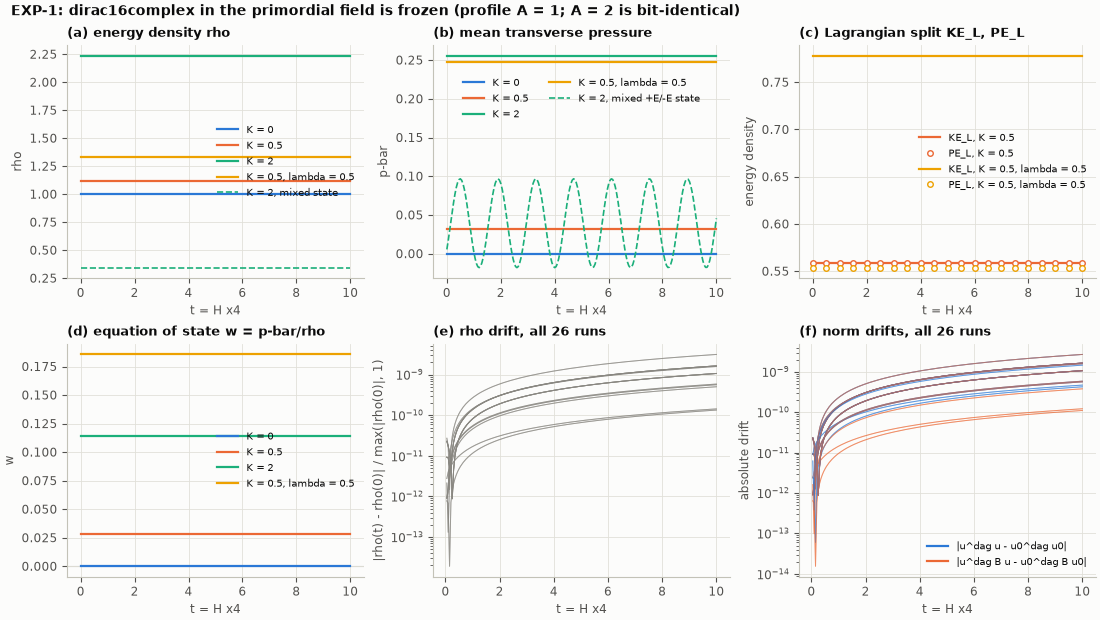

figure exp1_einstein_requirement.png sha256 42475d956a3c63fbbef0cea4da32ec5d886c4b7a00fc9f46075baea2f84b3191


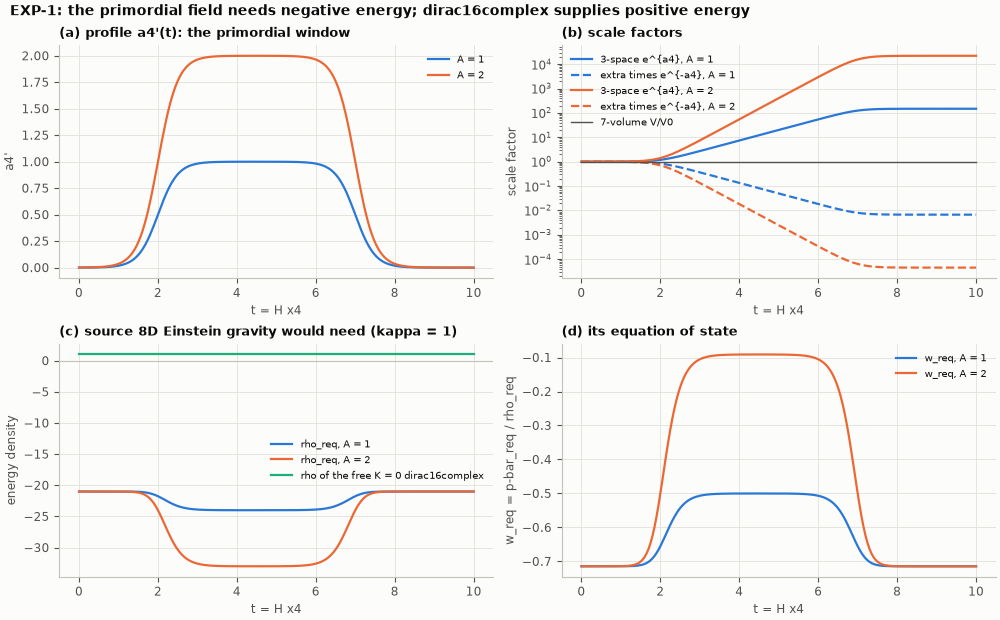

In [3]:
run("exp1")
S1 = compare_with_committed("exp1")
E1 = OUT / "exp1"
P1 = S1["parameters"]
m1, H1, kap1 = P1["m"], P1["H"], P1["kappa"]


def window(t, A):
    """a4', a4'' and a4 of the primordial window (closed forms)."""
    t1, t2, D = P1["windowT1"], P1["windowT2"], P1["windowWidth"]
    u1, u2 = np.tanh((t - t1) / D), np.tanh((t - t2) / D)
    ap = A * (1 + u1) * (1 - u2) / 4
    app = A / (4 * D) * ((1 - u1**2) * (1 - u2) - (1 + u1) * (1 - u2**2))
    a4 = (A * D / (2 * (1 - np.exp(-2 * (t2 - t1) / D)))
          * (np.logaddexp(0, 2 * (t - t1) / D) - np.logaddexp(0, 2 * (t - t2) / D)))
    return ap, app, a4


BG1, bg_dev = {}, 0.0
for rec in S1["backgrounds"]:
    b = load_csv(E1 / rec["file"])
    ap, app, a4 = window(b["t"], rec["amplitude"])
    rho_req = -3 * H1**2 * (7 + ap**2) / kap1
    p_req = {0: -3 * H1**2 * (ap**2 - 5) / kap1}
    p_req.update({j: H1**2 * (15 - 3 * ap**2 + app) / kap1 for j in (1, 2, 3)})
    p_req.update({j: H1**2 * (15 - 3 * ap**2 - app) / kap1 for j in (5, 6, 7)})
    pbar_req = sum(p_req.values()) / 7
    pairs = [(ap, "a4_prime"), (app, "a4_second"), (a4, "a4"), (np.exp(a4), "scale_3space"),
             (np.exp(-a4), "scale_extratime"), (rho_req, "rho_req"),
             (pbar_req, "p_mean_req"), (pbar_req / rho_req, "w_req")]
    pairs += [(p_req[j], f"p_req_{j}") for j in p_req]
    for mine, col in pairs:
        bg_dev = max(bg_dev, float(np.max(np.abs(mine - b[col]) / np.maximum(1, np.abs(b[col])))))
    BG1[rec["profile"]] = {"b": b, "A": rec["amplitude"], "ap": ap, "a4": a4,
                           "rho_req": rho_req, "w_req": pbar_req / rho_req}
NB["exp1_background_dev"] = bg_dev
NB["exp1_rho_req_max"] = max(float(v["rho_req"].max()) for v in BG1.values())
NB["exp1_volume_defect"] = max(float(np.abs(v["b"]["volume_ratio"] - 1).max()) for v in BG1.values())

G40 = G4 @ GAMMA[0]
R1 = {}
col_dev = exact_err = rho_drift = eig_drift = norm_drift = mix_range = 0.0
for rec in S1["runs"]:
    d = load_csv(E1 / rec["file"])
    U = spinor(d)
    K, lam, S0 = rec["hiddenMomentumK"], rec["lambda"], rec["density"]
    s = bil(U, MS).real
    S = S0 * s
    M = m1 + lam * S
    p0u = (-K * bil(U, G40)).real                  # p_0(u) = -(k_0/h_0) u^dag g4 g0 u
    eps = M * s + p0u                              # u^dag h u = M s + p_0(u)
    rho = S0 * eps - lam / 2 * S**2
    p0 = S0 * p0u + lam / 2 * S**2
    p_other = lam / 2 * S**2                       # the six directions with k_j = 0
    pbar = (p0 + 6 * p_other) / 7
    mine = {"S": S, "M_eff": M, "rho": rho, "p_0": p0, "p_1": p_other, "p_7": p_other,
            "p_mean": pbar, "KE_L": S0 * eps / 2, "PE_L": rho - S0 * eps / 2,
            "KE_H": S0 * p0u, "PE_H": m1 * S + lam / 2 * S**2,
            "norm_hilbert": np.sum(np.abs(U)**2, axis=1), "norm_krein": bil(U, BMAT).real}
    for col, val in mine.items():
        col_dev = max(col_dev, float(np.max(np.abs(val - d[col]))))
    good = np.abs(rho) > 1e-6
    col_dev = max(col_dev, float(np.max(np.abs(pbar[good] / rho[good] - d["w"][good]))))
    # exact propagator with the (constant) effective mass
    M0 = M[0]
    E = math.sqrt(M0**2 + K**2)
    h0 = -1j * M0 * G4 - K * G40
    u0 = U[0]
    tt = d["t"][:, None]
    Uex = np.cos(E * tt) * u0[None, :] - 1j * np.sin(E * tt) / E * (h0 @ u0)[None, :]
    exact_err = max(exact_err, float(np.abs(U - Uex).max()))
    rho_drift = max(rho_drift, float(np.abs(rho - rho[0]).max()))
    norm_drift = max(norm_drift, float(np.abs(mine["norm_hilbert"] - mine["norm_hilbert"][0]).max()),
                     float(np.abs(mine["norm_krein"] - mine["norm_krein"][0]).max()))
    if rec["initialSpinor"] != "mix":
        eig_drift = max(eig_drift, float(np.abs(p0 - p0[0]).max()), float(np.abs(S - S[0]).max()))
    elif K != 0:
        mix_range = max(mix_range, float(p0.max() - p0.min()))
    R1[rec["id"]] = {"rec": rec, "d": d, "U": U, "rho": rho, "p0": p0, "pbar": pbar, "S": S,
                     "KE_L": mine["KE_L"], "PE_L": mine["PE_L"], "w": np.where(good, pbar / np.where(good, rho, 1), np.nan),
                     "E": E, "K": K, "nh": mine["norm_hilbert"], "nk": mine["norm_krein"]}
NB.update(exp1_column_dev=col_dev, exp1_exact_err=exact_err, exp1_rho_drift=rho_drift,
          exp1_eig_drift=eig_drift, exp1_norm_drift=norm_drift, exp1_mix_range=mix_range)

# the two profiles must give the same spinor (a4 enters h only through 0/h_j)
NB["exp1_profile_diff"] = max(float(np.abs(v["U"] - R1["A2" + k[2:]]["U"]).max())
                              for k, v in R1.items() if k.startswith("A1"))

# free eigenmode laws and the self-consistent mass of the lambda run
law_dev = 0.0
for k, v in R1.items():
    if v["rec"]["initialSpinor"] == "pos_Bp" and v["rec"]["lambda"] == 0:
        E, K = v["E"], v["K"]
        law_dev = max(law_dev, abs(v["rho"][0] - E), abs(v["p0"][0] - K**2 / E),
                      abs(v["S"][0] - 1 / E), abs(v["KE_L"][0] - E / 2), abs(v["PE_L"][0] - E / 2),
                      abs(v["pbar"][0] / v["rho"][0] - K**2 / (7 * E**2)))
NB["exp1_eigenmode_law_dev"] = law_dev
lam_run = R1["A1_K0p5_pos_Bp_lambda0p5"]
lam, S0, K = lam_run["rec"]["lambda"], lam_run["rec"]["density"], lam_run["K"]
Mstar = m1
for _ in range(200):                     # M = m + lambda S0 s, s = M/E on the rest state
    Mstar = m1 + lam * S0 * Mstar / math.sqrt(Mstar**2 + K**2)
NB["exp1_lambda_mass"] = Mstar
NB["exp1_lambda_mass_dev"] = abs(Mstar - P1["lambdaSelfConsistentMass"])

print(f"\nbackground recomputed from the closed-form window: max deviation {bg_dev:.1e}")
print(f"Einstein source the field would need: max rho_req = {NB['exp1_rho_req_max']:.9f} (< 0), "
      f"7-volume defect {NB['exp1_volume_defect']:.1e}")
print(f"spinor observables recomputed from the raw columns: max deviation {col_dev:.1e}")
print(f"max |u - exact propagator|      = {exact_err:.2e}   (Rust: {S1['measurements']['maxExactError']:.2e}, limit {S1['limits']['exact']:.0e})")
print(f"max rho drift (all 26 runs)     = {rho_drift:.2e}   (limit {S1['limits']['frozen']:.0e})")
print(f"max p_0 / S drift (eigenstates) = {eig_drift:.2e}")
print(f"max Hilbert / Krein norm drift  = {norm_drift:.2e}   (limit {S1['limits']['norm']:.0e})")
print(f"mixed-state p_0 range (K != 0)  = {mix_range:.6f}  (interference of +E and -E at frequency 2E)")
print(f"profile A1 vs A2 spinor difference = {NB['exp1_profile_diff']:.1e} (bit-identical)")
print(f"lambda run: self-consistent M_eff = {Mstar:.15f}  (Rust {P1['lambdaSelfConsistentMass']:.15f})")
print("\nfree positive-energy eigenmodes (K = hidden-space momentum):")
print("   K       E        rho       p_0      w = K^2/(7E^2)   KE_L = PE_L")
for k in ("A1_K0_pos_Bp", "A1_K0p5_pos_Bp", "A1_K2_pos_Bp"):
    v = R1[k]
    print(f"  {v['K']:4.1f}  {v['E']:.5f}  {v['rho'][0]:.5f}  {v['p0'][0]:.5f}   {v['pbar'][0] / v['rho'][0]:.5f}        {v['KE_L'][0]:.5f}")

# ---- figure 1: frozen observables ------------------------------------------
fig, ax = plt.subplots(2, 3, figsize=(11, 6.2), constrained_layout=True)
t = R1["A1_K0_pos_Bp"]["d"]["t"]
series = [("A1_K0_pos_Bp", "K = 0", 0), ("A1_K0p5_pos_Bp", "K = 0.5", 1), ("A1_K2_pos_Bp", "K = 2", 2),
          ("A1_K0p5_pos_Bp_lambda0p5", "K = 0.5, lambda = 0.5", 3)]
for key, label, c in series:
    v = R1[key]
    ax[0, 0].plot(t, v["rho"], color=PALETTE[c], label=label)
    ax[0, 1].plot(t, v["pbar"], color=PALETTE[c], label=label)
    ax[1, 0].plot(t, v["w"], color=PALETTE[c], label=label)
v = R1["A1_K2_mix"]
ax[0, 1].plot(t, v["pbar"], color=PALETTE[2], ls="--", lw=1.2, label="K = 2, mixed +E/-E state")
ax[0, 0].plot(t, v["rho"], color=PALETTE[2], ls="--", lw=1.2, label="K = 2, mixed state")
for key, label, c in [("A1_K0p5_pos_Bp", "K = 0.5", 1), ("A1_K0p5_pos_Bp_lambda0p5", "K = 0.5, lambda = 0.5", 3)]:
    v = R1[key]
    ax[0, 2].plot(t, v["KE_L"], color=PALETTE[c], label="KE_L, " + label)
    ax[0, 2].plot(t[::10], v["PE_L"][::10], color=PALETTE[c], ls="none", marker="o",
                  mfc=SURFACE, label="PE_L, " + label)
for key, v in R1.items():
    ax[1, 1].semilogy(t[1:], np.abs(v["rho"][1:] - v["rho"][0]) / max(abs(v["rho"][0]), 1.0) + 1e-17,
                      color=MUTED, lw=0.7, alpha=0.6)
    ax[1, 2].semilogy(t[1:], np.abs(v["nh"][1:] - v["nh"][0]) + 1e-17, color=PALETTE[0], lw=0.7, alpha=0.5)
    ax[1, 2].semilogy(t[1:], np.abs(v["nk"][1:] - v["nk"][0]) + 1e-17, color=PALETTE[1], lw=0.7, alpha=0.5)
ax[1, 2].plot([], [], color=PALETTE[0], label="|u^dag u - u0^dag u0|")
ax[1, 2].plot([], [], color=PALETTE[1], label="|u^dag B u - u0^dag B u0|")
for axis, title, ylabel in [(ax[0, 0], "(a) energy density rho", "rho"),
                            (ax[0, 1], "(b) mean transverse pressure", "p-bar"),
                            (ax[0, 2], "(c) Lagrangian split KE_L, PE_L", "energy density"),
                            (ax[1, 0], "(d) equation of state w = p-bar/rho", "w"),
                            (ax[1, 1], "(e) rho drift, all 26 runs", "|rho(t) - rho(0)| / max(|rho(0)|, 1)"),
                            (ax[1, 2], "(f) norm drifts, all 26 runs", "absolute drift")]:
    axis.set_title(title, loc="left")
    axis.set_xlabel("t = H x4")
    axis.set_ylabel(ylabel)
ax[0, 0].legend(loc="center right")
ax[0, 1].legend(loc="upper center", bbox_to_anchor=(0.5, 0.9), ncol=2)
ax[0, 2].legend(loc="center right")
ax[1, 0].legend(loc="center right")
ax[1, 2].legend(loc="lower right")
ax[1, 0].axhline(0, color=AXIS, lw=0.8, zorder=0)
fig.suptitle("EXP-1: dirac16complex in the primordial field is frozen (profile A = 1; A = 2 is bit-identical)",
             x=0.01, ha="left", fontsize=10, fontweight="bold")
save_figure(fig, "exp1_frozen_observables.png")

# ---- figure 2: what Einstein's equations would need ------------------------
fig, ax = plt.subplots(2, 2, figsize=(10, 6.2), constrained_layout=True)
for i, (prof, v) in enumerate(sorted(BG1.items())):
    tb = v["b"]["t"]
    lab = f"A = {v['A']:g}"
    ax[0, 0].plot(tb, v["ap"], color=PALETTE[i], label=lab)
    ax[0, 1].semilogy(tb, np.exp(v["a4"]), color=PALETTE[i], label="3-space e^{a4}, " + lab)
    ax[0, 1].semilogy(tb, np.exp(-v["a4"]), color=PALETTE[i], ls="--", label="extra times e^{-a4}, " + lab)
    ax[1, 0].plot(tb, v["rho_req"], color=PALETTE[i], label="rho_req, " + lab)
    ax[1, 1].plot(tb, v["w_req"], color=PALETTE[i], label="w_req, " + lab)
ax[0, 1].semilogy(tb, v["b"]["volume_ratio"], color=INK2, lw=1.0, label="7-volume V/V0")
ax[1, 0].plot(t, R1["A1_K0_pos_Bp"]["rho"], color=PALETTE[2], label="rho of the free K = 0 dirac16complex")
ax[1, 0].axhline(0, color=AXIS, lw=0.8)
for axis, title, ylabel in [(ax[0, 0], "(a) profile a4'(t): the primordial window", "a4'"),
                            (ax[0, 1], "(b) scale factors", "scale factor"),
                            (ax[1, 0], "(c) source 8D Einstein gravity would need (kappa = 1)", "energy density"),
                            (ax[1, 1], "(d) its equation of state", "w_req = p-bar_req / rho_req")]:
    axis.set_title(title, loc="left")
    axis.set_xlabel("t = H x4")
    axis.set_ylabel(ylabel)
    axis.legend(loc="best")
fig.suptitle("EXP-1: the primordial field needs negative energy; dirac16complex supplies positive energy",
             x=0.01, ha="left", fontsize=10, fontweight="bold")
save_figure(fig, "exp1_einstein_requirement.png")

## 7. EXP-2: a self-gravitating condensate in 8D Einstein gravity

Here the geometry responds to the field.  All three runs start with 3-space
expanding ($H_a = 1$), the extra times deflating ($H_c = -0.2$) and the hidden
direction static; the initial condensate density is fixed by the constraint.
The physics is exactly solvable ($\rho - p = mS$ and $SV$ is constant, so $V(t)$
is a quadratic and $H_iV$ is linear in $t$), which gives a sharp test.  The cell
recomputes $\Theta$, $V$, $s(u)$, $S$, $\rho$, $p$, $w$, $w_\text{eff}$ and the
constraint residual from the state columns, compares $V$ and $H_iV$ with the
exact solution, recomputes the Kasner exponents of the backward singularity
and the late-time $H_it\to2/7$, and tests the phantom criterion
$w<-1 \Leftrightarrow KE_L<0$ on the $x_0 = -0.4$ run.  (Those rows, and
the rows with $\rho<0$, have $M_\text{eff}<0$: the single occupied mode is then
a negative-energy eigenvector of $h$, outside the domain of the
expectation-value rule; see section 12.)  Expected from the
reports: the constraint holds to 1.3e-10 (relative); for
$x_0 = -0.4$ the stiff $\lambda S^2/2$ term makes $\sum p_i^2$ = 3.81
instead of the vacuum value 1, and the energy density near the singularity
falls to -1.06e6.

== exp2 ==
PASS - initial_positive_energy_rest_eigenvector: max |h u0 - M u0|, |B u0 - u0|, |s(u0) - 1| = 0.00000000000000000e+00
PASS - initial_constraint_solved: max relative residual at t = 0: 0.00000000000000000e+00
PASS - constraint_preserved: max |sum H_iH_j - kappa rho| / (sum |H_iH_j| + kappa |rho|) = 1.25938706724218517e-10 (limit 1.00000000000000006e-09)
PASS - S_times_V_constant: max |s(u) - s(u0)| = max |S V/(S_0 V_0) - s0| = 4.03314048824654492e-10
PASS - spinor_norms_conserved: max |u^dag u - 1|, |u^dag B u - 1| = 4.03314048824654492e-10
PASS - anisotropy_times_volume_constant: max |(H_i - H_j) V - (H_i0 - H_j0)| / max|H_i0 - H_j0| = 6.22368268032857941e-10
PASS - bound_nonnegative: min (Theta^2 - 3H_a^2 - 2 kappa rho) = 1.54765603391763234e-09, max |bound - (H_b^2 + 3H_c^2 + 2 res)|/Theta^2 = 1.97001731192377113e-15
PASS - exact_solution: max relative error of V, H_i, ln h_i vs the closed form (per 1 + |t_s|/(t - t_s)) = 1.01490692350383538e-10
PASS - spinor_exact_shape:

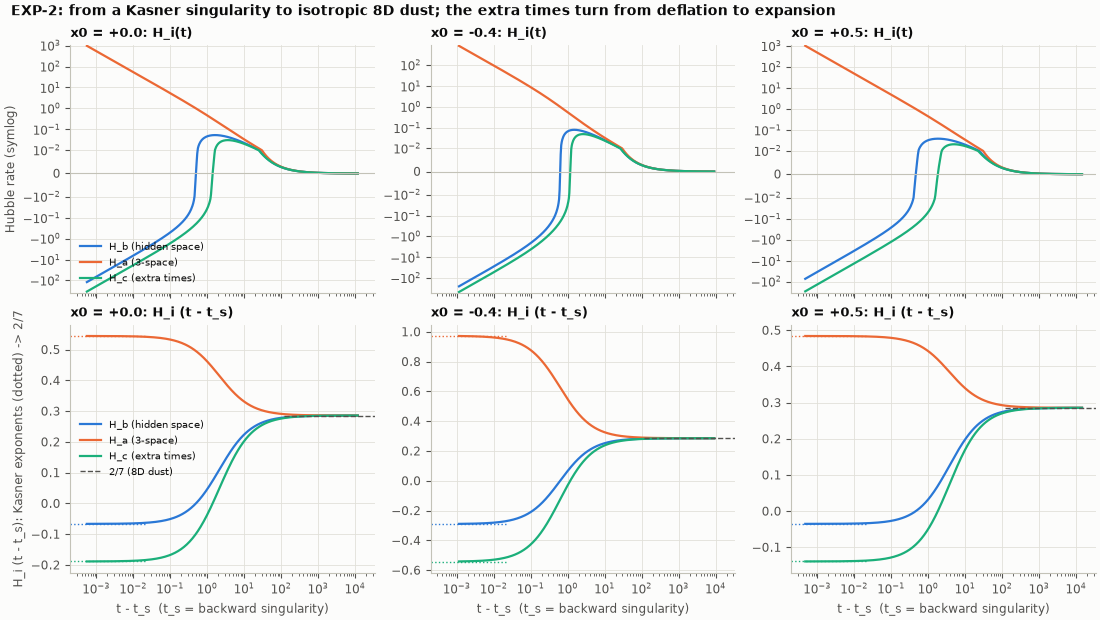

figure exp2_volume_density.png sha256 097750e8b52828ee25a700e3698db11c1ca206b39326ab3f349eb7c187302e19


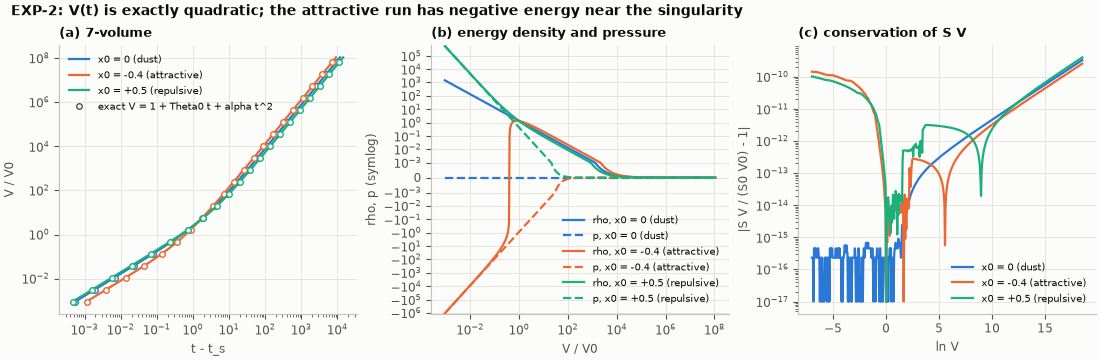

figure exp2_eos_constraint.png sha256 36207840f68c0a2b8f1bfefa240fc7a0b5c382c354b7876623eb50051b321638


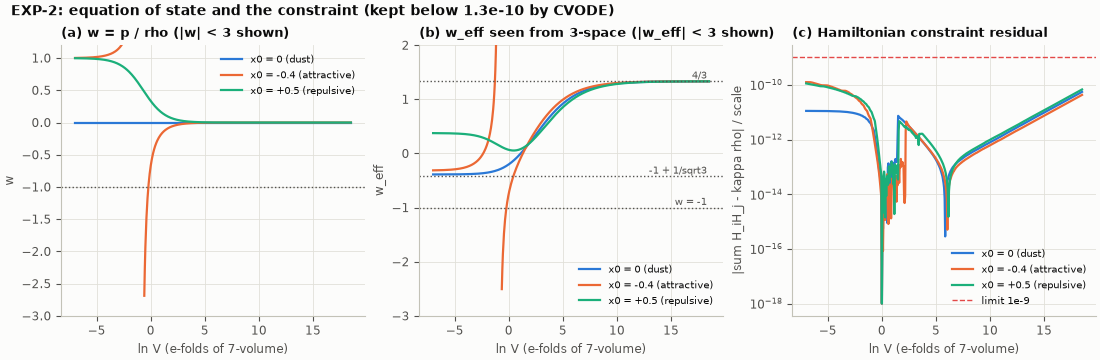

In [4]:
run("exp2")
S2 = compare_with_committed("exp2")
E2 = OUT / "exp2"
P2 = S2["parameters"]
m2, kap2 = P2["m"], P2["kappa"]
Hb0, Ha0, Hc0 = P2["hubbleB0"], P2["hubbleA0"], P2["hubbleC0"]
th0 = Hb0 + 3 * Ha0 + 3 * Hc0
R2 = {}
dev = {"columns": 0.0, "constraint": 0.0, "SV": 0.0, "volume": 0.0, "volume_rel": 0.0, "HV": 0.0,
       "kasner": 0.0, "late": 0.0, "bound_identity": 0.0}
theta_min_pos, theta_min_all, phantom_ok = np.inf, np.inf, True
for rec in S2["runs"]:
    d = load_csv(E2 / rec["file"])
    t, Hb, Ha, Hc = d["t"], d["H_b"], d["H_a"], d["H_c"]
    theta = Hb + 3 * Ha + 3 * Hc
    V = np.exp(d["ln_b"] + 3 * d["ln_a"] + 3 * d["ln_c"])
    U = spinor(d)
    s = bil(U, MS).real
    S0, lam, x0, s0 = rec["S0"], rec["lambda"], rec["x0"], rec["scalarDensity0"]
    S = S0 * s / V
    Meff = m2 + lam * S
    rho = m2 * S + lam / 2 * S**2
    p = lam / 2 * S**2
    w = p / rho
    KE_L = S * Meff / 2
    weff = -1 + theta / (3 * Ha) * (1 + w)
    C = 3 * Hb * Ha + 3 * Hb * Hc + 3 * Ha**2 + 3 * Hc**2 + 9 * Ha * Hc
    terms = (3 * np.abs(Hb * Ha) + 3 * np.abs(Hb * Hc) + 3 * Ha**2 + 3 * Hc**2 + 9 * np.abs(Ha * Hc)
             + kap2 * np.abs(rho))
    con_rel = np.abs(C - kap2 * rho) / terms           # residual relative to the size of its terms
    bound = theta**2 - 3 * Ha**2 - 2 * kap2 * rho
    for mine, col in [(theta, "Theta"), (V, "V"), (s, "s_u"), (S, "S"), (Meff, "M_eff"),
                      (rho, "rho"), (p, "p"), (KE_L, "KE_L"), (rho - KE_L, "PE_L"), (bound, "bound")]:
        dev["columns"] = max(dev["columns"], float(np.max(np.abs(mine - d[col]) / np.maximum(1, np.abs(d[col])))))
    dev["constraint"] = max(dev["constraint"], float(con_rel.max()))
    dev["SV"] = max(dev["SV"], float(np.abs(S * V / (S0 * s0) - 1).max()))
    dev["bound_identity"] = max(dev["bound_identity"],
                                float(np.max(np.abs(bound - (Hb**2 + 3 * Hc**2) - 2 * (C - kap2 * rho))
                                             / np.maximum(1, np.abs(bound)))))
    # exact solution: V = 1 + theta0 t + alpha t^2, H_i V = H_i0 + beta t
    beta = kap2 * m2 * S0 * s0 / 6
    alpha = 3.5 * beta
    Vex = 1 + th0 * t + alpha * t**2
    dev["volume"] = max(dev["volume"], float((np.abs(V - Vex) / np.maximum(1, Vex)).max()))
    dev["volume_rel"] = max(dev["volume_rel"], float(np.abs(V / Vex - 1).max()))
    for Hi, Hi0 in ((Hb, Hb0), (Ha, Ha0), (Hc, Hc0)):
        dev["HV"] = max(dev["HV"], float(np.max(np.abs(Hi * V - (Hi0 + beta * t)) / (1 + np.abs(beta * t)))))
    D = th0**2 - 4 * alpha
    ts = -2 / (th0 + math.sqrt(D))
    kas = np.array([(Hi0 + beta * ts) / math.sqrt(D) for Hi0 in (Hb0, Ha0, Hc0)])
    dev["kasner"] = max(dev["kasner"], float(np.abs(kas - np.array(rec["exact"]["kasnerExponents"])).max()))
    late = np.array([Hb[-1], Ha[-1], Hc[-1]]) * (t[-1] - ts)
    dev["late"] = max(dev["late"], float(np.abs(late - 2 / 7).max()))
    pos = rho > 0
    theta_min_pos = min(theta_min_pos, float((theta[pos] / (3 * Ha[pos])).min()))
    theta_min_all = min(theta_min_all, float((theta / (3 * Ha)).min()))
    phantom = pos & (w < -1)
    phantom_ok &= bool(np.array_equal(phantom, pos & (KE_L < 0)))
    R2[rec["id"]] = dict(rec=rec, t=t, Hb=Hb, Ha=Ha, Hc=Hc, theta=theta, V=V, rho=rho, p=p, w=w,
                         weff=weff, con_rel=con_rel, bound=bound, ts=ts, kas=kas, beta=beta,
                         alpha=alpha, SV=S * V / (S0 * s0), phantom_rows=int(phantom.sum()),
                         negE_rows=int((rho < 0).sum()), turn=-Hc0 / beta)
NB.update({f"exp2_{k}": v for k, v in dev.items()})
NB["exp2_theta_min_pos"], NB["exp2_theta_min_all"] = theta_min_pos, theta_min_all
NB["exp2_phantom_iff_negative_KE"] = phantom_ok
dust = R2["x0_0"]
NB["exp2_dust_min_weff"] = float(dust["weff"][dust["rho"] > 0].min())

print(f"\nstate-derived columns recomputed: max scaled deviation {dev['columns']:.1e}")
print(f"constraint sum_(i<j) H_i H_j = kappa rho: max residual / (sum of |terms|) = {dev['constraint']:.2e} "
      f"(Rust {S2['measurements']['maxConstraintRelative']:.2e}, limit {S2['limits']['constraint']:.0e})")
print(f"S V / (S0 V0) - 1: max {dev['SV']:.2e};  bound identity Theta^2-3H_a^2-2kappa rho = H_b^2+3H_c^2: {dev['bound_identity']:.1e}")
print(f"exact solution: max |V - V_exact| / max(1, V) = {dev['volume']:.2e} (pure relative error {dev['volume_rel']:.1e}, "
      f"largest at the backward end V = 9e-4); max H_i V error = {dev['HV']:.2e}")
print("\n run     x0     S0      lambda     t_s        Kasner (p_b, p_a, p_c)          sum p^2   H_c turns   late H_i t")
for key, v in R2.items():
    r = v["rec"]
    sq = v["kas"][0]**2 + 3 * v["kas"][1]**2 + 3 * v["kas"][2]**2
    late = v["Ha"][-1] * (v["t"][-1] - v["ts"])
    print(f" {key:8s} {r['x0']:5.1f}  {r['S0']:.3f}  {r['lambda']:+.5f}  {v['ts']:.6f}  "
          f"({v['kas'][0]:+.5f}, {v['kas'][1]:+.5f}, {v['kas'][2]:+.5f})  {sq:.5f}   t = {v['turn']:.4f}   {late:.5f}")
print(f"\nmin Theta/(3 H_a) on rows with rho > 0 = {theta_min_pos:.5f} > 1/sqrt3 = {1/math.sqrt(3):.5f}; "
      f"over all rows {theta_min_all:.5f}")
print(f"dust run: min w_eff = {NB['exp2_dust_min_weff']:.5f} > -1 + 1/sqrt3 = {-1 + 1/math.sqrt(3):.5f}")
v = R2["x0_m0p4"]
print(f"x0 = -0.4: {v['phantom_rows']} phantom rows (w < -1, rho > 0), {v['negE_rows']} rows with rho < 0; "
      f"phantom <=> KE_L < 0: {phantom_ok}")

# ---- figure: Hubble rates ---------------------------------------------------
comp = [("Hb", "H_b (hidden space)", 0), ("Ha", "H_a (3-space)", 1), ("Hc", "H_c (extra times)", 2)]
fig, ax = plt.subplots(2, 3, figsize=(11, 6.2), constrained_layout=True, sharex=True)
for j, key in enumerate(("x0_0", "x0_m0p4", "x0_0p5")):
    v = R2[key]
    tau = v["t"] - v["ts"]
    for name, label, c in comp:
        ax[0, j].plot(tau, v[name], color=PALETTE[c], label=label)
        ax[1, j].plot(tau, v[name] * tau, color=PALETTE[c], label=label)
    for c, pk in enumerate(v["kas"]):
        ax[1, j].axhline(pk, xmax=0.25, color=PALETTE[c], ls=":", lw=1.0)
    ax[1, j].axhline(2 / 7, xmin=0.7, color=INK2, ls="--", lw=1.0, label="2/7 (8D dust)")
    ax[0, j].set_xscale("log")
    ax[0, j].set_yscale("symlog", linthresh=0.01)
    ax[0, j].set_title(f"x0 = {v['rec']['x0']:+.1f}: H_i(t)", loc="left")
    ax[1, j].set_title(f"x0 = {v['rec']['x0']:+.1f}: H_i (t - t_s)", loc="left")
    ax[1, j].set_xlabel("t - t_s  (t_s = backward singularity)")
    ax[0, j].axhline(0, color=AXIS, lw=0.8)
ax[0, 0].set_ylabel("Hubble rate (symlog)")
ax[1, 0].set_ylabel("H_i (t - t_s): Kasner exponents (dotted) -> 2/7")
ax[0, 0].legend(loc="lower left")
ax[1, 0].legend(loc="center left")
fig.suptitle("EXP-2: from a Kasner singularity to isotropic 8D dust; the extra times turn from deflation to expansion",
             x=0.01, ha="left", fontsize=10, fontweight="bold")
save_figure(fig, "exp2_hubble.png")

# ---- figure: volume and density --------------------------------------------
runs2 = [("x0_0", "x0 = 0 (dust)", 0), ("x0_m0p4", "x0 = -0.4 (attractive)", 1), ("x0_0p5", "x0 = +0.5 (repulsive)", 2)]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for key, label, c in runs2:
    v = R2[key]
    tau = v["t"] - v["ts"]
    ax[0].loglog(tau, v["V"], color=PALETTE[c], label=label)
    ax[0].loglog(tau[::25], (1 + th0 * v["t"] + v["alpha"] * v["t"]**2)[::25], ls="none", marker="o",
                 mfc=SURFACE, color=PALETTE[c])
    ax[1].plot(v["V"], v["rho"], color=PALETTE[c], label="rho, " + label)
    ax[1].plot(v["V"], v["p"], color=PALETTE[c], ls="--", label="p, " + label)
    ax[2].semilogy(np.log(v["V"]), np.abs(v["SV"] - 1) + 1e-17, color=PALETTE[c], label=label)
ax[0].plot([], [], ls="none", marker="o", mfc=SURFACE, color=INK2, label="exact V = 1 + Theta0 t + alpha t^2")
ax[1].set_xscale("log")
ax[1].set_yscale("symlog", linthresh=1e-3)
for axis, title, xl, yl in [(ax[0], "(a) 7-volume", "t - t_s", "V / V0"),
                            (ax[1], "(b) energy density and pressure", "V / V0", "rho, p (symlog)"),
                            (ax[2], "(c) conservation of S V", "ln V", "|S V / (S0 V0) - 1|")]:
    axis.set_title(title, loc="left")
    axis.set_xlabel(xl)
    axis.set_ylabel(yl)
    axis.legend(loc="best")
fig.suptitle("EXP-2: V(t) is exactly quadratic; the attractive run has negative energy near the singularity",
             x=0.01, ha="left", fontsize=10, fontweight="bold")
save_figure(fig, "exp2_volume_density.png")

# ---- figure: equation of state and constraint --------------------------------
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for key, label, c in runs2:
    v = R2[key]
    nu = np.log(v["V"])
    ax[0].plot(nu, np.where(np.abs(v["w"]) < 3, v["w"], np.nan), color=PALETTE[c], label=label)
    ax[1].plot(nu, np.where(np.abs(v["weff"]) < 3, v["weff"], np.nan), color=PALETTE[c], label=label)
    ax[2].semilogy(nu, v["con_rel"] + 1e-18, color=PALETTE[c], label=label)
for yv, lab in [(-1, "w = -1"), (-1 + 1 / math.sqrt(3), "-1 + 1/sqrt3"), (4 / 3, "4/3")]:
    ax[1].axhline(yv, color=INK2, ls=":", lw=1.0)
    ax[1].text(18.3, yv + 0.05, lab, color=INK2, ha="right", fontsize=7.5)
ax[0].axhline(-1, color=INK2, ls=":", lw=1.0)
ax[0].set_ylim(-3, 1.2)
ax[1].set_ylim(-3, 2)
ax[2].axhline(S2["limits"]["constraint"], color=PALETTE[7], ls="--", lw=1.0, label="limit 1e-9")
for axis, title, yl in [(ax[0], "(a) w = p / rho (|w| < 3 shown)", "w"),
                        (ax[1], "(b) w_eff seen from 3-space (|w_eff| < 3 shown)", "w_eff"),
                        (ax[2], "(c) Hamiltonian constraint residual", "|sum H_iH_j - kappa rho| / scale")]:
    axis.set_title(title, loc="left")
    axis.set_xlabel("ln V (e-folds of 7-volume)")
    axis.set_ylabel(yl)
    axis.legend(loc="best")
fig.suptitle(f"EXP-2: equation of state and the constraint (kept below {dev['constraint']:.1e} by CVODE)",
             x=0.01, ha="left", fontsize=10, fontweight="bold")
save_figure(fig, "exp2_eos_constraint.png")

## 8. EXP-3: the condensate as dark energy, confronted with Unite

With the extra dimensions frozen the condensate dilutes as $\sigma = a^{-3}$
exactly, and the attractive self-interaction ($x_0<0$) gives it negative
pressure: $w = x_0\sigma/(1+x_0\sigma)$.  The value of $x_0$ is chosen so that
$w(a{=}1)$ equals the Unite $w_0$ = -0.861 ($x_0$ = -0.462654) or the
constant-$w$ benchmark -0.764 ($x_0$ = -0.433107).  The cell runs `exp3`
and the numpy analysis script (CPL fits, $x_0$ scan, distance-modulus fits),
then recomputes independently: $\sigma$ from the spinor's scalar density,
$\rho_\psi$, $p_\psi$, $w$, $E$, $KE_L$, $PE_L$ from the closed forms; the
comoving distance by its own Gauss-Legendre quadrature (checked against the
CVODE $D_C$); the tangent CPL parameters $w_0 = x_0/(1+x_0)$,
$w_a = 3x_0/(1+x_0)^2$; the zero of $\rho_\psi$ at $a = |x_0|^{1/3}$, the phantom
crossing at $a = (2|x_0|)^{1/3}$ and the bounce $E^2 = 0$; and the
distance-modulus difference against the Unite CPL model.

A remark on the input PDF: its thawing/freezing table writes thawing
"($w_a>0$)" and freezing "($w_a<0$)".  With its own formula
$w(a) = w_0 + w_a(1-a)$, i.e. $dw/da = -w_a$, a thawing field whose $w$ rises
from $-1$ as the universe expands has $dw/da>0$, hence **$w_a<0$**, and a
freezing field approaching $-1$ from above has **$w_a>0$**.  The table's signs
are reversed; this notebook uses the formula-consistent signs.  Unite's
$w_a$ = -0.60 therefore describes $w$ rising with time, from
-1.46 at $a\to0$ through $-1$ at $a$ = 0.768.  That is the
thawing *sign* of $w_a$, but not a thawing field: a thawing field starts
frozen at $w\approx-1$ and stays at or above $-1$, while the Unite CPL curve
(and every attractive condensate below) starts phantom and crosses $-1$.

== exp3 ==
PASS - closure_E0_equals_1: |Omega_r + Omega_m + Omega_psi - 1| = 0.00000000000000000e+00, max |E(0) - 1| = 0.00000000000000000e+00, max |Omega_psi(1) - Omega_psi| = 0.00000000000000000e+00
PASS - initial_positive_energy_B_eigenvector: max |h u0 - mu u0|, |B u0 - u0| = 0.00000000000000000e+00, max |s(u0) - 1| = 0.00000000000000000e+00
PASS - sigma_from_spinor_equals_a_minus_3: max |a^3 sigma_spinor - 1| = 2.50394482925742068e-09 (limit 1.00000000000000002e-08)
PASS - ln_sigma_state_reproduces_minus_3: max |a^3 exp(ln sigma) - 1| = 1.95399252334027551e-14 (limit 9.99999999999999980e-13)
PASS - spinor_stays_in_rest_eigenspace: max |(1 - (-i gamma^4)) u| / (2 |u|) = 0.00000000000000000e+00
PASS - hilbert_and_krein_norms_conserved: max |u^dag u - 1| = 2.50394494027972314e-09, max |u^dag B u - 1| = 2.50394494027972314e-09
PASS - rho_p_w_mu_independent: mu = 3 vs 7: rho 1.73749257785179425e-09, p 3.00483891934469913e-09, w (condition-scaled) 2.76976578674928039e-09, sigma 2.769765

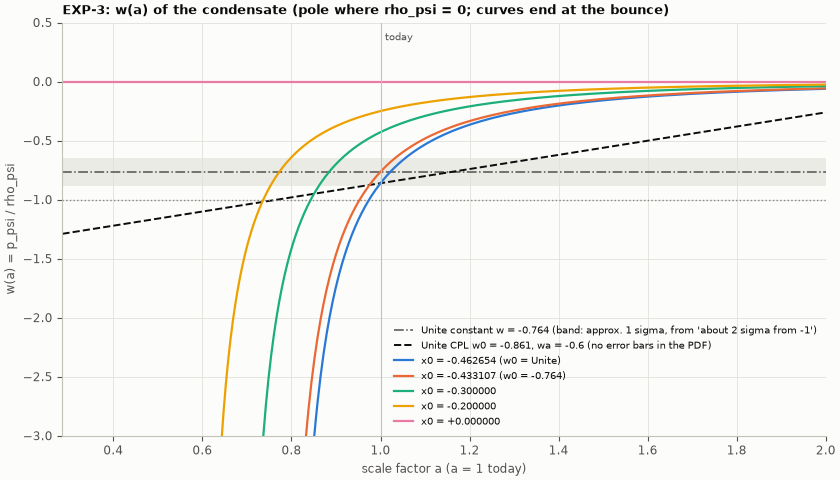

figure exp3_rho_psi.png sha256 93d296d6b58dbd0f0df9e706099b599620403b494eb9ad813faaa6bb64933ea5


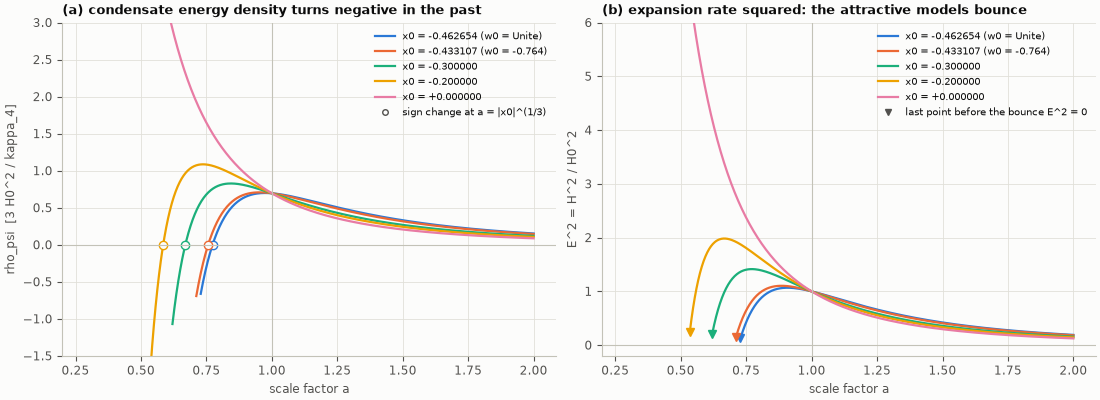

figure exp3_ke_pe.png sha256 71275e8777920ef2405ea5e1b5d45e23c5bd8d8aa6d7a3f6e2fa25e4dea0e8de


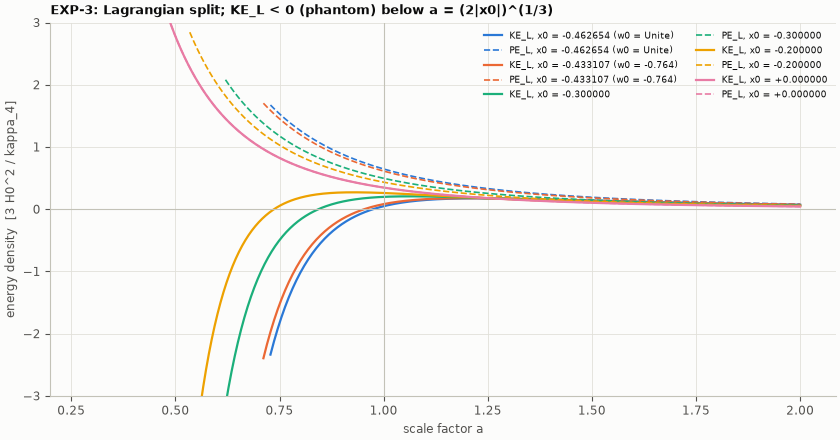

figure exp3_distance_modulus.png sha256 a92f92f57c0927a092b755d543cb4d891f059a14f31c5ecfa342637e48f26816


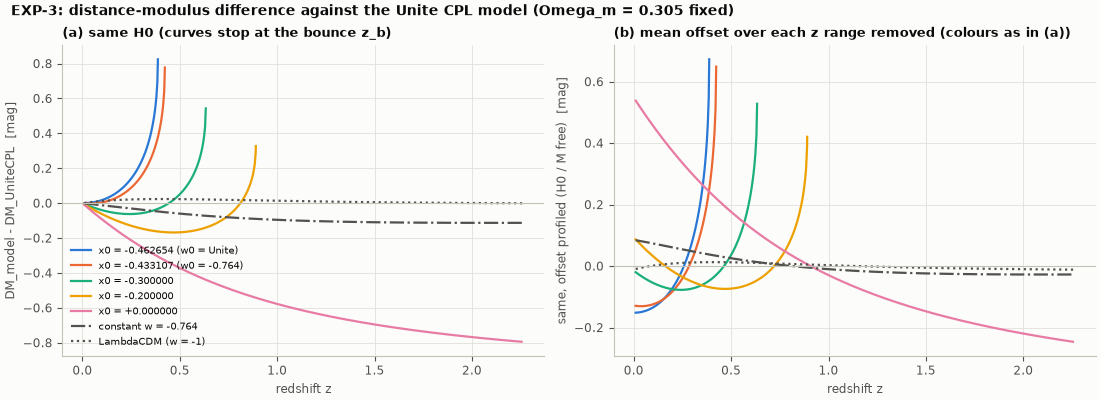

figure exp3_w0wa_plane.png sha256 16afd9a42370d3343d60a9f6cea453f9eefa280bf56e64d9cc30d52a03df96a1


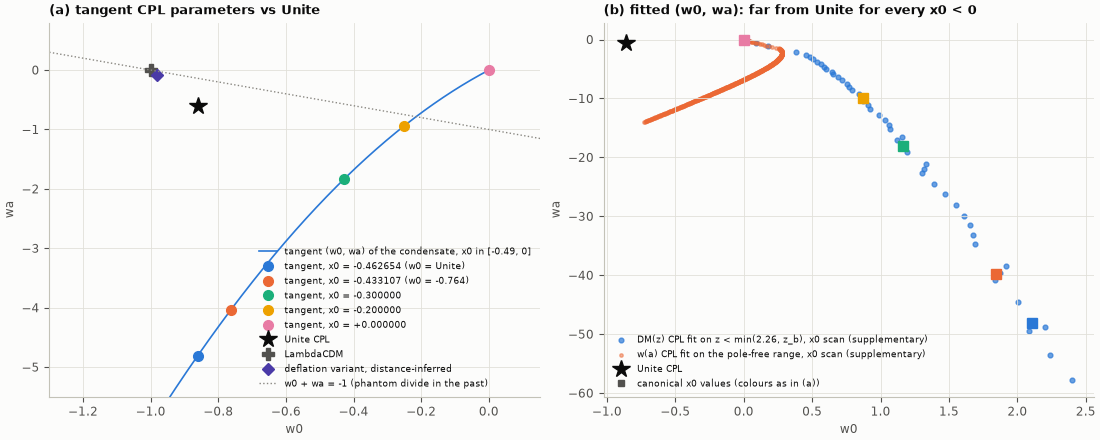

In [5]:
run("exp3")
S3 = compare_with_committed("exp3")
run_python("scripts/analyze_dirac16complex_exp3.py", "--output", OUT_REL)
compare_files_numerically("exp3-analysis", OUT / "exp3", ["fits.json", "fits_scan.csv", "fits_mu_scan.csv"])
FITS = load_json(OUT / "exp3" / "fits.json")
E3 = OUT / "exp3"
P3 = S3["parameters"]
Or, Om, Ops = P3["OmegaR"], P3["OmegaM"], P3["OmegaPsi"]
ODE = FITS["conventions"]["fixed"]["OmegaDE"]
UW0, UWA, UW = FITS["unite"]["w0"], FITS["unite"]["wa"], FITS["unite"]["wConstantBenchmark"]
GLX, GLW = np.polynomial.legendre.leggauss(8)


def E_model(z, x0):
    a = 1 / (1 + z)
    sig = a**-3
    return np.sqrt(Or * a**-4 + Om * a**-3 + Ops / (1 + x0) * sig * (1 + x0 * sig))


def E_cpl(z, w0, wa):
    a = 1 / (1 + z)
    return np.sqrt(Or * a**-4 + Om * a**-3 + ODE * a**(-3 * (1 + w0 + wa)) * np.exp(-3 * wa * (1 - a)))


def comoving_distance(Efun, z):
    """D_C(z) = int_0^z dz'/E on an increasing grid z (8-point Gauss-Legendre per panel)."""
    edges = np.concatenate([[0.0], z])
    mid, half = (edges[1:] + edges[:-1]) / 2, (edges[1:] - edges[:-1]) / 2
    pts = mid[:, None] + half[:, None] * GLX[None, :]
    return np.cumsum(half * (GLW[None, :] / Efun(pts)).sum(axis=1))


R3, dev3 = {}, {"closed": 0.0, "sigma": 0.0, "lnsigma": 0.0, "split": 0.0, "norm": 0.0, "DC": 0.0, "mu": 0.0}
for rec in S3["runs"]:
    d = load_csv(E3 / rec["file"])
    x0 = rec["x0"]
    A = Ops / (1 + x0)
    a = d["a"]
    sig = a**-3
    scale = A * sig * (1 + abs(x0) * sig)
    rho = A * sig * (1 + x0 * sig)
    p = A * x0 * sig**2
    E2 = Or * a**-4 + Om * a**-3 + rho
    dev3["closed"] = max(dev3["closed"], float(np.max(np.abs(d["rho_psi"] - rho) / scale)),
                         float(np.max(np.abs(d["p_psi"] - p) / scale)),
                         float(np.max(np.abs(d["E"]**2 - E2) / (Or * a**-4 + Om * a**-3 + scale))))
    U = spinor(d)
    s = bil(U, MS).real
    i0 = int(np.argmin(np.abs(d["N"])))
    dev3["sigma"] = max(dev3["sigma"], float(np.abs(s / s[i0] - 1).max()))
    dev3["lnsigma"] = max(dev3["lnsigma"], float(np.abs(np.exp(d["ln_sigma"]) / sig - 1).max()))
    KE = Ops / 2 * sig * (1 + 2 * x0 * sig) / (1 + x0)
    PE = Ops / 2 * sig / (1 + x0)
    dev3["split"] = max(dev3["split"], float(np.max(np.abs(d["KE_L"] - KE) / scale)),
                        float(np.max(np.abs(d["PE_L"] - PE) / scale)))
    nh, nk = np.sum(np.abs(U)**2, axis=1), bil(U, BMAT).real
    dev3["norm"] = max(dev3["norm"], float(np.abs(nh - nh[i0]).max()), float(np.abs(nk - nk[i0]).max()))
    past = d["z"] > 0
    order = np.argsort(d["z"][past])
    zp = d["z"][past][order]
    dc = comoving_distance(lambda zz: E_model(zz, x0), zp)
    dev3["DC"] = max(dev3["DC"], float(np.abs(dc - d["D_C"][past][order]).max()))
    R3[rec["id"]] = dict(rec=rec, d=d, x0=x0, a=a, rho=rho, p=p, w=np.where(np.abs(1 + x0 * sig) > 1e-3, x0 * sig / (1 + x0 * sig), np.nan),
                         E2=Or * a**-4 + Om * a**-3 + rho, KE=KE, PE=PE)
for x0 in P3["x0Values"]:
    k3, k7 = [k for k, v in R3.items() if v["x0"] == x0 and v["rec"]["mu"] in (3.0, 7.0)]
    v3, v7 = R3[k3], R3[k7]
    sc = np.abs(v3["rho"]) + np.abs(v3["p"]) + 1e-300
    dev3["mu"] = max(dev3["mu"], float(np.max(np.abs(v3["d"]["rho_psi"] - v7["d"]["rho_psi"]) / sc)),
                     float(np.max(np.abs(v3["d"]["p_psi"] - v7["d"]["p_psi"]) / sc)))
NB.update({f"exp3_{k}": v for k, v in dev3.items()})

# tangent CPL, x0 from w0, roots, deceleration, sound speed (all closed forms)
tan_dev, root_dev, TAB3 = 0.0, 0.0, []
for model in FITS["models"]:
    x0 = model["x0"]
    A = Ops / (1 + x0)
    w0, wa = x0 / (1 + x0), 3 * x0 / (1 + x0)**2
    tan_dev = max(tan_dev, abs(w0 - model["tangentCPL"]["w0"]),
                  abs(wa - model["tangentCPL"]["wa"]) / max(1, abs(wa)))
    row = {"x0": x0, "w0": w0, "wa": wa, "q0": (2 * Or + Om + Ops + 3 * A * x0) / 2,
           "cs2": 2 * x0 / (1 + 2 * x0) if x0 != 0 else 0.0}
    if x0 < 0:
        row["aZero"], row["aCross"] = abs(x0)**(1 / 3), (2 * abs(x0))**(1 / 3)
        roots = np.roots([Om + A, Or, 0.0, A * x0])
        row["aBounce"] = float(max(r.real for r in roots if abs(r.imag) < 1e-12 and 0 < r.real < 1))
        for key in ("aZero", "aCross", "aBounce"):
            ref = model[{"aZero": "aZero", "aCross": "aPhantomCrossing", "aBounce": "aBounce"}[key]]
            root_dev = max(root_dev, abs(row[key] - ref))
    root_dev = max(root_dev, abs(row["q0"] - model["q0"]), abs(row["cs2"] - model["cs2Today"]))
    TAB3.append(row)
NB["exp3_tangent_dev"], NB["exp3_root_dev"] = tan_dev, root_dev
NB["exp3_x0_from_w0_dev"] = max(abs(UW0 / (1 - UW0) - P3["x0Values"][0]), abs(UW / (1 - UW) - P3["x0Values"][1]))

# distance modulus against the Unite CPL model (z grid of the analysis: 0.01 + 0.005 k)
DM3 = {}
for model in FITS["models"]:
    x0 = model["x0"]
    zmax = min(2.26, model["zBounce"] if model["zBounce"] is not None else 9.0)
    zg = 0.01 + 0.005 * np.arange(int(round((zmax - 0.01) / 0.005, 9)) + 1)
    zg = zg[zg < zmax - 1e-12]
    if zmax < 2.26:
        zg = np.append(zg, zmax)          # the bounce itself (1/E is integrable there)
    dm = 5 * np.log10(comoving_distance(lambda zz: E_model(zz, x0), zg)
                      / comoving_distance(lambda zz: E_cpl(zz, UW0, UWA), zg))
    DM3[x0] = (zg, dm)
zg = 0.01 + 0.005 * np.arange(451)
DM_W764 = (zg, 5 * np.log10(comoving_distance(lambda zz: E_cpl(zz, UW, 0.0), zg)
                            / comoving_distance(lambda zz: E_cpl(zz, UW0, UWA), zg)))
DM_LCDM = (zg, 5 * np.log10(comoving_distance(lambda zz: E_cpl(zz, -1.0, 0.0), zg)
                            / comoving_distance(lambda zz: E_cpl(zz, UW0, UWA), zg)))
NB["exp3_dm_maxabs_w0"] = float(np.abs(DM3[P3["x0Values"][0]][1]).max())

print(f"\nclosed forms vs CSV (rho, p, E^2, each on the scale of its terms): max deviation {dev3['closed']:.2e}")
print(f"sigma from the spinor's scalar density / a^-3 - 1: max {dev3['sigma']:.2e}; exp(ln sigma)/a^-3 - 1: {dev3['lnsigma']:.1e}")
print(f"KE_L, PE_L closed forms: {dev3['split']:.1e};  spinor norms drift: {dev3['norm']:.1e};  mu = 3 vs 7: {dev3['mu']:.1e}")
print(f"comoving distance, notebook quadrature vs CVODE state D_C: max |diff| = {dev3['DC']:.2e}")
print(f"tangent CPL vs fits.json: {tan_dev:.1e};  roots/q0/cs2 vs fits.json: {root_dev:.1e}")
print(f"x0 = w0/(1 - w0): Unite w0 {UW0} -> {UW0/(1-UW0):.6f}, benchmark w {UW} -> {UW/(1-UW):.6f}")
print("\n   x0       w0(tangent)  wa(tangent)   z(rho=0)  z(w=-1)  z(bounce)   q0      cs2 today")
for r in TAB3:
    zz = lambda key: f"{1 / r[key] - 1:8.4f}" if key in r else "    none"
    print(f"  {r['x0']:+.6f}   {r['w0']:+.6f}   {r['wa']:+.6f}   {zz('aZero')}  {zz('aCross')}  {zz('aBounce')}  {r['q0']:+.4f}  {r['cs2']:+8.3f}")
print(f"\nUnite (input PDF): w0 = {UW0}, wa = {UWA}, constant w = {UW}; w0 + wa = {UW0 + UWA:.3f}")
print(f"best constant w of the Unite CPL model itself, Omega_m fixed at the assumed 0.305: "
      f"{FITS['unite']['constantWProjectionOffsetProfiled']['w']:.4f} (uniform z), "
      f"{FITS['unite']['constantWProjectionLogGridOffsetProfiled']['w']:.4f} (log z)")
print(f"requested fits: w(a) fit on [1/3.26, 1] defined only for x0 > {FITS['scan']['x0CriticalWFit']:.6f}; "
      f"DM(z) fits on [0.01, 2.26] only for x0 > {FITS['scan']['x0CriticalMuFit']:.6f}")
print(f"max |DM_model - DM_UniteCPL| (x0 = {P3['x0Values'][0]}, z < z_b) = {NB['exp3_dm_maxabs_w0']:.4f} mag "
      f"(analysis: {FITS['models'][0]['muVsUniteCPL']['maxAbsDifferenceMag']:.4f}; both maxima sit at z_b, where "
      f"the last panel ends on the integrable 1/E singularity, so the two quadratures differ slightly there)")
gv = FITS["gammaVariant"]
print(f"deflation variant: gamma_d = {gv['gamma']:.6f} gives p/rho the tangent CPL parameters of the Unite fit; "
      f"the CPL fit of its own p/rho on [1/3.26, 1] is ({gv['model']['wFitRequested']['w0']:.4f}, "
      f"{gv['model']['wFitRequested']['wa']:.4f}); distances see "
      f"({gv['tangentCPLofEffectiveW']['w0']:.4f}, {gv['tangentCPLofEffectiveW']['wa']:.4f}); "
      f"Gdot/G = {gv['objections'][1]['value']:.3f} H0; rho_psi < 0 beyond z = {gv['model']['zZero']:.2f}, "
      f"w = -1 at z = {gv['model']['zPhantomCrossing']:.3f}")
_pm = FITS["unite"]["constantWProjectionOmegaMFreeOffsetProfiled"]
print(f"best constant w of the Unite CPL distances with Omega_m free: {_pm['w']:.4f} (Omega_m = {_pm['OmegaM']:.4f}, "
      f"uniform z), {FITS['unite']['constantWProjectionOmegaMFreeLogGridOffsetProfiled']['w']:.4f} (log z)")

labels3 = {x0: (f"x0 = {x0:+.6f}" + (" (w0 = Unite)" if i == 0 else " (w0 = -0.764)" if i == 1 else ""), i)
           for i, x0 in enumerate(P3["x0Values"])}
main3 = {x0: R3[[k for k, v in R3.items() if v["x0"] == x0 and v["rec"]["mu"] == 3.0][0]] for x0 in P3["x0Values"]}

# ---- figure: w(a) -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 4.8), constrained_layout=True)
aa = np.linspace(1 / 3.5, 2, 400)
sig_w = (UW + 1) / 2      # "roughly 2 sigma from -1" (input PDF) -> approximate 1 sigma = 0.118
ax.axhspan(UW - sig_w, UW + sig_w, color=GRID, alpha=0.6, lw=0)
ax.axhline(UW, color=INK2, ls="-.", lw=1.1, label=f"Unite constant w = {UW} (band: approx. 1 sigma, from 'about 2 sigma from -1')")
ax.plot(aa, UW0 + UWA * (1 - aa), color=INK, ls="--", lw=1.4, label=f"Unite CPL w0 = {UW0}, wa = {UWA} (no error bars in the PDF)")
ax.axhline(-1, color=MUTED, ls=":", lw=1.0)
for x0, v in main3.items():
    lab, c = labels3[x0]
    w = np.where(np.abs(v["w"]) < 5, v["w"], np.nan)
    ax.plot(v["a"], w, color=PALETTE[c], label=lab)
ax.axvline(1, color=AXIS, lw=0.8)
ax.text(1.01, 0.35, "today", color=INK2, fontsize=7.5)
ax.set_ylim(-3, 0.5)
ax.set_xlim(1 / 3.5, 2)
ax.set_xlabel("scale factor a (a = 1 today)")
ax.set_ylabel("w(a) = p_psi / rho_psi")
ax.set_title("EXP-3: w(a) of the condensate (pole where rho_psi = 0; curves end at the bounce)", loc="left")
ax.legend(loc="lower right", fontsize=7)
save_figure(fig, "exp3_w_of_a.png")

# ---- figure: rho_psi(a) and E^2(a) ----------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True)
for x0, v in main3.items():
    lab, c = labels3[x0]
    ax[0].plot(v["a"], v["rho"], color=PALETTE[c], label=lab)
    ax[1].plot(v["a"], v["E2"], color=PALETTE[c], label=lab)
    if x0 < 0:
        ax[0].plot([abs(x0)**(1 / 3)], [0], marker="o", color=PALETTE[c], mfc=SURFACE, ms=6)
        ax[1].plot([v["a"][0]], [v["E2"][0]], marker="v", color=PALETTE[c], ms=6)
ax[0].plot([], [], ls="none", marker="o", mfc=SURFACE, color=INK2, label="sign change at a = |x0|^(1/3)")
ax[1].plot([], [], ls="none", marker="v", color=INK2, label="last point before the bounce E^2 = 0")
for axis in ax:
    axis.axhline(0, color=AXIS, lw=0.8)
    axis.axvline(1, color=AXIS, lw=0.8)
    axis.set_xlabel("scale factor a")
    axis.legend(loc="upper right", fontsize=7)
ax[0].set_ylim(-1.5, 3)
ax[1].set_ylim(-0.2, 6)
ax[0].set_ylabel("rho_psi  [3 H0^2 / kappa_4]")
ax[1].set_ylabel("E^2 = H^2 / H0^2")
ax[0].set_title("(a) condensate energy density turns negative in the past", loc="left")
ax[1].set_title("(b) expansion rate squared: the attractive models bounce", loc="left")
save_figure(fig, "exp3_rho_psi.png")

# ---- figure: KE_L / PE_L -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 4.4), constrained_layout=True)
for x0, v in main3.items():
    lab, c = labels3[x0]
    ax.plot(v["a"], v["KE"], color=PALETTE[c], label="KE_L, " + lab)
    ax.plot(v["a"], v["PE"], color=PALETTE[c], ls="--", lw=1.2, label="PE_L, " + lab)
ax.axhline(0, color=AXIS, lw=0.8)
ax.axvline(1, color=AXIS, lw=0.8)
ax.set_ylim(-3, 3)
ax.set_xlabel("scale factor a")
ax.set_ylabel("energy density  [3 H0^2 / kappa_4]")
ax.set_title("EXP-3: Lagrangian split; KE_L < 0 (phantom) below a = (2|x0|)^(1/3)", loc="left")
ax.legend(loc="upper right", fontsize=6.5, ncol=2)
save_figure(fig, "exp3_ke_pe.png")

# ---- figure: distance modulus difference ------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True)
for x0, (zz, dm) in DM3.items():
    lab, c = labels3[x0]
    ax[0].plot(zz, dm, color=PALETTE[c], label=lab)
    ax[1].plot(zz, dm - dm.mean(), color=PALETTE[c], label=lab)
for (zz, dm), lab, ls in [(DM_W764, f"constant w = {UW}", "-."), (DM_LCDM, "LambdaCDM (w = -1)", ":")]:
    ax[0].plot(zz, dm, color=INK2, ls=ls, label=lab)
    ax[1].plot(zz, dm - dm.mean(), color=INK2, ls=ls, label=lab)
for axis in ax:
    axis.axhline(0, color=AXIS, lw=0.8)
    axis.set_xlabel("redshift z")
ax[0].legend(loc="lower left", fontsize=7)
ax[0].set_ylabel("DM_model - DM_UniteCPL  [mag]")
ax[1].set_ylabel("same, offset profiled (H0 / M free)  [mag]")
ax[0].set_title("(a) same H0 (curves stop at the bounce z_b)", loc="left")
ax[1].set_title("(b) mean offset over each z range removed (colours as in (a))", loc="left")
fig.suptitle("EXP-3: distance-modulus difference against the Unite CPL model (Omega_m = 0.305 fixed)",
             x=0.01, ha="left", fontsize=10, fontweight="bold")
save_figure(fig, "exp3_distance_modulus.png")

# ---- figure: (w0, wa) plane ------------------------------------------------------
scan = load_csv(E3 / "fits_scan.csv")
muscan = load_csv(E3 / "fits_mu_scan.csv")
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
ax[0].plot(scan["w0_tangent"], scan["wa_tangent"], color=PALETTE[0], lw=1.2,
           label="tangent (w0, wa) of the condensate, x0 in [-0.49, 0]")
for r in TAB3:
    lab, c = labels3[r["x0"]]
    ax[0].plot([r["w0"]], [r["wa"]], marker="o", color=PALETTE[c], ms=7, ls="none", label="tangent, " + lab)
ax[0].plot([UW0], [UWA], marker="*", color=INK, ms=13, ls="none", label="Unite CPL")
ax[0].plot([-1], [0], marker="P", color=INK2, ms=8, ls="none", label="LambdaCDM")
ax[0].plot([gv["tangentCPLofEffectiveW"]["w0"]], [gv["tangentCPLofEffectiveW"]["wa"]], marker="D",
           color=PALETTE[6], ms=6, ls="none", label="deflation variant, distance-inferred")
w0line = np.linspace(-1.3, 0.2, 10)
ax[0].plot(w0line, -1 - w0line, color=MUTED, ls=":", lw=1.0, label="w0 + wa = -1 (phantom divide in the past)")
ax[0].set_xlim(-1.3, 0.15)
ax[0].set_ylim(-5.5, 0.8)
ax[0].set_title("(a) tangent CPL parameters vs Unite", loc="left")
ax[1].scatter(muscan["cpl_w0"], muscan["cpl_wa"], s=12, color=PALETTE[0], alpha=0.7,
              label="DM(z) CPL fit on z < min(2.26, z_b), x0 scan (supplementary)")
ax[1].scatter(scan["wfit_restricted_w0"], scan["wfit_restricted_wa"], s=6, color=PALETTE[1], alpha=0.5,
              label="w(a) CPL fit on the pole-free range, x0 scan (supplementary)")
for model in FITS["models"]:
    lab, c = labels3[model["x0"]]
    f = model["muFitRestricted"]["cplOffsetProfiled"]
    ax[1].plot([f["w0"]], [f["wa"]], marker="s", color=PALETTE[c], ms=7, ls="none")
ax[1].plot([UW0], [UWA], marker="*", color=INK, ms=13, ls="none", label="Unite CPL")
ax[1].plot([], [], marker="s", color=INK2, ls="none", label="canonical x0 values (colours as in (a))")
ax[1].set_title("(b) fitted (w0, wa): far from Unite for every x0 < 0", loc="left")
for axis in ax:
    axis.set_xlabel("w0")
    axis.set_ylabel("wa")
ax[0].legend(loc="lower right", fontsize=6.5)
ax[1].legend(loc="lower left", fontsize=6.5)
save_figure(fig, "exp3_w0wa_plane.png")

## 9. EXP-4: the quanta as dark matter (Fermi gas and pair creation)

Two tests of dark-matter-like behaviour in the good sector (no extra-time
momentum), 3-space expanding, hidden space and extra times static.
(a) A relativistic thermal gas ($T_i = 10m$) in the radiation era must
redshift like radiation ($\rho\propto a^{-4}$, $w\approx1/3$) and then like dust
($\rho\propto a^{-3}$, $w\to0$).  (b) A de Sitter phase followed by radiation
must create pairs for $m>0$ and none for $m = 0$ (the massless mode equation
is conformally invariant).  The cell runs `exp4` (this is the long one), then
recomputes the Gauss-Legendre grid and Fermi-Dirac weights, the mode sums
$\rho$, $p$, $KE_H$, $PE_H$ from the raw spinors, the kinetic-theory integrals
with its own 512-node quadrature, the produced number density
$na^3 = \frac{16}{2\pi^2}\int k^2|\beta_k|^2dk$ from the final spectrum in the
first-order adiabatic basis, the produced gas' equation of state and the
high-$k$ tail $|\beta_k|^2\to(mk/(4E^4))^2$.  Two assumptions to keep in mind:
the hidden-space momentum $k_0$ is set to zero (a compact hidden dimension
with a Kaluza-Klein gap far above $T$ and $H_\text{inf}$; with $k_0$ the
relativistic 3-space pressure would be $\rho/4$, not $\rho/3$); and both the
mode sum and the kinetic-theory comparison stop at $k_\text{max} = 12T_i$, so
that comparison checks the ODE integration, not the truncation (without the
cut, kinetic theory gives $w$ = 0.0361 at $a = 100$, not 0.0359).

== exp4 ==
PASS - thermal_grid_gauss_legendre: weights sum to k_max, exact for k^2, |P_48(x_n)| <= 1e-13
PASS - thermal_initial_eigenvectors: max |h u0 -+ E u0| = 7.10542735760100186e-15, u0^dag B u0 = b_sign, antiparticle eps/E = -1.00000000000000022e+00
PASS - thermal_unitarity: max |u^dag u - 1| = 2.42114697179829363e-07 (limit 9.99999999999999955e-07)
PASS - thermal_krein_conserved: max |d(u^dag B u)| = 2.42114697179829363e-07
PASS - thermal_energy_split_identities: eps = m s + p_1 per mode and KE_H + PE_H = rho: max rel residual 9.45974247981092632e-16
PASS - thermal_rho_matches_kinetic_theory: max |rho_modes/rho_kinetic - 1| = 1.97630236802584535e-08 (same GL nodes; limit 9.99999999999999955e-07)
PASS - thermal_pressure_matches_kinetic_theory_plus_free_wave: max |p_modes/p_kinetic - 1| = 1.86921892308604191e-05 (literal 1e-6 not met: first-order interference 2 Re(alpha^* beta) m K/E of the sudden-start free wave); |p - p_kin| / (free-wave envelope + 1e-6 p_kin) max = 2.8262356893

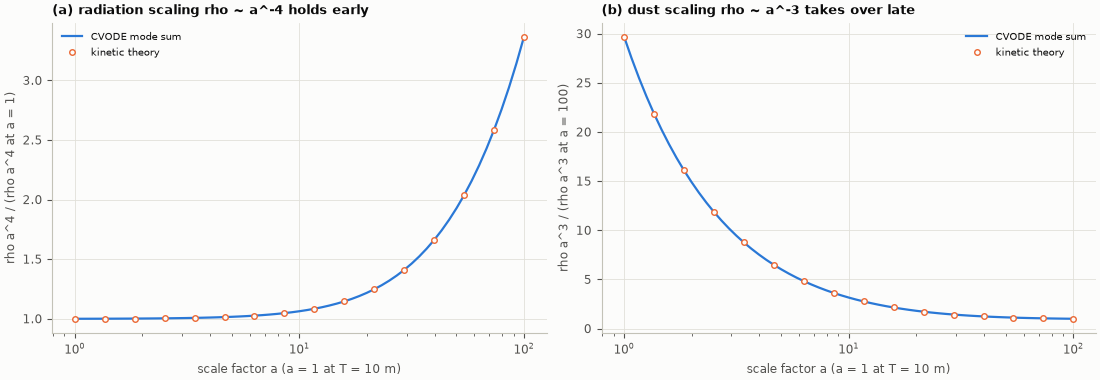

figure exp4_thermal_w.png sha256 0de3ee0fc58bbcdd438313aa77c14789b4ec43a0c41ac505396ea4e39cc5fdad


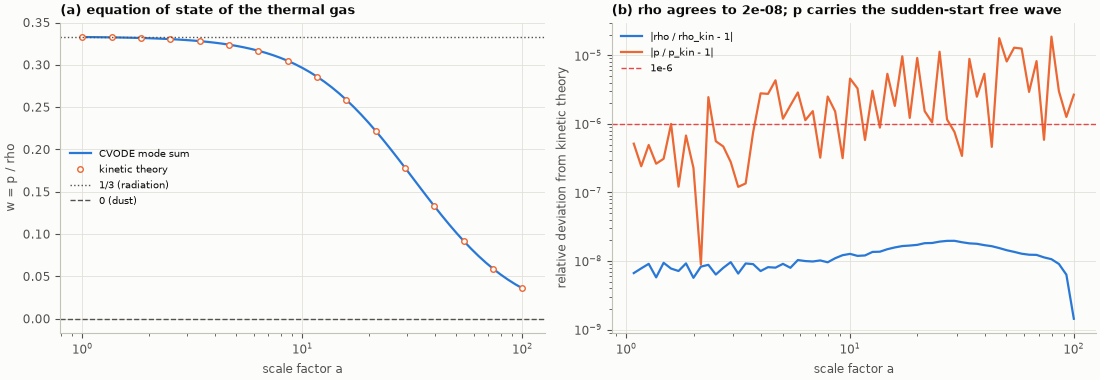

figure exp4_thermal_split.png sha256 d4b8ac3c2c18637e0f2f7a70722b7795091b08180ae61a9288af6c15845dfd1e


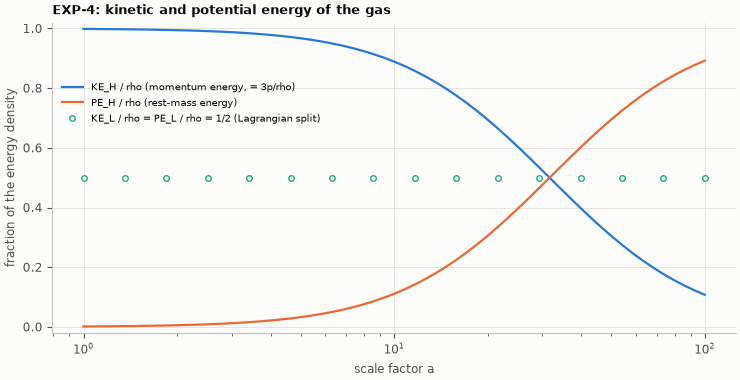

figure exp4_pair_spectra.png sha256 1e0a578d4c89ec694207754f358eaa1ba44dd7dc95621bfc253ee26f0295e563


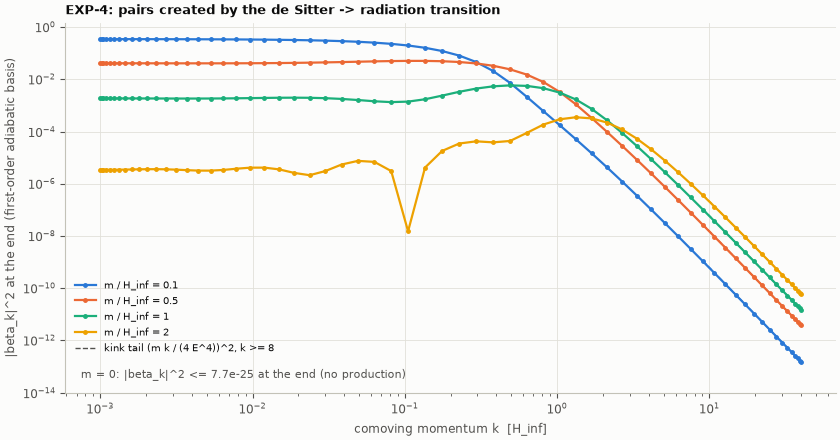

figure exp4_pair_density.png sha256 30031fb2982d0a358c0999ec86a14a5db369abf02414b9bc6200bced05a950e9


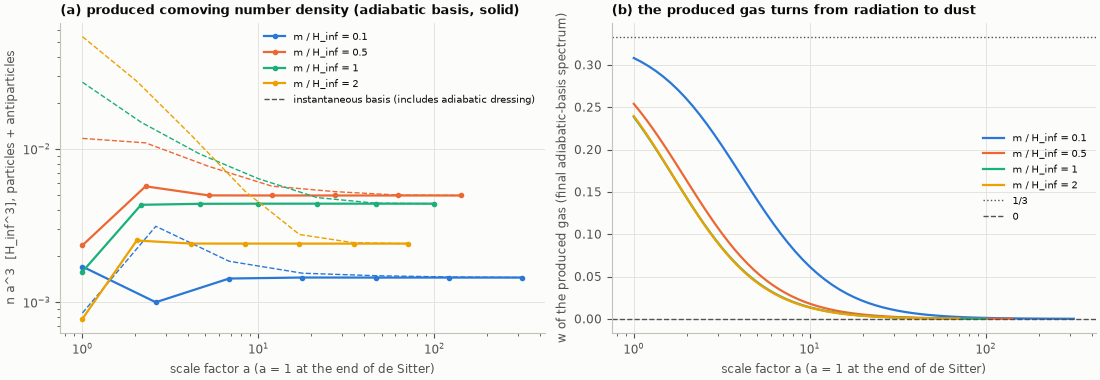

In [6]:
run("exp4")
S4 = compare_with_committed("exp4")
E4 = OUT / "exp4"
PT, PP = S4["parameters"]["thermal"], S4["parameters"]["pair"]
m4, T4, kmax = PT["m"], PT["temperature"], PT["kMax"]
C16 = 16 / (2 * math.pi**2)
G41 = G4 @ GAMMA[1]


def pair_mass(m):
    return next(r for r in S4["pair"]["masses"] if r["m"] == m)


# (a) thermal gas -------------------------------------------------------------
grid = load_csv(E4 / "thermal_grid.csv")
x, wgl = np.polynomial.legendre.leggauss(PT["nodes"])
k_n, w_n = kmax / 2 * (x + 1), kmax / 2 * wgl
f_n = 1 / (np.exp(np.sqrt(m4**2 + k_n**2) / T4) + 1)
W_n = C16 * w_n * k_n**2 * f_n
NB["exp4_grid_dev"] = float(max(np.abs(k_n - grid["k"]).max(), np.abs(W_n - grid["mode_weight"]).max()
                                / W_n.max(), np.abs(f_n - grid["f"]).max()))
modes = load_csv(E4 / "thermal_modes.csv")
order = np.lexsort((modes["a"], modes["node"]))
nn, nt = PT["nodes"], PT["outputIntervals"] + 1
U = spinor(modes)[order]
node = modes["node"][order].astype(int).reshape(nn, nt)
a_m = modes["a"][order].reshape(nn, nt)
K_m = (modes["k"][order] / modes["a"][order])
eps = (m4 * bil(U, MS) + (-K_m) * bil(U, G41)).real.reshape(nn, nt)     # u^dag h u
p1 = ((-K_m) * bil(U, G41)).real.reshape(nn, nt)
s_m = bil(U, MS).real.reshape(nn, nt)
nh = np.sum(np.abs(U)**2, axis=1).reshape(nn, nt)
Wc = W_n[node[:, 0]][:, None]
a_t = a_m[0]
rho_modes = (Wc * eps).sum(axis=0) / a_t**3
p_modes = (Wc * p1).sum(axis=0) / (3 * a_t**3)
KEH, PEH = (Wc * p1).sum(axis=0) / a_t**3, m4 * (Wc * s_m).sum(axis=0) / a_t**3
eos = load_csv(E4 / "thermal_eos.csv")
xk, wk = np.polynomial.legendre.leggauss(512)
kk, wkk = kmax / 2 * (xk + 1), kmax / 2 * wk
fk = 1 / (np.exp(np.sqrt(m4**2 + kk**2) / T4) + 1)
Ek = np.sqrt(m4**2 + (kk[None, :] / a_t[:, None])**2)
rho_kin = C16 * (wkk * kk**2 * fk * Ek).sum(axis=1) / a_t**3
p_kin = C16 * (wkk * kk**2 * fk * (kk[None, :] / a_t[:, None])**2 / (3 * Ek)).sum(axis=1) / a_t**3
NB["exp4_modes_vs_csv"] = float(max(np.abs(rho_modes / eos["rho"] - 1).max(), np.abs(p_modes / eos["p"] - 1).max(),
                                    np.abs(KEH / eos["KE_H"] - 1).max(), np.abs(PEH / eos["PE_H"] - 1).max()))
NB["exp4_rho_vs_kinetic"] = float(np.abs(rho_modes / rho_kin - 1).max())
NB["exp4_p_vs_kinetic"] = float(np.abs(p_modes / p_kin - 1).max())
NB["exp4_kinetic_vs_csv"] = float(max(np.abs(rho_kin / eos["rho_kinetic"] - 1).max(),
                                      np.abs(p_kin / eos["p_kinetic"] - 1).max()))
NB["exp4_unitarity"] = float(np.abs(nh - 1).max())
w_modes, w_kin = p_modes / rho_modes, p_kin / rho_kin
NB["exp4_w_a1"], NB["exp4_w_end"] = float(w_modes[0]), float(w_modes[-1])
kt = np.linspace(kmax, 40 * T4, 20001)
tail = np.trapezoid(kt**2 * np.sqrt(m4**2 + kt**2) / (np.exp(np.sqrt(m4**2 + kt**2) / T4) + 1), kt)
NB["exp4_kmax_truncation"] = float(C16 * tail / (rho_kin[0] + C16 * tail))

# (b) pair creation -----------------------------------------------------------
spec = load_csv(E4 / "pair_spectrum.csv")
pgrid = load_csv(E4 / "pair_grid.csv")
peos = load_csv(E4 / "pair_eos.csv")
hist = load_csv(E4 / "pair_history.csv")
lnw = dict(zip(pgrid["node"].astype(int), pgrid["ln_k_weight"]))
PAIR = {}
n_dev = eos_dev = tail_dev = tail_cvode = 0.0
for rec in S4["pair"]["masses"]:
    m = rec["m"]
    sel = spec["m"] == m
    k = spec["k"][sel]
    # the produced gas: final |beta_k|^2 in the first-order adiabatic basis (the
    # instantaneous-basis beta2_end carries the adiabatic dressing at a_end for k >~ 12)
    b2 = spec["beta2_adiabatic_end"][sel]
    b2inst = spec["beta2_end"][sel]
    wln = np.array([lnw[int(i)] for i in spec["node"][sel]])
    nA3 = C16 * np.sum(wln * k**3 * b2)
    n_dev = max(n_dev, abs(C16 * np.sum(wln * k**3 * b2inst) - rec["nA3Instantaneous"])
                / max(rec["nA3Instantaneous"], 1e-30))
    n_dev = max(n_dev, abs(nA3 - rec["nA3"]) / max(rec["nA3"], 1e-30))
    se = peos["m"] == m
    ae = peos["a"][se]
    Ee = np.sqrt(m**2 + (k[None, :] / ae[:, None])**2)
    rho_a3 = C16 * (wln * k**3 * b2 * Ee).sum(axis=1)
    p_a3 = C16 * (wln * k**3 * b2 * (k[None, :] / ae[:, None])**2 / (3 * Ee)).sum(axis=1)
    eos_dev = max(eos_dev, float(np.abs(rho_a3 / peos["rho_a3"][se] - 1).max()),
                  float(np.abs(p_a3 / peos["p_a3"][se] - 1).max()))
    th = spec["beta2_kink_tail_theory"][sel]
    b2ad = spec["beta2_adiabatic_end"][sel]
    if m > 0:
        mine = (m * k / (4 * (m**2 + k**2)**2))**2
        use = th > 0
        tail_dev = max(tail_dev, float(np.abs(mine[use] / th[use] - 1).max()))
        hi = k >= PP["tailKMin"]
        tail_cvode = max(tail_cvode, float(np.abs(b2ad[hi] / mine[hi] - 1).max()))
    PAIR[m] = dict(k=k, b2=b2, b2ad=b2ad, th=th, nA3=nA3, a=ae, w=p_a3 / rho_a3, maxb2=float(b2inst.max()),
                   hist_a=hist["a"][hist["m"] == m], hist_n=hist["n_a3"][hist["m"] == m],
                   hist_nad=hist["n_a3_adiabatic"][hist["m"] == m])
NB.update(exp4_nA3_dev=n_dev, exp4_pair_eos_dev=eos_dev, exp4_tail_formula_dev=tail_dev, exp4_tail_cvode=tail_cvode,
          exp4_massless_max_beta2=PAIR[0.0]["maxb2"])

print(f"\nGauss-Legendre grid, Fermi-Dirac weights recomputed: max deviation {NB['exp4_grid_dev']:.1e}")
print(f"mode sums from the raw spinors vs thermal_eos.csv: max relative deviation {NB['exp4_modes_vs_csv']:.1e}")
print(f"kinetic theory (512-node quadrature) vs the CSV's kinetic columns: {NB['exp4_kinetic_vs_csv']:.1e}")
print(f"mode-sum rho vs kinetic theory: {NB['exp4_rho_vs_kinetic']:.2e}  (limit {S4['limits']['kinetic']:.0e})")
print(f"mode-sum p   vs kinetic theory: {NB['exp4_p_vs_kinetic']:.2e}  (first-order free-wave interference; see section 12)")
print(f"max |u^dag u - 1| over all thermal modes: {NB['exp4_unitarity']:.2e}")
print(f"w(a = 1) = {w_modes[0]:.10f} (kinetic {w_kin[0]:.10f});  w(a = {a_t[-1]:.0f}) = {w_modes[-1]:.7f} (kinetic {w_kin[-1]:.7f})")
print(f"energy above k_max = {kmax:g} (not in the mode sum) at a = 1: {NB['exp4_kmax_truncation']:.2e} of the total")
print("\npair creation (de Sitter -> radiation, H_inf = 1), final spectrum in the first-order adiabatic basis:")
print("   m/H_inf    n a^3 (notebook)    n a^3 (Rust)     max |beta_k|^2 (end)  w at a = 1   w at the end")
for m, v in PAIR.items():
    r = pair_mass(m)
    print(f"   {m:4.1f}      {v['nA3']:.6e}      {r['nA3']:.6e}     {v['maxb2']:.3e}       {v['w'][0]:.4f}      {v['w'][-1]:.3e}")
print("with the analytic kink tail beyond k = 40 (Rust): " + "; ".join(
    f"m = {r['m']:g}: n a^3 {r['nA3TailCorrected']:.4e}, w(1) {r['wFrozenSpectrumAtA1TailCorrected']:.4f}"
    for r in S4["pair"]["masses"] if r["m"] > 0))
print("instantaneous basis (literal definition, includes the dressing at a_end): " + "; ".join(
    f"m = {r['m']:g}: n a^3 {r['nA3Instantaneous']:.4e}, w_end {r['wEndInstantaneous']:.2e}"
    for r in S4["pair"]["masses"] if r["m"] > 0))
print(f"n a^3 recomputation: {n_dev:.1e};  produced-gas EoS recomputation: {eos_dev:.1e};  "
      f"tail formula (mk/(4E^4))^2: {tail_dev:.1e}")
print(f"high-k tail (k >= {PP['tailKMin']:g}): CVODE |beta_k|^2 (adiabatic basis) vs (mk/(4E^4))^2: max relative "
      f"deviation {tail_cvode:.4f} (Rust {S4['pair']['tailMaxRelDev']:.4f}, limit {S4['limits']['tail']})")

# ---- figure: thermal scaling ------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
ax[0].semilogx(a_t, rho_modes * a_t**4 / (rho_modes[0]), color=PALETTE[0], label="CVODE mode sum")
ax[0].semilogx(a_t[::4], (rho_kin * a_t**4 / rho_kin[0])[::4], ls="none", marker="o", mfc=SURFACE, color=PALETTE[1], label="kinetic theory")
ax[1].semilogx(a_t, rho_modes * a_t**3 / (rho_modes[-1] * a_t[-1]**3), color=PALETTE[0], label="CVODE mode sum")
ax[1].semilogx(a_t[::4], (rho_kin * a_t**3 / (rho_kin[-1] * a_t[-1]**3))[::4], ls="none", marker="o", mfc=SURFACE, color=PALETTE[1], label="kinetic theory")
ax[0].set_ylabel("rho a^4 / (rho a^4 at a = 1)")
ax[1].set_ylabel("rho a^3 / (rho a^3 at a = 100)")
ax[0].set_title("(a) radiation scaling rho ~ a^-4 holds early", loc="left")
ax[1].set_title("(b) dust scaling rho ~ a^-3 takes over late", loc="left")
for axis in ax:
    axis.set_xlabel("scale factor a (a = 1 at T = 10 m)")
    axis.legend(loc="best")
save_figure(fig, "exp4_thermal_scaling.png")

# ---- figure: thermal w and deviations -----------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
ax[0].semilogx(a_t, w_modes, color=PALETTE[0], label="CVODE mode sum")
ax[0].semilogx(a_t[::4], w_kin[::4], ls="none", marker="o", mfc=SURFACE, color=PALETTE[1], label="kinetic theory")
ax[0].axhline(1 / 3, color=INK2, ls=":", lw=1.0, label="1/3 (radiation)")
ax[0].axhline(0, color=INK2, ls="--", lw=1.0, label="0 (dust)")
ax[1].loglog(a_t[1:], np.abs(rho_modes / rho_kin - 1)[1:] + 1e-17, color=PALETTE[0], label="|rho / rho_kin - 1|")
ax[1].loglog(a_t[1:], np.abs(p_modes / p_kin - 1)[1:] + 1e-17, color=PALETTE[1], label="|p / p_kin - 1|")
ax[1].axhline(S4["limits"]["kinetic"], color=PALETTE[7], ls="--", lw=1.0, label="1e-6")
ax[0].set_ylabel("w = p / rho")
ax[1].set_ylabel("relative deviation from kinetic theory")
ax[0].set_title("(a) equation of state of the thermal gas", loc="left")
ax[1].set_title(f"(b) rho agrees to {NB['exp4_rho_vs_kinetic']:.0e}; p carries the sudden-start free wave", loc="left")
for axis in ax:
    axis.set_xlabel("scale factor a")
    axis.legend(loc="best")
save_figure(fig, "exp4_thermal_w.png")

# ---- figure: Hamiltonian split -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.4, 3.8), constrained_layout=True)
ax.semilogx(a_t, KEH / rho_modes, color=PALETTE[0], label="KE_H / rho (momentum energy, = 3p/rho)")
ax.semilogx(a_t, PEH / rho_modes, color=PALETTE[1], label="PE_H / rho (rest-mass energy)")
ax.semilogx(a_t[::4], (eos["KE_L"] / eos["rho"])[::4], ls="none", marker="o", mfc=SURFACE, color=PALETTE[2],
            label="KE_L / rho = PE_L / rho = 1/2 (Lagrangian split)")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("scale factor a")
ax.set_ylabel("fraction of the energy density")
ax.set_title("EXP-4: kinetic and potential energy of the gas", loc="left")
ax.legend(loc="center left", bbox_to_anchor=(0.0, 0.74))
save_figure(fig, "exp4_thermal_split.png")

# ---- figure: pair spectra ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 4.4), constrained_layout=True)
for i, m in enumerate((0.1, 0.5, 1.0, 2.0)):
    v = PAIR[m]
    ax.loglog(v["k"], v["b2ad"], color=PALETTE[i], marker="o", ms=2.5, label=f"m / H_inf = {m:g}")
    use = v["k"] >= PP["tailKMin"]
    ax.loglog(v["k"][use], v["th"][use], color=PALETTE[i], ls="--", lw=1.0)
ax.plot([], [], color=INK2, ls="--", lw=1.0, label=f"kink tail (m k / (4 E^4))^2, k >= {PP['tailKMin']:g}")
ax.text(0.02, 0.04, f"m = 0: |beta_k|^2 <= {PAIR[0.0]['maxb2']:.1e} at the end (no production)",
        transform=ax.transAxes, color=INK2, fontsize=8)
ax.set_ylim(1e-14, 1.5)
ax.set_xlabel("comoving momentum k  [H_inf]")
ax.set_ylabel("|beta_k|^2 at the end (first-order adiabatic basis)")
ax.set_title("EXP-4: pairs created by the de Sitter -> radiation transition", loc="left")
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.08))
save_figure(fig, "exp4_pair_spectra.png")

# ---- figure: produced density and its equation of state ---------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for i, m in enumerate((0.1, 0.5, 1.0, 2.0)):
    v = PAIR[m]
    ax[0].semilogx(v["hist_a"], v["hist_nad"], color=PALETTE[i], marker="o", ms=3, label=f"m / H_inf = {m:g}")
    ax[0].semilogx(v["hist_a"], v["hist_n"], color=PALETTE[i], ls="--", lw=1.0)
    ax[1].semilogx(v["a"], v["w"], color=PALETTE[i], label=f"m / H_inf = {m:g}")
ax[1].axhline(1 / 3, color=INK2, ls=":", lw=1.0, label="1/3")
ax[1].axhline(0, color=INK2, ls="--", lw=1.0, label="0")
ax[0].set_ylabel("n a^3  [H_inf^3], particles + antiparticles")
ax[1].set_ylabel("w of the produced gas (final adiabatic-basis spectrum)")
ax[0].plot([], [], color=INK2, ls="--", lw=1.0, label="instantaneous basis (includes adiabatic dressing)")
ax[0].set_yscale("log")
ax[0].set_title("(a) produced comoving number density (adiabatic basis, solid)", loc="left")
ax[1].set_title("(b) the produced gas turns from radiation to dust", loc="left")
for axis in ax:
    axis.set_xlabel("scale factor a (a = 1 at the end of de Sitter)")
    axis.legend(loc="best")
save_figure(fig, "exp4_pair_density.png")

## 10. EXP-5: extra-time momentum makes the field blow up

A mode with momentum $q$ along an extra time direction has
$E^2 = m^2 - q^2e^{2Ht}$ while the extra times deflate as $e^{-Ht}$: after
$t^* = \ln(m/q)/H$ the "energy" is imaginary and the mode grows like
$e^{2W(t)}$, faster than any exponential.  The Hilbert norm $u^\dagger u$ explodes
while the Krein norm $u^\dagger Bu$ stays exactly conserved.  The cell runs
`exp5`, recomputes both norms from the raw spinors with the fixture's $B$,
recomputes $E^2$, $t^*$ and the WKB exponent $W(t)$ in closed form, and compares
the numerical growth over the window $[t^*+1.5, t^*+3]$ with the leading and
first-order WKB predictions.  This is why every quantisation and cosmology
above is restricted to the sector without extra-time momentum.

== exp5 ==
PASS - energy_squared_changes_sign_at_tstar: E^2(t) > 0 before t* and < 0 after on every grid point
PASS - initial_positive_energy_C_eigenvector: max residual 5.55111512312578270e-17, all |u0^dag B u0| > 0.5
PASS - krein_norm_conserved_normalized: max |d(u^dag B u)| / max(u^dag u, 1) = 1.07513772432693882e-09 (limit 1.00000000000000002e-08)
PASS - krein_norm_conserved_before_tstar: max |d(u^dag B u)| for t <= t* = 1.27911337077790677e-09
PASS - hilbert_norm_superexponential_growth: final u^dag u min = 1.25845288148261040e+16, late/early growth-rate ratio min = 1.05571863071942929e+01
PASS - growth_matches_wkb_leading_order: max relative deviation 1.02792069598497070e-03 (limit 1.00000000000000002e-02)
PASS - growth_matches_wkb_first_order: max relative deviation 2.46855133793743697e-04 (limit 2.00000000000000004e-03)
exp5: solver_steps=2548 rhs_evaluations=4800 files=5 verdict=SUCCESS
SUCCESS
exp5: 5/5 freshly written files are byte-identical to artifacts/dirac16complex/nume

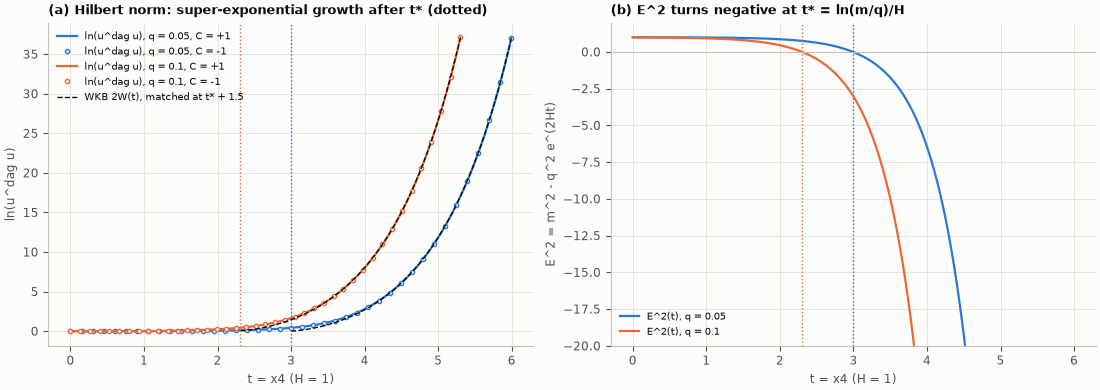

figure exp5_krein.png sha256 78570341b44825997c549a14d21a44733aab9897f7ad4c428ce54bdec53a28df


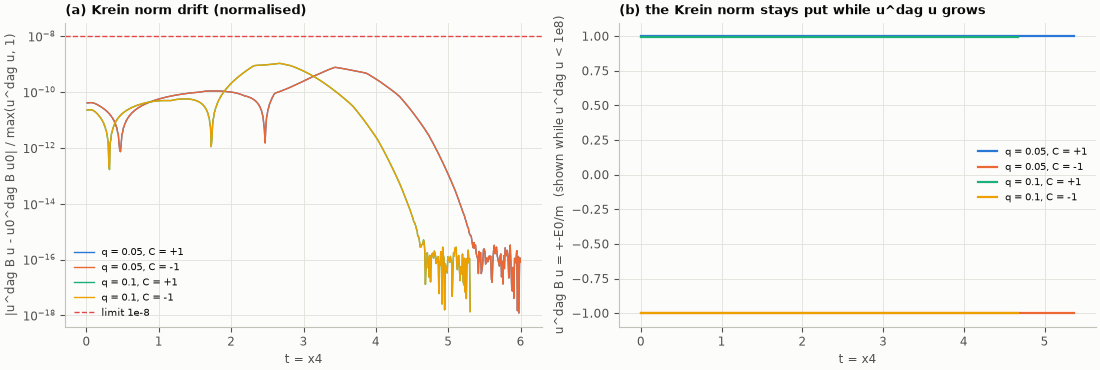

In [7]:
run("exp5")
S5 = compare_with_committed("exp5")
E5 = OUT / "exp5"
P5 = S5["parameters"]
m5, H5 = P5["m"], P5["H"]
R5, dev5 = {}, {"norm": 0.0, "E2": 0.0, "tstar": 0.0, "krein_norm": 0.0, "krein_before": 0.0,
                "wkb_lead": 0.0, "wkb_first": 0.0, "rate_ratio": np.inf}
for rec in S5["runs"]:
    d = load_csv(E5 / rec["file"])
    t = d["t"]
    q = rec["q"]
    U = spinor(d)
    nh = np.sum(np.abs(U)**2, axis=1)
    nk = bil(U, BMAT).real
    dev5["norm"] = max(dev5["norm"], float(np.abs(nh / d["norm_hilbert"] - 1).max()),
                       float((np.abs(nk - d["norm_krein"]) / np.maximum(nh, 1)).max()))
    Q = q * np.exp(H5 * t)
    E2 = m5**2 - Q**2
    dev5["E2"] = max(dev5["E2"], float(np.abs(E2 - d["E2"]).max() / (1 + np.abs(E2).max())))
    tstar = math.log(m5 / q) / H5
    dev5["tstar"] = max(dev5["tstar"], abs(tstar - rec["tStar"]))
    Qs = np.maximum(Q, m5)
    W = (np.sqrt(Qs**2 - m5**2) - m5 * np.arccos(m5 / Qs)) / H5
    kdrift = np.abs(nk - nk[0])
    dev5["krein_norm"] = max(dev5["krein_norm"], float((kdrift / np.maximum(nh, 1)).max()))
    dev5["krein_before"] = max(dev5["krein_before"], float(kdrift[t <= tstar].max()))
    ia = int(np.searchsorted(t, tstar + P5["wkbWindowStart"] - 1e-12))
    ib = len(t) - 1
    num = math.log(nh[ib]) - math.log(nh[ia])
    lead = 2 * (W[ib] - W[ia])
    first = lead - 0.5 * (math.log(1 - m5**2 / Q[ib]**2) - math.log(1 - m5**2 / Q[ia]**2))
    dev5["wkb_lead"] = max(dev5["wkb_lead"], abs(num / lead - 1))
    dev5["wkb_first"] = max(dev5["wkb_first"], abs(num / first - 1))
    ln = np.log(nh)
    early = (ln[int(np.searchsorted(t, tstar + 0.75))] - ln[int(np.searchsorted(t, tstar + 0.25))]) / 0.5
    late = (ln[ib] - ln[int(np.searchsorted(t, t[ib] - 0.5))]) / (t[ib] - t[int(np.searchsorted(t, t[ib] - 0.5))])
    dev5["rate_ratio"] = min(dev5["rate_ratio"], late / early)
    R5[rec["id"]] = dict(rec=rec, t=t, nh=nh, nk=nk, E2=E2, W=W, tstar=tstar, ia=ia, num=num, lead=lead,
                         first=first, kdrift_norm=kdrift / np.maximum(nh, 1))
NB.update({f"exp5_{k}": v for k, v in dev5.items()})

print(f"\nnorms recomputed from the raw spinors with the fixture's B: max deviation {dev5['norm']:.1e}")
print(f"E^2 = m^2 - q^2 e^(2Ht) recomputed: {dev5['E2']:.1e};  t* = ln(m/q)/H: {dev5['tstar']:.1e}")
print("\n run        t*        final u^dag u    growth over [t*+1.5, t_end]:  numerical   2 Delta W   first-order WKB")
for key, v in R5.items():
    print(f" {key:10s} {v['tstar']:.5f}   {v['nh'][-1]:.4e}                       {v['num']:.4f}    {v['lead']:.4f}     {v['first']:.4f}")
print(f"\nrelative deviation from WKB: leading {dev5['wkb_lead']:.2e} (limit {S5['limits']['wkbLeading']:.0e}), "
      f"first order {dev5['wkb_first']:.2e} (limit {S5['limits']['wkbFirstOrder']:.0e})")
print(f"growth rate late / early (min over runs): {dev5['rate_ratio']:.2f}  (super-exponential)")
print(f"Krein norm drift / max(u^dag u, 1): {dev5['krein_norm']:.2e};  absolute drift up to t*: {dev5['krein_before']:.2e}")

# ---- figure: growth -----------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.9), constrained_layout=True)
for i, (key, lab) in enumerate([("q0p05_Cp", "q = 0.05"), ("q0p1_Cp", "q = 0.1")]):
    v = R5[key]
    ax[0].plot(v["t"], np.log(v["nh"]), color=PALETTE[i], label=f"ln(u^dag u), {lab}, C = +1")
    vm = R5[key.replace("Cp", "Cm")]
    ax[0].plot(vm["t"][::15], np.log(vm["nh"])[::15], color=PALETTE[i], ls="none", marker="o", mfc=SURFACE, ms=3,
               label=f"ln(u^dag u), {lab}, C = -1")
    after = v["t"] >= v["tstar"]
    ax[0].plot(v["t"][after], 2 * v["W"][after] + (np.log(v["nh"][v["ia"]]) - 2 * v["W"][v["ia"]]),
               color=INK, ls="--", lw=1.0)
    ax[0].axvline(v["tstar"], color=PALETTE[i], ls=":", lw=1.0)
    ax[1].plot(v["t"], v["E2"], color=PALETTE[i], label=f"E^2(t), {lab}")
    ax[1].axvline(v["tstar"], color=PALETTE[i], ls=":", lw=1.0)
ax[0].plot([], [], color=INK, ls="--", lw=1.0, label="WKB 2W(t), matched at t* + 1.5")
ax[1].axhline(0, color=AXIS, lw=0.8)
ax[1].set_ylim(-20, 2)
ax[0].set_ylabel("ln(u^dag u)")
ax[1].set_ylabel("E^2 = m^2 - q^2 e^(2Ht)")
ax[0].set_title("(a) Hilbert norm: super-exponential growth after t* (dotted)", loc="left")
ax[1].set_title("(b) E^2 turns negative at t* = ln(m/q)/H", loc="left")
for axis in ax:
    axis.set_xlabel("t = x4 (H = 1)")
ax[0].legend(loc="upper left", fontsize=7)
ax[1].legend(loc="lower left", fontsize=7)
save_figure(fig, "exp5_growth.png")

# ---- figure: Krein norm ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
for i, (key, lab) in enumerate([("q0p05_Cp", "q = 0.05, C = +1"), ("q0p05_Cm", "q = 0.05, C = -1"),
                                ("q0p1_Cp", "q = 0.1, C = +1"), ("q0p1_Cm", "q = 0.1, C = -1")]):
    v = R5[key]
    ax[0].semilogy(v["t"][1:], v["kdrift_norm"][1:] + 1e-18, color=PALETTE[i], lw=1.0, label=lab)
    keep = v["nh"] < 1e8
    ax[1].plot(v["t"][keep], v["nk"][keep], color=PALETTE[i], label=lab)
ax[0].axhline(S5["limits"]["kreinNormalized"], color=PALETTE[7], ls="--", lw=1.0, label="limit 1e-8")
ax[0].set_ylabel("|u^dag B u - u0^dag B u0| / max(u^dag u, 1)")
ax[1].set_ylabel("u^dag B u = +-E0/m  (shown while u^dag u < 1e8)")
ax[0].set_title("(a) Krein norm drift (normalised)", loc="left")
ax[1].set_title("(b) the Krein norm stays put while u^dag u grows", loc="left")
for axis in ax:
    axis.set_xlabel("t = x4")
    axis.legend(loc="best", fontsize=7)
save_figure(fig, "exp5_krein.png")

## 11. The verification gauntlet

Every acceptance criterion, asserted in one place: the program runs, the
byte identity of the fresh program outputs (and the value-by-value identity of
the fresh analysis files), the fixture hash, every Rust self-check,
every check of the five independent Python checkers (which include the
repeat-run byte identity and refined-tolerance convergence tests) and of the
EXP-3 analysis, the notebook's own recomputations against the limits recorded
in each `summary.json`, the figures, and finally every number quoted in this
notebook's prose, re-read from the reports.  If any line fails, the notebook
stops here with an error; there is no "mostly passed".

In [8]:
REP = {exp: load_json(COMMITTED / exp / "python-check-report.json") for exp in ("exp1", "exp2", "exp3", "exp4", "exp5")}
ST1 = load_json(REPO / "artifacts" / "dirac16complex" / "arbitrary-field" / "stage1-summary.json")
ST2 = {name: load_json(REPO / "artifacts" / "dirac16complex" / "primordial-field" / f"{name}-primordial-report.json")
       for name in ("wolfram", "python")}
NSUM = load_json(COMMITTED / "numerics-summary.json")
SUMS = {"exp1": S1, "exp2": S2, "exp3": S3, "exp4": S4, "exp5": S5}
GAUNTLET = []


def gauntlet(name, ok, detail):
    ok = bool(ok)
    GAUNTLET.append({"name": name, "passed": ok, "detail": detail})
    print(("PASS - " if ok else "FAIL - ") + name + ": " + detail)
    assert ok, name


def matches_quote(value, text):
    q = Decimal(text)
    unit = Decimal(1).scaleb(q.as_tuple().exponent)
    return abs(Decimal(repr(float(value))) - q) <= unit / 2 + Decimal("1e-12") * abs(q)


# ---- provenance and reproducibility -------------------------------------------
gauntlet("all_runs_success", all(r["exit"] == 0 for r in RUNS) and
         all(r["last"] == "SUCCESS" for r in RUNS if r["command"].startswith("dirac16")),
         f"{len(RUNS)} program runs, every one exited 0 (simulator runs ended with SUCCESS)")
gauntlet("fresh_program_outputs_byte_identical",
         all(v["identical"] == v["files"] for v in REPRO.values() if v.get("mode") != "numeric"),
         ", ".join(f"{k} {v['identical']}/{v['files']}" for k, v in REPRO.items() if v.get("mode") != "numeric"))
gauntlet("fresh_analysis_outputs_numerically_equal",
         all(v["identical"] == v["files"] for v in REPRO.values() if v.get("mode") == "numeric"),
         ", ".join(f"{k} {v['identical']}/{v['files']}" for k, v in REPRO.items() if v.get("mode") == "numeric")
         + " (value by value: relative 1e-9, absolute 1e-12; numpy writes the last digits differently "
           "from version to version)")
gauntlet("fixture_hash_consistent",
         all(s["fixture"]["sha256"] == FIX_SHA for s in SUMS.values())
         and all(r["fixtureSha256"] == FIX_SHA for r in REP.values()) and NSUM["fixture"]["sha256"] == FIX_SHA,
         f"sha256 {FIX_SHA[:16]}... in 5 summaries, 5 checker reports and numerics-summary.json")
gauntlet("stage1_physics_verified", ST1["counts"]["total"]["failed"] == 0 and not ST1["failedChecks"]
         and not ST1["disagreements"],
         f"Stage 1 (Lagrangian, field equations, EMT, Lichnerowicz, Krein structure): "
         f"{ST1['counts']['total']['passed']}/{ST1['counts']['total']['checks']} checks, no disagreement")
gauntlet("stage2_mode_reduction_verified", ST2["wolfram"]["checks"]["P_modes_exactReduction"]
         and ST2["wolfram"]["checks"]["P_EMT_reductionSolvesDiracEquation"] and ST2["python"]["checks"]["P_modes"],
         "the EXP-1 reduction gamma^4 du/dt = (M_eff - iK gamma^0) u is verified exactly in Stage 2")
gauntlet("algebra_relations_exact", max(ALG.values()) == 0.0,
         "Clifford relations, C = g0g1g2g3, B = -iCg4, B^2 = 1, B Hermitian, BC = -ig4: all exact (0.0)")

# ---- every self-check and every checker check -----------------------------------
for exp, s in SUMS.items():
    gauntlet(f"{exp}_rust_self_checks", s["verdict"] == "SUCCESS" and all(s["checks"].values()),
             f"{sum(s['checks'].values())}/{len(s['checks'])} Rust checks true, verdict {s['verdict']}")
for exp, r in REP.items():
    gauntlet(f"{exp}_python_checker", r["verdict"] == "SUCCESS" and r["failedCheckCount"] == 0
             and all(r["checks"].values()) and r["checks"]["repeatByteIdentity"] and r["checks"]["refinedConvergence"],
             f"{sum(r['checks'].values())}/{r['checkCount']} checks of {r['checker']} true "
             f"(incl. repeat-run byte identity and refined-tolerance convergence)")
gauntlet("exp3_analysis_checks", FITS["verdict"] == "SUCCESS" and all(FITS["validation"]["checks"].values()),
         f"{len(FITS['validation']['checks'])}/{len(FITS['validation']['checks'])} checks of analyze_dirac16complex_exp3.py true")
gauntlet("numerics_summary", NSUM["verdict"] == "SUCCESS" and NSUM["totals"]["rustFailed"] == 0
         and NSUM["totals"]["pythonFailed"] == 0 and NSUM["totals"]["analysisFailed"] == 0
         and NSUM["totals"]["rustChecks"] == sum(len(s["checks"]) for s in SUMS.values())
         and NSUM["totals"]["pythonChecks"] == sum(r["checkCount"] for r in REP.values()),
         f"{NSUM['totals']['rustChecks']} Rust + {NSUM['totals']['pythonChecks']} Python + "
         f"{NSUM['totals']['analysisChecks']} analysis checks, verdict {NSUM['verdict']}")

# ---- EXP-1 --------------------------------------------------------------------------
L1 = S1["limits"]
gauntlet("exp1_background_recomputed", NB["exp1_background_dev"] < 1e-12,
         f"a4, a4', a4'', scale factors, rho_req, p_req, w_req from the closed-form window: {NB['exp1_background_dev']:.1e}")
gauntlet("exp1_einstein_source_negative", NB["exp1_rho_req_max"] < 0,
         f"max rho_req = {NB['exp1_rho_req_max']:.6f} < 0 for both profiles")
gauntlet("exp1_seven_volume_constant", NB["exp1_volume_defect"] <= L1["volume"],
         f"|V/V0 - 1| = {NB['exp1_volume_defect']:.1e} <= {L1['volume']:.0e}")
gauntlet("exp1_observables_recomputed", NB["exp1_column_dev"] < 1e-12,
         f"rho, p_j, S, M_eff, KE/PE (both splits), w, norms from the raw spinor: {NB['exp1_column_dev']:.1e}")
gauntlet("exp1_exact_propagator", NB["exp1_exact_err"] <= L1["exact"],
         f"max |u - exp(-iht) u0| = {NB['exp1_exact_err']:.2e} <= {L1['exact']:.0e}")
gauntlet("exp1_rho_frozen", NB["exp1_rho_drift"] <= L1["frozen"],
         f"max rho drift {NB['exp1_rho_drift']:.2e} <= {L1['frozen']:.0e} (all 26 runs)")
gauntlet("exp1_eigenstate_pressure_and_S_frozen", NB["exp1_eig_drift"] <= L1["frozen"],
         f"max p_0 / S drift {NB['exp1_eig_drift']:.2e} <= {L1['frozen']:.0e}")
gauntlet("exp1_norms_conserved", NB["exp1_norm_drift"] <= L1["norm"],
         f"Hilbert and Krein norm drift {NB['exp1_norm_drift']:.2e} <= {L1['norm']:.0e}")
gauntlet("exp1_profile_independence", NB["exp1_profile_diff"] <= L1["profile"],
         f"A = 1 vs A = 2 spinors differ by {NB['exp1_profile_diff']:.1e}")
gauntlet("exp1_eigenmode_laws", NB["exp1_eigenmode_law_dev"] < 1e-8,
         f"rho = E, p_0 = K^2/E, S = 1/E, KE_L = PE_L = E/2, w = K^2/(7E^2): {NB['exp1_eigenmode_law_dev']:.1e}")
gauntlet("exp1_lambda_self_consistent_mass", NB["exp1_lambda_mass_dev"] < 1e-12,
         f"fixed point M* = {NB['exp1_lambda_mass']:.15f} (difference {NB['exp1_lambda_mass_dev']:.1e})")
gauntlet("exp1_mixed_state_oscillation", abs(NB["exp1_mix_range"] - S1["measurements"]["mixedStatePressureRange"]) < 1e-9
         and REP["exp1"]["measurements"]["mixedStateRangeDeviationFromExact"] < 1e-8,
         f"p_0 range {NB['exp1_mix_range']:.6f}, checker's exact-solution deviation "
         f"{REP['exp1']['measurements']['mixedStateRangeDeviationFromExact']:.1e}")

# ---- EXP-2 --------------------------------------------------------------------------
L2 = S2["limits"]
gauntlet("exp2_columns_recomputed", NB["exp2_columns"] < 1e-9,
         f"Theta, V, s(u), S, M_eff, rho, p, KE_L, PE_L, bound from the state: {NB['exp2_columns']:.1e}")
gauntlet("exp2_constraint_preserved", NB["exp2_constraint"] <= L2["constraint"],
         f"max |sum H_iH_j - kappa rho| / (sum of |terms|) = {NB['exp2_constraint']:.2e} <= {L2['constraint']:.0e}")
gauntlet("exp2_SV_constant", NB["exp2_SV"] <= L2["conservation"],
         f"max |S V/(S0 V0) - 1| = {NB['exp2_SV']:.2e} <= {L2['conservation']:.0e}")
gauntlet("exp2_exact_volume", NB["exp2_volume"] <= L2["exact"] and NB["exp2_HV"] <= L2["exact"],
         f"|V - V_exact|/max(1, V) with V_exact = 1 + Theta0 t + alpha t^2: {NB['exp2_volume']:.1e}; "
         f"H_i V = H_i0 + beta t: {NB['exp2_HV']:.1e}")
gauntlet("exp2_bound_identity", NB["exp2_bound_identity"] < 1e-9,
         f"Theta^2 - 3H_a^2 - 2 kappa rho = H_b^2 + 3H_c^2 + 2(constraint residual): {NB['exp2_bound_identity']:.1e}")
gauntlet("exp2_kasner_exponents", NB["exp2_kasner"] < 1e-12 and S2["measurements"]["maxKasnerDeviation"] <= L2["kasner"],
         f"closed form vs summary {NB['exp2_kasner']:.1e}; extrapolated from CVODE {S2['measurements']['maxKasnerDeviation']:.1e}")
gauntlet("exp2_late_time_isotropic_dust", NB["exp2_late"] <= L2["lateTime"],
         f"max |H_i (t - t_s) - 2/7| at the end = {NB['exp2_late']:.1e} <= {L2['lateTime']:.0e}")
gauntlet("exp2_theta_bound_positive_energy", NB["exp2_theta_min_pos"] > 1 / math.sqrt(3)
         and NB["exp2_dust_min_weff"] > -1 + 1 / math.sqrt(3),
         f"min Theta/(3H_a) (rho > 0) = {NB['exp2_theta_min_pos']:.4f} > 0.5774; dust min w_eff = {NB['exp2_dust_min_weff']:.4f} > -0.4226")
gauntlet("exp2_bound_fails_only_with_negative_energy", NB["exp2_theta_min_all"] < 1 / math.sqrt(3),
         f"over all rows min Theta/(3H_a) = {NB['exp2_theta_min_all']:.4f} (x0 = -0.4, rho < 0) - reported, not hidden")
gauntlet("exp2_phantom_iff_negative_kinetic_energy", NB["exp2_phantom_iff_negative_KE"],
         f"x0 = -0.4: rows with w < -1 and rho > 0 are exactly the rows with KE_L < 0 ({R2['x0_m0p4']['phantom_rows']} rows)")

# ---- EXP-3 --------------------------------------------------------------------------
L3 = S3["limits"]
gauntlet("exp3_sigma_from_spinor", NB["exp3_sigma"] <= L3["sigmaSpinor"] and NB["exp3_lnsigma"] <= L3["sigmaState"],
         f"s(u)/s(u0) - 1 = {NB['exp3_sigma']:.1e}, exp(ln sigma)/a^-3 - 1 = {NB['exp3_lnsigma']:.1e}")
gauntlet("exp3_closed_forms", NB["exp3_closed"] <= L3["closedForm"] and NB["exp3_split"] <= L3["closedForm"],
         f"rho, p, E: {NB['exp3_closed']:.1e}; KE_L, PE_L: {NB['exp3_split']:.1e}")
gauntlet("exp3_norms_conserved", NB["exp3_norm"] <= L3["norm"], f"u^dag u and u^dag B u drift {NB['exp3_norm']:.1e}")
gauntlet("exp3_mu_independence", NB["exp3_mu"] <= L3["muIndependence"], f"mu = 3 vs 7: {NB['exp3_mu']:.1e}")
gauntlet("exp3_distance_quadrature", NB["exp3_DC"] < 1e-8,
         f"notebook Gauss-Legendre D_C vs CVODE D_C: {NB['exp3_DC']:.1e}")
gauntlet("exp3_tangent_cpl", NB["exp3_tangent_dev"] <= L3["wa"],
         f"w0 = x0/(1+x0), wa = 3x0/(1+x0)^2 vs fits.json: {NB['exp3_tangent_dev']:.1e}")
gauntlet("exp3_x0_reproduces_unite_w0", NB["exp3_x0_from_w0_dev"] < 1e-6,
         f"x0 = w0/(1 - w0) reproduces the canonical x0 values to {NB['exp3_x0_from_w0_dev']:.1e}")
gauntlet("exp3_roots_q0_cs2", NB["exp3_root_dev"] < 1e-9,
         f"rho_psi = 0, w = -1, bounce, q0, cs2 recomputed: {NB['exp3_root_dev']:.1e}")
gauntlet("exp3_requested_fits_undefined_for_x0_negative",
         all(mm["wFitRequested"]["status"] == "undefined" and mm["muFitRequested"]["status"] == "undefined"
             for mm in FITS["models"] if mm["x0"] < 0),
         "the requested CPL fits on [1/3.26, 1] and z in [0.01, 2.26] do not exist for x0 < 0 (pole, bounce) - reported")
_pf, _pm = FITS["unite"]["constantWProjectionOffsetProfiled"], FITS["unite"]["constantWProjectionOmegaMFreeOffsetProfiled"]
gauntlet("exp3_unite_constant_w_projections_recorded",
         all(math.isfinite(v) for v in (_pf["w"], _pm["w"], _pm["OmegaM"]))
         and _pm["rmsResidualMag"] <= _pf["rmsResidualMag"],
         f"recorded, not a verdict: best constant w of the noise-free Unite CPL distances = {_pf['w']:.4f} "
         f"(Omega_m fixed at the assumed 0.305), {_pm['w']:.4f} with Omega_m = {_pm['OmegaM']:.4f} free "
         f"(rms {_pf['rmsResidualMag']:.4f} -> {_pm['rmsResidualMag']:.4f} mag); benchmark {UW}")

# ---- EXP-4 --------------------------------------------------------------------------
L4 = S4["limits"]
gauntlet("exp4_grid_and_weights", NB["exp4_grid_dev"] < 1e-12, f"48-node Gauss-Legendre grid and FD weights: {NB['exp4_grid_dev']:.1e}")
gauntlet("exp4_mode_sums_recomputed", NB["exp4_modes_vs_csv"] < 1e-9,
         f"rho, p, KE_H, PE_H from the raw spinors vs thermal_eos.csv: {NB['exp4_modes_vs_csv']:.1e}")
gauntlet("exp4_rho_matches_kinetic_theory", NB["exp4_rho_vs_kinetic"] <= L4["kinetic"],
         f"max |rho/rho_kin - 1| = {NB['exp4_rho_vs_kinetic']:.2e} <= {L4['kinetic']:.0e}")
gauntlet("exp4_pressure_matches_kinetic_plus_free_wave", REP["exp4"]["measurements"]["thermalPressureEnvelopeRatio"] < 1
         and NB["exp4_p_vs_kinetic"] < 1e-4,
         f"|p/p_kin - 1| = {NB['exp4_p_vs_kinetic']:.2e}, inside the predicted interference envelope "
         f"(ratio {REP['exp4']['measurements']['thermalPressureEnvelopeRatio']:.2f})")
gauntlet("exp4_unitarity", NB["exp4_unitarity"] <= L4["unitarity"], f"max |u^dag u - 1| = {NB['exp4_unitarity']:.1e}")
gauntlet("exp4_w_radiation_to_dust", abs(NB["exp4_w_a1"] - 1 / 3) < L4["wEarly"]
         and NB["exp4_w_end"] < L4["wLateMax"],
         f"w(1) = {NB['exp4_w_a1']:.4f} within {L4['wEarly']} of 1/3, w(100) = {NB['exp4_w_end']:.4f} < {L4['wLateMax']}")
gauntlet("exp4_gas_weighted_beta_below_1e-6", S4["thermal"]["maxBeta2GasWeighted"] <= L4["beta"],
         f"{S4['thermal']['maxBeta2GasWeighted']:.1e}; adiabatic-vacuum runs {S4['thermal']['adiabaticVacuumLateBeta2']:.1e}")
gauntlet("exp4_massless_no_production", NB["exp4_massless_max_beta2"] <= L4["masslessBeta"]
         and pair_mass(0.0)["maxBeta2"] <= L4["masslessBeta"],
         f"m = 0: max |beta_k|^2 at the end {NB['exp4_massless_max_beta2']:.1e}, over the run "
         f"{pair_mass(0.0)['maxBeta2']:.1e} <= {L4['masslessBeta']:.0e}")
gauntlet("exp4_massive_production", all(pair_mass(m)["nA3"] > 1e-4 for m in (0.1, 0.5, 1.0, 2.0)),
         ", ".join(f"m={m:g}: {pair_mass(m)['nA3']:.3e}" for m in (0.1, 0.5, 1.0, 2.0)))
gauntlet("exp4_number_density_recomputed", NB["exp4_nA3_dev"] < 1e-9, f"n a^3 from the spectrum: {NB['exp4_nA3_dev']:.1e}")
gauntlet("exp4_produced_gas_eos", NB["exp4_pair_eos_dev"] < 1e-9 and
         all(PAIR[m]["w"][-1] < L4["pairWLateMax"] for m in (0.1, 0.5, 1.0, 2.0)),
         f"recomputed {NB['exp4_pair_eos_dev']:.1e}; final w < {L4['pairWLateMax']} for every m > 0")
gauntlet("exp4_kink_tail", NB["exp4_tail_formula_dev"] < 1e-12 and NB["exp4_tail_cvode"] <= L4["tail"]
         and abs(NB["exp4_tail_cvode"] - S4["pair"]["tailMaxRelDev"]) < 1e-9,
         f"formula {NB['exp4_tail_formula_dev']:.1e}; CVODE tail vs theory {NB['exp4_tail_cvode']:.3f} <= {L4['tail']}")

# ---- EXP-5 --------------------------------------------------------------------------
L5 = S5["limits"]
gauntlet("exp5_norms_recomputed", NB["exp5_norm"] < 1e-12, f"u^dag u, u^dag B u from the raw spinors: {NB['exp5_norm']:.1e}")
gauntlet("exp5_energy_turns_imaginary_at_tstar", NB["exp5_E2"] < 1e-12 and NB["exp5_tstar"] < 1e-12,
         f"E^2 and t* = ln(m/q)/H recomputed: {max(NB['exp5_E2'], NB['exp5_tstar']):.1e}")
gauntlet("exp5_krein_conserved", NB["exp5_krein_norm"] <= L5["kreinNormalized"] and NB["exp5_krein_before"] <= L5["kreinNormalized"],
         f"normalised drift {NB['exp5_krein_norm']:.1e}; absolute before t* {NB['exp5_krein_before']:.1e}")
gauntlet("exp5_wkb_leading", NB["exp5_wkb_lead"] <= L5["wkbLeading"], f"{NB['exp5_wkb_lead']:.2e} <= {L5['wkbLeading']}")
gauntlet("exp5_wkb_first_order", NB["exp5_wkb_first"] <= L5["wkbFirstOrder"], f"{NB['exp5_wkb_first']:.2e} <= {L5['wkbFirstOrder']}")
gauntlet("exp5_super_exponential", NB["exp5_rate_ratio"] > 5, f"late/early growth-rate ratio {NB['exp5_rate_ratio']:.2f}")

# ---- figures and quoted numbers ------------------------------------------------------
REQUIRED_FIGURES = ["exp1_frozen_observables.png", "exp1_einstein_requirement.png", "exp2_hubble.png",
                    "exp2_volume_density.png", "exp2_eos_constraint.png", "exp3_w_of_a.png", "exp3_rho_psi.png",
                    "exp3_ke_pe.png", "exp3_distance_modulus.png", "exp3_w0wa_plane.png", "exp4_thermal_scaling.png",
                    "exp4_thermal_w.png", "exp4_thermal_split.png", "exp4_pair_spectra.png", "exp4_pair_density.png",
                    "exp5_growth.png", "exp5_krein.png"]
names = [Path(f["file"]).name for f in FIGURES]
gauntlet("figures_written", sorted(names) == sorted(REQUIRED_FIGURES) and
         all(hashlib.sha256((REPO / f["file"]).read_bytes()).hexdigest() == f["sha256"] for f in FIGURES),
         f"{len(FIGURES)} PNG figures in artifacts/dirac16complex/numerics/figures, hashes re-read")

QUOTED = [
    ('e1_rhoReqMax', '-21.0', lambda: S1["measurements"]["maxRhoReq"]),
    ('e1_rhoReqMinA2', '-33.0', lambda: S1["backgrounds"][1]["rhoReqMin"]),
    ('e1_wK2', '0.114', lambda: record(S1, "A1_K2_pos_Bp")["initial"]["w"]),
    ('e1_mixRange', '0.803', lambda: S1["measurements"]["mixedStatePressureRange"]),
    ('e1_maxExact', '6.2e-9', lambda: S1["measurements"]["maxExactError"]),
    ('e1_lambdaMass', '1.4735', lambda: S1["parameters"]["lambdaSelfConsistentMass"]),
    ('e2_dustMinWeff', '-0.387', lambda: S2["measurements"]["dustMinWeff"]),
    ('e2_thetaMinAll', '0.344', lambda: REP["exp2"]["measurements"]["thetaOver3HaMinAllRows"]),
    ('e2_finalWeffDust', '1.333', lambda: record(S2, "x0_0")["measurements"]["finalWeff"]),
    ('e2_kasnerSumSqM04', '3.81', lambda: record(S2, "x0_m0p4")["exact"]["kasnerSumSquares"]),
    ('e2_minRhoM04', '-1.06e6', lambda: record(S2, "x0_m0p4")["measurements"]["minRho"]),
    ('e2_maxConstraint', '1.3e-10', lambda: S2["measurements"]["maxConstraintRelative"]),
    ('e3_x0W0', '-0.462654', lambda: S3["parameters"]["x0Values"][0]),
    ('e3_x0W764', '-0.433107', lambda: S3["parameters"]["x0Values"][1]),
    ('e3_waTan0', '-4.81', lambda: FITS["models"][0]["tangentCPL"]["wa"]),
    ('e3_waTan1', '-4.04', lambda: FITS["models"][1]["tangentCPL"]["wa"]),
    ('e3_zCross0', '0.026', lambda: FITS["models"][0]["zPhantomCrossing"]),
    ('e3_zZero0', '0.293', lambda: FITS["models"][0]["zZero"]),
    ('e3_zBounce0', '0.388', lambda: FITS["models"][0]["zBounce"]),
    ('e3_zBounce1', '0.423', lambda: FITS["models"][1]["zBounce"]),
    ('e3_q0_0', '-0.397', lambda: FITS["models"][0]["q0"]),
    ('e3_cs2_0', '-12.4', lambda: FITS["models"][0]["cs2Today"]),
    ('e3_projUniform', '-1.028', lambda: FITS["unite"]["constantWProjectionOffsetProfiled"]["w"]),
    ('e3_projLog', '-0.979', lambda: FITS["unite"]["constantWProjectionLogGridOffsetProfiled"]["w"]),
    ('e3_projFree', '-0.91', lambda: FITS["unite"]["constantWProjectionOmegaMFreeOffsetProfiled"]["w"]),
    ('e3_projFreeOm', '0.278', lambda: FITS["unite"]["constantWProjectionOmegaMFreeOffsetProfiled"]["OmegaM"]),
    ('e3_projFreeLog', '-0.872', lambda: FITS["unite"]["constantWProjectionOmegaMFreeLogGridOffsetProfiled"]["w"]),
    ('e3_gvFitW0', '-0.640', lambda: FITS["gammaVariant"]["model"]["wFitRequested"]["w0"]),
    ('e3_gvFitWa', '-1.98', lambda: FITS["gammaVariant"]["model"]["wFitRequested"]["wa"]),
    ('e3_gvZZero', '6.83', lambda: FITS["gammaVariant"]["model"]["zZero"]),
    ('e3_gvZCross', '0.230', lambda: FITS["gammaVariant"]["model"]["zPhantomCrossing"]),
    ('e3_gamma', '0.875', lambda: FITS["gammaVariant"]["gamma"]),
    ('e3_effW0', '-0.983', lambda: FITS["gammaVariant"]["tangentCPLofEffectiveW"]["w0"]),
    ('e3_effWa', '-0.075', lambda: FITS["gammaVariant"]["tangentCPLofEffectiveW"]["wa"]),
    ('e3_gdot', '2.63', lambda: FITS["gammaVariant"]["objections"][1]["value"]),
    ('e3_gdotYr', '1.8e-10', lambda: FITS["gammaVariant"]["objections"][1]["gdotPerYear"]),
    ('e3_rho8', '-2.58', lambda: FITS["gammaVariant"]["objections"][2]["value"]),
    ('e3_continuity', '0.254', lambda: FITS["gammaVariant"]["objections"][0]["value"]),
    ('e3_x0CritW', '-0.0289', lambda: FITS["scan"]["x0CriticalWFit"]),
    ('e3_x0CritMu', '-0.0410', lambda: FITS["scan"]["x0CriticalMuFit"]),
    ('e3_muFitW0', '2.1', lambda: FITS["models"][0]["muFitRestricted"]["cplOffsetProfiled"]["w0"]),
    ('e3_muFitWa', '-48', lambda: FITS["models"][0]["muFitRestricted"]["cplOffsetProfiled"]["wa"]),
    ('unite_w0', '-0.861', lambda: FITS["unite"]["w0"]),
    ('unite_wa', '-0.60', lambda: FITS["unite"]["wa"]),
    ('unite_w', '-0.764', lambda: FITS["unite"]["wConstantBenchmark"]),
    ('unite_past', '-1.46', lambda: FITS["unite"]["w0PlusWa"]),
    ('unite_cross', '0.768', lambda: FITS["unite"]["phantomCrossingA"]),
    ('e4_wA1', '0.3329', lambda: S4["thermal"]["wAtA1"]),
    ('e4_wAEnd', '0.0359', lambda: S4["thermal"]["wAtAEnd"]),
    ('e4_wAEndFull', '0.0361', lambda: REP["exp4"]["measurements"]["thermalKineticUntruncatedWAtAEnd"]),
    ('e4_rhoDev', '2.0e-8', lambda: S4["thermal"]["maxRelDevRho"]),
    ('e4_gasBeta', '3.7e-8', lambda: S4["thermal"]["maxBeta2GasWeighted"]),
    ('e4_perModeBeta', '6.4e-5', lambda: S4["thermal"]["maxBeta2PerMode"]),
    ('e4_n0', '1.8e-24', lambda: pair_mass(0.0)["nA3"]),
    ('e4_n01', '1.45e-3', lambda: pair_mass(0.1)["nA3"]),
    ('e4_n05', '4.99e-3', lambda: pair_mass(0.5)["nA3"]),
    ('e4_n1', '4.41e-3', lambda: pair_mass(1.0)["nA3"]),
    ('e4_n2', '2.42e-3', lambda: pair_mass(2.0)["nA3"]),
    ('e4_wEnd01', '1.2e-4', lambda: pair_mass(0.1)["wEnd"]),
    ('e4_wPairA1min', '0.24', lambda: pair_mass(1.0)["wFrozenSpectrumAtA1"]),
    ('e4_wPairA1max', '0.31', lambda: pair_mass(0.1)["wFrozenSpectrumAtA1"]),
    ('e4_steps', '2.9e8', lambda: S4["solverTotals"]["steps"]),
    ('st1_checks', '153', lambda: ST1["counts"]["total"]["passed"]),
    ('e4_massless', '8.5e-25', lambda: pair_mass(0.0)["maxBeta2"]),
    ('e5_final005', '1.26e16', lambda: record(S5, "q0p05_Cp")["finalNormHilbert"]),
    ('e5_final01', '1.31e16', lambda: record(S5, "q0p1_Cp")["finalNormHilbert"]),
    ('e5_gammaNum', '30.99', lambda: record(S5, "q0p05_Cp")["wkb"]["gammaNumeric"]),
    ('e5_gammaLead', '31.02', lambda: record(S5, "q0p05_Cp")["wkb"]["gammaLeading"]),
    ('e5_gammaFirst', '31.00', lambda: record(S5, "q0p05_Cp")["wkb"]["gammaFirstOrder"]),
    ('tot_rust', '69', lambda: NSUM["totals"]["rustChecks"]),
    ('tot_python', '162', lambda: NSUM["totals"]["pythonChecks"]),
    ('tot_analysis', '10', lambda: NSUM["totals"]["analysisChecks"]),
]
bad = [(key, text, fn()) for key, text, fn in QUOTED if not matches_quote(fn(), text)]
gauntlet("prose_numbers_match_reports", not bad,
         f"{len(QUOTED)} numbers quoted in the markdown re-read from the reports" + (f"; mismatches {bad}" if bad else ""))
print("ALL CHECKS PASSED")

PASS - all_runs_success: 7 program runs, every one exited 0 (simulator runs ended with SUCCESS)
PASS - fresh_program_outputs_byte_identical: exp1 29/29, exp2 4/4, exp3 11/11, exp4 13/13, exp5 5/5
PASS - fresh_analysis_outputs_numerically_equal: exp3-analysis 3/3 (value by value: relative 1e-9, absolute 1e-12; numpy writes the last digits differently from version to version)
PASS - fixture_hash_consistent: sha256 8b4f15462ca4d61e... in 5 summaries, 5 checker reports and numerics-summary.json
PASS - stage1_physics_verified: Stage 1 (Lagrangian, field equations, EMT, Lichnerowicz, Krein structure): 153/153 checks, no disagreement
PASS - stage2_mode_reduction_verified: the EXP-1 reduction gamma^4 du/dt = (M_eff - iK gamma^0) u is verified exactly in Stage 2
PASS - algebra_relations_exact: Clifford relations, C = g0g1g2g3, B = -iCg4, B^2 = 1, B Hermitian, BC = -ig4: all exact (0.0)
PASS - exp1_rust_self_checks: 10/10 Rust checks true, verdict SUCCESS
PASS - exp2_rust_self_checks: 15/15 Rust

## 12. Conclusions: dark matter and dark energy

### 12.1 Dark matter

**Established (numerically, within the model):**

- In the good sector the free quanta form an ordinary Fermi gas with 16
  states per momentum (8 particles + 8 antiparticles), with the hidden-space
  momentum $k_0$ set to zero.  A thermal gas started at $T = 10m$ has $w$ =
  0.3329 at $a = 1$ and 0.0359 at $a = 100$ on the truncated grid
  $k\le12T_i$ (without the cut, kinetic theory gives 0.0361); its
  energy density agrees with kinetic theory on the same grid to 2.0e-8
  (a check of the ODE integration), and it scales as $a^{-4}$ early and
  $a^{-3}$ late: dark-matter-like (cold) behaviour at late times.  This gas
  obeys the Pauli principle ($f\le1$, 8 + 8 states per $k$).
- Expansion creates pairs for $m>0$ and none for $m = 0$ (maximum
  $|\beta_k|^2$ = 8.5e-25 and $na^3$ = 1.8e-24, the numerical floor):
  after a de Sitter to radiation transition the final spectrum (first-order
  adiabatic basis) gives $na^3$ = 1.45e-3, 4.99e-3, 4.41e-3, 2.42e-3
  (units $H_\text{inf}^3$) for $m/H_\text{inf}$ = 0.1, 0.5, 1, 2.  Most of
  these quanta are created after the transition, in the radiation era when
  $H\sim m$; the final spectrum evaluated at $a = 1$ (a hypothetical, since
  the quanta do not yet exist then) has $w$ between 0.24 and
  0.31, and $w$ = 1.2e-4 (for $m = 0.1$) by the end.

**Model-dependent or assumed:** that the quanta are *dark* (no coupling to
ordinary matter was written down or computed); the relic abundance (it
depends on the unknown $H_\text{inf}$, $m$ and the reheating history, and on
the chosen de Sitter to radiation gluing); the thermal initial state;
$k_0 = 0$.  The mean-field condensate ($K = 0$ in EXP-1, $x_0 = 0$ in EXP-2
and EXP-3) is dust ($KE_L = PE_L$, $p = 0$) as a single-mode picture only: a
Pauli-consistent state at the same density is a degenerate Fermi sea whose
pressure is negligible only when $k_F(n)\ll m$, which was not computed (in
the 8D dust run $H_it\to2/7$ and $w_\text{eff}$ approaches 1.333,
the value 4/3 for 8D dust seen from 3-space).

**Not established:** that dirac16complex is the dark matter.  Two
obstacles remain open.  (i) EXP-5: every mode with extra-time momentum grows
super-exponentially once the extra times deflate ($u^\dagger u$ reaches
1.26e16 for $q = 0.05$ and 1.31e16 for $q = 0.1$ three time units
after $t^*$, in agreement with WKB: growth 30.99 against 31.02
(leading) and 31.00 (first order)).  Everything above is restricted to
the sector $k_5 = k_6 = k_7 = 0$; the theory does not yet explain why only
that sector is populated.  (ii) The state space is a Krein space of signature
(8,8) per mode; the positive-norm quantisation used here is consistent in the
good sector only.  Also, EXP-1 shows that the primordial field of the
original notebook would need a source with negative energy
($\rho_\text{req}\le$ -21.0 $H^2/\kappa$, down to -33.0 for
$A = 2$), while the frozen dirac16complex supplies positive energy: the field
cannot be sourced by it.

### 12.2 Dark energy

**Established (numerically, within the model):**

- The attractive four-fermion condensate has $w = x_0\sigma/(1+x_0\sigma)<0$
  and can be tuned to today's Unite value ($x_0$ = -0.462654 gives $w_0$ =
  -0.861; $x_0$ = -0.433107 gives -0.764).
- **But the same formula fixes the evolution, and it is far too fast.** The
  tangent $w_a$ = -4.81 (for $w_0$ = -0.861) and -4.04 (for
  -0.764), against Unite's -0.60.  Going back in time the effective
  mass of the model vanishes (and $w = -1$) at $z$ = 0.026; before that
  its $w$ is below $-1$, its energy density turns negative at $z$ =
  0.293, and $E^2 = H^2/H_0^2$ reaches zero at $z$ = 0.388
  (0.423 for the $-0.764$ model).  Today $q_\text{dec}$ = -0.397
  and $c_s^2$ = -12.4 < 0 (a gradient instability of perturbations, in a
  fluid description).
- The CPL fits that the numerical programme requested over the Unite ranges do not exist: the $w(a)$ fit
  on $[1/3.26, 1]$ crosses the pole of $w$ for every $x_0 <$ -0.0289, and the
  distance-modulus fit on $z\in[0.01, 2.26]$ crosses the bounce for every
  $x_0 <$ -0.0410.  Restricted fits (labelled supplementary) give
  meaningless values such as $(w_0, w_a)\approx$ (2.1, -48).

**Mean-field artefacts, not established:** the crossing of the phantom
divide, $KE_L<0$, $\rho_\psi<0$ and the bounce.  They all lie where
$M_\text{eff}<0$ and the single occupied mode $u$ (with $s(u) = 1$ fixed) has
become a negative-energy eigenvector of the instantaneous Hamiltonian, outside
the domain of the expectation-value rule.  For any state of positive-energy
quanta $S\,M_\text{eff}\ge0$, so $\rho+p\ge0$ and $KE_L\ge0$: no positive-energy
(normal-ordered) state of this Lagrangian is phantom.  Mean-field normal
ordering against a fixed sea is also least reliable at the gap closure
$M_\text{eff} = 0$.

**Verdict:** the stabilised dirac16complex condensate is **excluded as the
Unite dark energy**: tuned to $w_0$ = -0.861 it evolves far too fast and
already leaves the valid regime of the mean field at $z$ = 0.026.

**Variants and caveats.**

- Letting the extra times deflate ($c\propto a^{-\gamma_d}$) with $\gamma_d$ =
  0.875 gives $p/\rho$ the tangent CPL parameters of the Unite fit, but
  the like-for-like comparison, the CPL fit of its own $p/\rho$ on
  $[1/3.26, 1]$, is $(w_0, w_a)$ = (-0.640, -1.98), far from Unite; its
  $\rho_\psi$ is negative beyond $z$ = 6.83 and $p/\rho$ crosses $-1$ at
  $z$ = 0.230.  Moreover (i) the 4D continuity equation fails (defect
  0.254 today), so distances measure $w_\text{eff}$ with tangent
  (-0.983, -0.075), not Unite; (ii) Newton's constant would vary as
  $\dot G/G$ = 2.63 $H_0$ (about 1.8e-10 per year, against
  lunar-laser-ranging bounds of order 1e-13 per year); (iii) the 8D constraint
  then needs a negative total 8D energy density ($\kappa\rho_8$ = -2.58
  $H_a^2$).  It is not a viable rescue.
- In the full 8D Einstein dynamics (EXP-2), with $H_a>0$, $\Theta>0$, $\rho\ge0$
  and $w\ge-1$, the constraint gives $\Theta\ge\sqrt3H_a$ and hence
  $w_\text{eff}\ge-1 + (1+w)/\sqrt3$: the dust run never gets below
  $w_\text{eff}$ = -0.387.  For $w<-1$ the inequality reverses, and
  $\Theta<\sqrt3H_a$ occurs where $\rho<0$ ($\Theta/(3H_a)$ down to
  0.344 for $x_0 = -0.4$); both situations are the mean-field
  artefacts above.  A 3-space observer in 8D gravity does not see
  positive-energy dust as dark energy.
- A methodological caution about the benchmark: the constant $w$ =
  -0.764 is a direct fit to the supernovae with $\Omega_m$ free.  The
  noise-free constant-$w$ projection of the Unite CPL curve depends strongly
  on $\Omega_m$: with $\Omega_m$ fixed at 0.305, an input assumed here that the
  PDF does not give, it is -1.028 (uniform in $z$) or -0.979
  (uniform in $\ln z$); with $\Omega_m$ free it is -0.91 ($\Omega_m$ =
  0.278) or -0.872.  The remaining difference to -0.764
  cannot be judged without the Unite likelihood.
- What these numbers are **not**: no supernova data, covariance or
  likelihood was used; "fits" are least-squares fits to model curves; the
  Unite values are taken from the input PDF (an e-mail that cites no primary
  publication; they were not checked against one), which gives no error bars
  for $(w_0, w_a)$ (the band drawn for the constant $w$ is inferred from its
  phrase "roughly two standard deviations from $-1$" and is approximate).  All
  densities are in the units stated in section 1; $\Omega_m$, $\Omega_r$ and
  $\Omega_\psi$ are fixed inputs, not fitted.

## 13. What we learned

- **Grassmann fields change what a Lagrangian means.** The original
  notebook's real 16-component Lagrangian is a total divergence for an
  anticommuting field; only the complex field with $\bar\Psi = \Psi^\dagger C$
  has dynamics.  Symmetric bilinears of odd fields vanish; always check the
  symmetry of $CM$ before writing a term.
- **Read expectation values with the right metric.** In the (8,8) Krein
  space the physical one-particle expectation is $u^\dagger BMu$.  The c-number
  $u^\dagger Cu$ equals the Krein sign $\pm1$ on the positive-energy rest
  eigenvectors (there $C = B$), so it agrees with the rule for $B = +1$ and has
  the wrong sign for $B = -1$.  And the rule is for positive-energy quanta:
  when the occupied mode turns into a negative-energy level (EXP-2 and EXP-3
  for $M_\text{eff}<0$) its bilinears no longer describe a state above the sea.
- **Two kinetic/potential splits, two meanings.** The Lagrangian split is the
  faithful analogue of $\frac12\dot\phi^2$ and $V$ for a condensate (phantom
  $\Leftrightarrow KE_L<0$, which needs an occupied negative-energy level); for
  a gas it is useless ($KE_L = PE_L$ always) and the Hamiltonian split (momentum
  versus rest-mass energy) is the informative one.
- **A mean field of one mode is not a Fermi gas.** The Pauli principle allows 8
  positive-energy quanta per momentum; a finite density at rest is a Fermi
  sea with degeneracy pressure.  EXP-4's thermal gas is Pauli-consistent, the
  EXP-2 and EXP-3 condensates are single-mode pictures.
- **Specifications can be wrong, and the right response is to measure and
  report, never to relax a limit.** Several expectations written into the
  numerical programme before the computation were measured false: EXP-1 pressures are frozen only for energy
  eigenstates (a mixed state oscillates with range 0.803); EXP-3 cannot
  reach $a = 1/3.5$ (bounce) and its requested fits are undefined; the EXP-4
  per-mode $|\beta_k|^2\le10^{-6}$ is unattainable for a sudden start (measured
  6.4e-5, explained by the free wave; the gas-weighted value is
  3.7e-8); the EXP-5 absolute Krein drift hits the float64 cancellation
  floor at $u^\dagger u\sim10^{16}$; the PDF's thawing/freezing signs are reversed
  relative to its own formula.
- **Tolerances are physics too.** Conservation laws exposed solver error
  that the error estimator did not: EXP-1 needed rtol 1e-12 (at 1e-10 the
  energy drifted about 4e-8), EXP-2 needed a step cap for ten thousand time
  units of spinor oscillation, and a long capped-step run revealed that
  CVODE's rounding of $t_n + h$ sets a phase-error floor that does not shrink
  under refinement.
- **Reproducibility is checkable.** Every output of the Rust program is
  byte-identical on re-run (the notebook verified all of them again), the
  figures are written with fixed dpi and no software stamp, and every number
  quoted in this notebook is re-read from the reports by the gauntlet.
- **Exactly solvable checks are worth the effort.** The exact propagator
  (EXP-1), the quadratic $V(t)$ and the Kasner exponents (EXP-2), the closed
  forms of EXP-3, kinetic theory (EXP-4) and WKB (EXP-5) turned "the solver
  says so" into "two independent methods agree within the stated limits"
  (typically 1e-9; WKB, being asymptotic, to 1e-3).

**Exercises.** (1) Run `run("exp4", "--refined")` into another folder
(`DIRAC16_NB_OUTPUT`) and compare $|\beta_k|^2$ with the canonical run. (2)
Change $x_0$ in the closed forms of section 8 and find the largest $|x_0|$ for
which the bounce lies beyond $z = 2.26$. (3) Derive $w_a = 3x_0/(1+x_0)^2$ by
hand and show that $w_a/w_0 = 3/(1+x_0)$, so no attractive coupling
($-1<x_0<0$, the only ones with $w_0<0$) can give Unite's ratio
$w_a/w_0\approx0.70$ with $\sigma\propto a^{-3}$: there the ratio exceeds 3.
(The ratio 0.70 is reached at the repulsive $x_0\approx3.31$, where $w_0$ and
$w_a$ are both positive.)